# 01b. 인스타 × POS 매칭 & 커버리지 진단

**전제**:  Phase 1D 완료 후 실행  
- 인스타 × B4 매칭 진단  
- 브릿지·풀 구축  
- 커버리지 갭 분析  
- 출력 파일 검증

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path
from collections import Counter

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
BASE = BASE_DIR / 'data' / 'processed'

# Part 1 입력
IP_MASTER_PATH = BASE_DIR / 'data' / 'processed' / 'ip_master_dataset.parquet'
TREND_KW_PATH  = BASE_DIR / 'data' / 'processed' / 'trend_keywords_processed.parquet'

# Part 2 입력
POS_PATH = BASE_DIR / 'data' / 'processed' / 'POS 전처리 최종' / 'pos_data_food_final_상품단위변환전.parquet'
B4_PATH  = BASE_DIR / 'data' / 'processed' / 'B4_ITEM_DV_INFO_filtered.parquet'
B5_PATH  = BASE_DIR / 'data' / 'processed' / 'B5_MNM_DATA.parquet'
OUT_PATH = BASE_DIR / 'data' / 'processed' / 'pos_product_features.parquet'
OUT_CSV  = BASE_DIR / 'data' / 'processed' / 'pos_product_features.csv'


import re
import difflib
from collections import defaultdict

# Block 5 / Phase 5-2 입력·출력 경로
INSTA_PROC_PATH  = BASE_DIR / 'data' / 'processed' / 'insta_keywords_processed.parquet'
BLOG_PROC_PATH   = BASE_DIR / 'data' / 'processed' / 'blog_keywords_processed.parquet'
TREND_PROC_PATH  = TREND_KW_PATH   # alias
B4_FILTERED_PATH = B4_PATH         # alias
OUT_PRODUCT      = BASE_DIR / 'data' / 'processed' / 'product_master_dataset.parquet'

for label, p in [('insta_keywords_processed', INSTA_PROC_PATH),
                  ('blog_keywords_processed',  BLOG_PROC_PATH),
                  ('trend_keywords_processed', TREND_PROC_PATH),
                  ('B4_filtered',              B4_FILTERED_PATH)]:
    print(f'  {label:30s}: {"OK" if p.exists() else "MISSING"}')


  insta_keywords_processed      : OK
  blog_keywords_processed       : OK
  trend_keywords_processed      : OK
  B4_filtered                   : OK


---
## CU/GS25 정규화명 클러스터링 적용

`product_name_cluster_review_final.xlsx` 검수 결과를 반영해
CU·GS25 행의 `정규화명`을 클러스터 단위로 통일하고 DELETE 행을 제거한다.
실행 후 `instagram_engagement_with_keywords_final.csv` + `.parquet` 갱신됨.

- 세븐일레븐 행은 건드리지 않음 (`편의점명` 필터 적용)
- parquet은 기존 파일 기반으로 갱신 (`다시 봐야할 거` 컬럼 보존)

In [2]:
import re as _re

_EXCEL_NORM   = BASE_DIR / "eda" / "product_name_cluster_review_final.xlsx"
_TARGET_BRANDS = {'CU', 'GS25'}

def _build_norm_mapping(excel_path):
    mapping = {}
    for sheet in ['CU', 'GS25']:
        df = pd.read_excel(excel_path, sheet_name=sheet)
        for _, row in df.iterrows():
            v = row['별도검토']
            if pd.isna(v) or str(v).strip() == '':
                target = str(row['정규화명']).strip().replace(' ', '')
            elif str(v).strip() == 'O':
                target = '__DELETE__'
            else:
                target = str(v).strip().replace(' ', '')
            for raw in str(row['유사제품리스트']).split('\n'):
                orig = _re.sub(r'\s*\(\d+행\)\s*$', '', raw).strip()
                if orig:
                    mapping[orig] = target
    return mapping

_norm_mapping = _build_norm_mapping(_EXCEL_NORM)
_n_del = sum(1 for v in _norm_mapping.values() if v == '__DELETE__')
print(f"매핑 딕셔너리: 총 {len(_norm_mapping)}개  (DELETE {_n_del}개)")

매핑 딕셔너리: 총 2454개  (DELETE 64개)


In [3]:
import ast as _ast, re as _re2

_CSV_PATH     = BASE_DIR / "data" / "processed" / "instagram_engagement_with_keywords_final.csv"
_PARQUET_PATH = BASE_DIR / "data" / "processed" / "instagram_engagement_with_keywords.parquet"
_TARGET_BRANDS = {'CU', 'GS25'}
_KW_COLS = ['키워드', '키워드_정제']

def _parse_kw(v):
    """CSV 문자열 / numpy array / list 모두 list로 통일.
    주의: ast.literal_eval을 먼저 쓰면 numpy repr ['a' 'b']를 ['ab']로 잘못 합성함.
    ['로 시작하면 regex로 직접 추출해야 numpy repr/list repr 모두 정확히 처리됨.
    """
    if isinstance(v, (list, np.ndarray)):
        return list(v)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    s = str(v).strip()
    if s in ('', 'nan', 'None', '[]'):
        return []
    if s.startswith('['):
        items = _re2.findall(r"'([^']*)'", s)
        if items:
            return [x for x in items if x.strip()]
    try:
        result = _ast.literal_eval(s)
        return list(result) if isinstance(result, (list, tuple)) else [str(result)]
    except Exception:
        return [x.strip() for x in s.split(',') if x.strip()]

def _apply_norm(df, mapping):
    mask   = df['편의점명'].isin(_TARGET_BRANDS)
    mapped = df.loc[mask, '원본명'].map(mapping)
    valid  = mapped.notna()
    df = df.copy()
    df.loc[mask & valid, '정규화명'] = mapped[valid]
    del_mask  = mask & (df['정규화명'] == '__DELETE__')
    n_deleted = int(del_mask.sum())
    return df[~del_mask].reset_index(drop=True), n_deleted

# ── CSV: 이미 patch 완료 상태 → cluster normalization만 적용 ──────────
_csv = pd.read_csv(_CSV_PATH, encoding='utf-8-sig')
_csv, _n_del_csv = _apply_norm(_csv, _norm_mapping)
_csv.to_csv(_CSV_PATH, index=False, encoding='utf-8-sig')
print(f"[CSV]     → {len(_csv)}행  (제거 {_n_del_csv}행)")
print(f"  CU   정규화명 고유: {_csv[_csv['편의점명']=='CU']['정규화명'].nunique()}")
print(f"  GS25 정규화명 고유: {_csv[_csv['편의점명']=='GS25']['정규화명'].nunique()}")

# ── Parquet: 세븐일레븐 행 보존 + CU/GS25는 CSV로 교체 ───────────────
_pq    = pd.read_parquet(_PARQUET_PATH)
_seven = _pq[_pq['편의점명'] == '세븐일레븐'].copy()

_pq_extra_cols = [c for c in _pq.columns if c not in _csv.columns]
_cu_gs_new = _csv[_csv['편의점명'].isin(_TARGET_BRANDS)].copy()
for col in _pq_extra_cols:
    _cu_gs_new[col] = pd.NA
_cu_gs_new = _cu_gs_new.reindex(columns=_pq.columns)

_combined = pd.concat([_seven, _cu_gs_new], ignore_index=True)
for _col in _KW_COLS:
    if _col in _combined.columns:
        _combined[_col] = _combined[_col].apply(_parse_kw)

_combined.to_parquet(_PARQUET_PATH, index=False)
print(f"\n[parquet] → {len(_combined)}행")
print(f"  세븐일레븐: {(_combined['편의점명']=='세븐일레븐').sum()}행")
print(f"  CU  : {(_combined['편의점명']=='CU').sum()}행  "
      f"정규화명 고유: {_combined[_combined['편의점명']=='CU']['정규화명'].nunique()}")
print(f"  GS25: {(_combined['편의점명']=='GS25').sum()}행  "
      f"정규화명 고유: {_combined[_combined['편의점명']=='GS25']['정규화명'].nunique()}")

[CSV]     → 4252행  (제거 0행)
  CU   정규화명 고유: 1162
  GS25 정규화명 고유: 985

[parquet] → 4249행
  세븐일레븐: 1301행
  CU  : 1459행  정규화명 고유: 1162
  GS25: 1489행  정규화명 고유: 985


---
## 소스별 데이터 품질 검토

각 소스 파일의 키워드 채움 여부 + 이름 매칭 상태를 확인합니다.  
**전제**: `00` + `07` + `01` 완료 후 실행

### 1. 인스타 도메인 — `instagram_engagement_with_keywords.parquet`

In [4]:
_INSTA_PATH = BASE_DIR / "data" / "processed" / "instagram_engagement_with_keywords.parquet"
df_insta = pd.read_parquet(str(_INSTA_PATH))

print(f"shape: {df_insta.shape}")
print(f"columns: {df_insta.columns.tolist()}")
print()

print("=== 편의점별 행 수 ===")
print(df_insta["편의점명"].value_counts())
print()

_seven = df_insta[df_insta["편의점명"] == "세븐일레븐"]
print("=== 세븐일레븐 키워드_정제 현황 ===")
print(f"  전체:          {len(_seven):,}행")
print(f"  채워짐(list):  {_seven['키워드_정제'].apply(lambda x: isinstance(x, list) and len(x) > 0).sum():,}행")
print(f"  빈 list:       {_seven['키워드_정제'].apply(lambda x: isinstance(x, list) and len(x) == 0).sum():,}행")
print(f"  None:          {_seven['키워드_정제'].isna().sum():,}행")
print()

print("=== 원본명 / 정규화명 / 키워드_정제 샘플 (세븐일레븐 10개) ===")
display(_seven[["원본명", "정규화명", "키워드_정제"]].drop_duplicates("원본명").head(10))

shape: (4249, 15)
columns: ['편의점명', '원본명', '정규화명', '키워드', '좋아요 수', '언급일', 'url', 'body', '키워드_정제', '키워드_개수', 'ITEM_CD', 'IP_NM', '키워드_final', '제외', '다시 봐야할 거']

=== 편의점별 행 수 ===
편의점명
GS25     1489
CU       1459
세븐일레븐    1301
Name: count, dtype: int64

=== 세븐일레븐 키워드_정제 현황 ===
  전체:          1,301행
  채워짐(list):  0행
  빈 list:       0행
  None:          16행

=== 원본명 / 정규화명 / 키워드_정제 샘플 (세븐일레븐 10개) ===


,원본명,정규화명,키워드_정제
0,25년 꿀고구마호빵,25년꿀고구마호빵,"[가을, 달콤, 제철, 호빵]"
1,25년 듬뿍피자호빵,25년듬뿍피자호빵,"[가을, 제철, 토마토, 피자, 호빵]"
2,25년 생생야채호빵,25년생생야채호빵,"[가을, 고기, 야채, 제철, 호빵]"
3,25년 정통단팥호빵,25년흑당단팥호빵,"[가을, 팥, 달콤, 제철, 호빵]"
4,빚은찹쌀떡,25수능 빚은찹쌀떡,"[수능, 시즌한정, 시험, 응원, 찹쌀]"
5,합격기원찹쌀떡,25수능 합격기원찹쌀떡,"[수능, 시즌한정, 시험, 응원, 찹쌀, 합격기원]"
6,2분 삼겹김치찌개,2분삼겹김치찌개,"[겨울, 김치, 도시락, 삼겹살, 야식, 찌개]"
7,디저트39 저당딸기크림롤,39저당딸기크림롤,"[간식, 건강, 저당, 디저트, 딸기, 시즌한정, 크림]"
12,저당딸기크림롤,39저당딸기크림롤,"[디저트, 딸기, 저당, 크림]"
14,디저트39 저당초코크림롤,39저당초코크림롤,"[간식, 건강, 저당, 디저트, 시즌한정, 초코, 크림]"


### 2. 블로그 도메인 — `blog_keywords_with_pos.parquet`

In [5]:
import numpy as np
_BLOG_PATH = BASE_DIR / "data" / "processed" / "blog_keywords_with_pos.parquet"
df_blog = pd.read_parquet(str(_BLOG_PATH))

print(f"shape: {df_blog.shape}")
print(f"columns: {df_blog.columns.tolist()}")
print()

_no_kw = df_blog["키워드"].apply(lambda x: not isinstance(x, (list, np.ndarray)) or len(x) == 0)
print("=== 키워드 현황 ===")
print(f"  키워드 있음: {(~_no_kw).sum():,}개")
print(f"  키워드 없음: {_no_kw.sum():,}개")
print()

print("=== ITEM_CD 매칭 현황 ===")
print(f"  ITEM_CD 있음: {df_blog['ITEM_CD'].notna().sum():,}개")
print(f"  ITEM_CD 없음: {df_blog['ITEM_CD'].isna().sum():,}개")
print()

print("=== 샘플 (10개) ===")
display(df_blog[["ITEM_CD", "ITEM_NM", "정규화명", "키워드"]].head(10))

shape: (2551, 5)
columns: ['ITEM_CD', 'ITEM_NM', '정규화명', '키워드', '키워드_final']

=== 키워드 현황 ===
  키워드 있음: 2,472개
  키워드 없음: 79개

=== ITEM_CD 매칭 현황 ===
  ITEM_CD 있음: 2,551개
  ITEM_CD 없음: 0개

=== 샘플 (10개) ===


,ITEM_CD,ITEM_NM,정규화명,키워드
0,104456,스위트)마카다미아63g,스위트)마카다미아,"[포슬포슬, 간식, 야식]"
1,104827,CJ)백설코코넛게살푸팟퐁커리170g,CJ)백설코코넛게살푸팟퐁커리170g,"[푸팟퐁커리, 코코넛, 크림, 태국음식, 간식, 레토르트식품, 전자레인지조리]"
2,105003,옛날치킨한마리550g,옛날치킨한마리550g,"[야식, 간식, 맥주, 옛날통닭, 0106 : 단품할인]"
3,105419,7P)블랙페퍼라이스크래커,7P)블랙페퍼라이스크래커,"[갈릭라이스, 새우, 크랩, 간식, 야식]"
4,105451,칠성)비타파워100ml(20입),칠성)비타파워(20입,"[새콤, 달콤, 간식, 캠핑, 야식, 0106 : 단품할인]"
5,105453,동화)생생톤210ml병(8입),동화)생생톤210ml병(8입),"[간편결제, 0106 : 단품할인, 간식, 음료, 야식]"
6,105483,고려)고려은단비타민C플러스100m(20입),고려)고려은단비타민C플러스100m(20입,"[새콤, 달콤, 과일, 간식, 상큼]"
7,105596,롯데)샌드딸기요거트105g(시즌),롯데)샌드딸기요거트(시즌,"[달콤, 부드러움, 상큼, 딸기, 요거트, 간식]"
8,105700,APP전용)참치인가샌드위치,APP전용)참치인가샌드위치,"[고소, 바삭, 부드러움, 상큼, 진함, 우유, 간식, 야식]"
9,105710,그린)11겹등심돈까스,그린)11겹등심돈까스,"[소스, 뻑뻑함, 눅눅함, 담백, 야식, 간식, 도시락, 점심]"


In [6]:
# 키워드 없는 블로그 제품 목록
_no_kw_rows = df_blog[_no_kw].copy()
print(f"키워드 없는 제품: {len(_no_kw_rows)}개")
print()
display(_no_kw_rows[["ITEM_CD", "ITEM_NM", "정규화명", "키워드"]].reset_index(drop=True))

키워드 없는 제품: 79개



,ITEM_CD,ITEM_NM,정규화명,키워드
0,106268,짱구)캠핑의자_짱구,짱구)캠핑의자_짱구,[]
1,106269,짱구)캠핑의자_흰둥이,짱구)캠핑의자_흰둥이,[]
2,106270,짱구)캠핑의자_와니야마상,짱구)캠핑의자_와니야마상,[]
3,108364,우진)루첸테 750ml,우진)루첸테 750ml,[]
4,108895,★초코폴러브유,★초코폴러브유,[]
...,...,...,...,...
74,601573,델토리)빅먹태리아나쵸칩300g,델토리)빅먹태리아나쵸칩300g,[]
75,601699,델리팜)로아커미니피넛(봉지),델리팜)로아커미니피넛(봉지),[]
76,831289,M_비바에스파냐레드750ml,M_비바에스파냐레드750ml,[]
77,831292,M_펠릭스솔리스)바론드에로스750,M_펠릭스솔리스)바론드에로스750,[]


---
### build-blog-with-pos —  재생성

**전제**: 00  +  실행 완료 후 실행.

-  (신규 크롤링 + 패치 적용 완료본) 상품명 → ITEM_CD 매핑
- 정확 일치 → 정규화명 순으로 매핑, 동일 ITEM_CD 중복 시 키워드 합집합
- 저장:  덮어쓰기

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# build-blog-with-pos — blog_keywords_with_pos.parquet 재생성
#
# 매칭 순서:
#   1. 통합 제거 목록 (product_name_review_final + blog_match_fail_review 제거=O) → 스킵
#   2. product_name_review_final 이름 변경 (수정명=값) → rename 후 매칭
#   3. exact match
#   4. norm match (spec 제거 + 특수문자 + ㆍ)
#   5. _ 분리 → 긴 문자열 → pos substring 포함 여부
#   6. manual override (blog_match_fail_review pos_유사후보1)
# ─────────────────────────────────────────────────────────────────────────────

import ast
import re
import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
PROC_DIR = BASE_DIR / 'data' / 'processed'

BLOG_PROC_PATH    = PROC_DIR / 'blog_keywords_processed.parquet'
POS_PATH          = PROC_DIR / 'pos_product_features.parquet'
PROD_REVIEW_PATH  = PROC_DIR / 'product_name_review_final.xlsx'
BLOG_FAIL_PATH    = PROC_DIR / 'blog_match_fail_review.xlsx'
OUTPUT_PATH       = PROC_DIR / 'blog_keywords_with_pos.parquet'

# ── 유틸 ─────────────────────────────────────────────────────────────────────
def _norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

_SPEC_RE = re.compile(r'\d[\d.]*\s*[gGmMlLkK개입봉팩Pp].*$', re.IGNORECASE)
def _norm_name(s):
    s = re.sub(r'^[^)]+\)', '', str(s)).strip()
    s = _SPEC_RE.sub('', s)
    s = re.sub(r'[\s!&\(\)\[\].·ㆍ★☆▶▷]', '', s).lower()
    return s.strip()

def _to_list(v):
    if isinstance(v, (list, np.ndarray)): return list(v)
    try: return ast.literal_eval(str(v))
    except: return []

def _has_kw(v):
    return len(v) > 0 if isinstance(v, (list, np.ndarray)) else False

def _union_kws(series):
    seen, result = set(), []
    for kws in series:
        for kw in (_to_list(kws) or []):
            if kw not in seen:
                seen.add(kw)
                result.append(kw)
    return result

# ── 로드 ─────────────────────────────────────────────────────────────────────
pos       = pd.read_parquet(POS_PATH)
blog_proc = pd.read_parquet(BLOG_PROC_PATH)
pos['ITEM_CD'] = pos['ITEM_CD'].apply(_norm_id)
id_to_nm  = {r.ITEM_CD: str(r.ITEM_NM).strip() for _, r in pos.iterrows()}
print(f'pos_product_features : {len(pos):,}개 NPD')
print(f'blog_keywords_processed: {len(blog_proc):,}개 상품명')

# ── 룩업 테이블 ───────────────────────────────────────────────────────────────
name_to_id = {str(r.ITEM_NM).strip(): r.ITEM_CD for _, r in pos.iterrows()}
norm_to_id = {_norm_name(r.ITEM_NM): r.ITEM_CD for _, r in pos.iterrows()}
norm_items = [(r.ITEM_CD, _norm_name(r.ITEM_NM)) for _, r in pos.iterrows()]

# ── 통합 제거 목록 ────────────────────────────────────────────────────────────
excl_set = set()
rename_map = {}

if PROD_REVIEW_PATH.exists():
    _rv = pd.read_excel(PROD_REVIEW_PATH)
    # 제거 대상
    excl_set |= set(
        _rv[_rv['수정명'].astype(str).str.strip().str.upper()=='O']['원본명']
        .dropna().astype(str).str.strip()
    )
    # 이름 변경 대상
    _rename_mask = (
        _rv['수정명'].notna() &
        (_rv['수정명'].astype(str).str.strip().str.upper() != 'O') &
        (_rv['수정명'].astype(str).str.strip() != '')
    )
    for _, row in _rv[_rename_mask].iterrows():
        k = str(row['원본명']).strip()
        v = str(row['수정명']).strip()
        if k and v:
            rename_map[k] = v

if BLOG_FAIL_PATH.exists():
    _bf = pd.read_excel(BLOG_FAIL_PATH)
    _ecol = next((c for c in _bf.columns if '제거' in c), None)
    if _ecol:
        excl_set |= set(
            _bf[_bf[_ecol].astype(str).str.strip().str.upper()=='O']['블로그_상품명']
            .dropna().astype(str).str.strip()
        )
    # blog_match_fail_review manual override
    manual_map = {}
    for _, row in _bf.iterrows():
        if _ecol and str(row.get(_ecol, '')).strip().upper() == 'O':
            continue
        cand = str(row.get('pos_유사후보1', '')).strip()
        if cand:
            cid = name_to_id.get(cand) or norm_to_id.get(_norm_name(cand))
            if cid:
                manual_map[str(row['블로그_상품명']).strip()] = cid
else:
    manual_map = {}

print(f'제거 목록: {len(excl_set)}개 / rename: {len(rename_map)}개 / manual override: {len(manual_map)}개')

# ── 매칭 함수 ─────────────────────────────────────────────────────────────────
def _match(name):
    # Step 1: 제거
    if name in excl_set:
        return None
    # Step 2: rename 적용
    name = rename_map.get(name, name)
    # Step 3: exact
    if name in name_to_id:
        return name_to_id[name]
    # Step 4: norm
    n = _norm_name(name)
    if n in norm_to_id:
        return norm_to_id[n]
    # Step 5: _ 분리
    if '_' in name:
        parts = name.split('_')
        longer = max(parts, key=len).strip()
        longer_n = _norm_name(longer)
        if longer_n:
            for cid, pn in norm_items:
                if longer_n in pn:
                    return cid
    # Step 6: manual override
    if name in manual_map:
        return manual_map[name]
    return None

# ── blog_proc → ITEM_CD 매핑 ─────────────────────────────────────────────────
rows, no_match = [], 0
for _, row in blog_proc.iterrows():
    name    = str(row['상품명']).strip()
    kws     = _to_list(row['확정키워드_정제'])
    item_cd = _match(name)
    if item_cd is None:
        no_match += 1
        continue
    rows.append({'ITEM_CD': item_cd, 'ITEM_NM': id_to_nm.get(item_cd, name),
                 '정규화명': name, '키워드': kws})

result = (
    pd.DataFrame(rows)
    .groupby('ITEM_CD', as_index=False)
    .agg(ITEM_NM=('ITEM_NM', 'first'),
         정규화명=('정규화명', 'first'),
         키워드=('키워드', _union_kws))
)

# ── 저장 ─────────────────────────────────────────────────────────────────────
result.to_parquet(OUTPUT_PATH, index=False, engine='pyarrow')
filled = result['키워드'].apply(_has_kw).sum()
print(f'[build-blog-with-pos] 매칭 성공: {len(result)}개 | 미매칭/제거: {no_match}개')
print(f'=== blog_keywords_with_pos.parquet 재생성 완료 ===')
print(f'  총 {len(result):,}개 | 키워드 있음: {filled:,}개 | 없음: {len(result)-filled:,}개')
print(f'  저장: {OUTPUT_PATH}')


pos_product_features : 2,858개 NPD
blog_keywords_processed: 2,883개 상품명
제거 목록: 235개 / rename: 536개 / manual override: 97개
[build-blog-with-pos] 매칭 성공: 2514개 | 미매칭/제거: 210개
=== blog_keywords_with_pos.parquet 재생성 완료 ===
  총 2,514개 | 키워드 있음: 2,434개 | 없음: 80개
  저장: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\blog_keywords_with_pos.parquet


### 3. POS 도메인 — `pos_product_features.parquet`

In [8]:
df_pos = pd.read_parquet(str(OUT_PATH))

print(f"shape: {df_pos.shape}")
print(f"columns: {df_pos.columns.tolist()}")
print()

print("=== 생존여부 분포 ===")
print(df_pos["생존여부"].value_counts())
print()

null_counts = df_pos.isnull().sum()
print("=== null 현황 ===")
print(null_counts[null_counts > 0] if null_counts.any() else "null 없음")
print()

print("=== 수치 피처 기초 통계 ===")
display(df_pos[["sales_30d_qty", "sales_30d_amt", "sales_days_observed", "daily_velocity"]].describe().round(1))
print()

print("=== 샘플 (10개) ===")
display(df_pos[["ITEM_CD", "ITEM_NM", "생존여부", "첫판매일", "sales_30d_qty", "has_promo_30d"]].head(10))

shape: (2858, 16)
columns: ['ITEM_CD', 'ITEM_NM', 'ITEM_LRDV_NM', 'ITEM_MDDV_NM', 'ITEM_SMDV_NM', '생존여부', '첫판매일', 'sales_30d_qty', 'sales_30d_amt', 'sales_days_observed', 'daily_velocity', 'promo_count_30d', 'promo_names_30d', 'promo_types_30d', 'promo_categories_30d', 'has_promo_30d']

=== 생존여부 분포 ===
생존여부
생존    2858
Name: count, dtype: int64

=== null 현황 ===
null 없음

=== 수치 피처 기초 통계 ===


,sales_30d_qty,sales_30d_amt,sales_days_observed,daily_velocity
count,2858.0,2858.0,2858.0,2858.0
mean,899.4,2720140.8,17.2,30.0
std,1947.9,6512667.5,13.0,64.9
min,1.0,370.0,1.0,0.0
25%,2.0,25800.0,2.0,0.1
50%,133.0,666690.5,23.0,4.4
75%,976.2,2653982.5,30.0,32.5
max,34117.0,183256704.0,30.0,1137.2



=== 샘플 (10개) ===


,ITEM_CD,ITEM_NM,생존여부,첫판매일,sales_30d_qty,has_promo_30d
0,053047,존슨빌)폴리쉬소시지108g,생존,2025-02-23,1.0,False
1,053197,요기요)만쿠만구치킨,생존,2025-04-14,1.0,False
2,014173,예약)한끼연구소 간장불고기정식,생존,2025-05-30,40.0,False
3,014248,APP예약)더꽉찬불고기&참치김밥,생존,2025-04-22,3.0,False
4,013268,롯데)참치마요네즈삼각김밥,생존,2025-03-29,1.0,False
5,013643,APP예약)치킨마요덮밥,생존,2025-02-21,2.0,False
6,013794,APP예약)밥먹자얘들아,생존,2025-01-20,6.0,False
7,021763,롯데)골드후라이드치킨버거2.0,생존,2025-03-04,2.0,False
8,021768,APP전용)햄치즈에그토스트샌드2,생존,2025-05-25,17.0,False
9,021479,APP전용)NEW햄참치샐러드샌드,생존,2025-04-16,2.0,False


### 4. IP 도메인 — `ip_keywords.parquet`

In [9]:
_IP_PATH = BASE_DIR / "data" / "processed" / "ip_keywords.parquet"
df_ip = pd.read_parquet(str(_IP_PATH))

print(f"shape: {df_ip.shape}")
print(f"columns: {df_ip.columns.tolist()}")
print()

_no_kw = df_ip["키워드"].apply(lambda x: not isinstance(x, list) or len(x) == 0)
print("=== 키워드 현황 ===")
print(f"  키워드 있음: {(~_no_kw).sum():,}개 IP")
print(f"  키워드 없음: {_no_kw.sum():,}개 IP")
print()

print("=== 샘플 (10개) ===")
display(df_ip.head(10))

shape: (288, 2)
columns: ['ip_name', '키워드']

=== 키워드 현황 ===
  키워드 있음: 0개 IP
  키워드 없음: 288개 IP

=== 샘플 (10개) ===


,ip_name,키워드
0,KBL,"[농구, 에너지, 열정, 짜릿함, 스포츠, 승부]"
1,최강록,"[일식, 요리, 전문성, 깊음]"
2,추성훈,"[격투기, 강함, 이국적, 일상, 일본, 문화]"
3,주토피아,"[경찰, 모험, 귀여움, 따뜻, 미스터리]"
4,케이팝데몬헌터스,"[K팝, 퇴마, 스타일, 오컬트, 액션, 걸그룹, 애니메이션, 뮤지컬, 판타지, 한..."
5,산리오캐릭터즈,"[헬로키티, 쿠로미, 폼폼푸린, 귀여움, 사랑, 키치함, 콜라보]"
6,K-LEAGUE,"[열정, 에너지, 스포츠, 응원, 전략]"
7,헬로키티,"[핑크, 리본, 귀여움, 사랑, 키치함]"
8,밸리곰,"[곰, 인형, 핑크, 귀여움, 유쾌, 엉뚱함]"
9,라인프렌즈,"[브라운, 미니, 귀여움, 친근함]"


In [10]:
df_ip[df_ip['ip_name']  == '도쿄브레드']

,ip_name,키워드
285,도쿄브레드,"[일본, 베이커리, 빵, 수입, 도쿄]"


### 5. 트렌드 도메인 — `trend_keywords.parquet`

In [11]:
_TREND_PATH = BASE_DIR / "data" / "processed" / "trend_keywords.parquet"
df_trend = pd.read_parquet(str(_TREND_PATH))

print(f"shape: {df_trend.shape}")
print(f"columns: {df_trend.columns.tolist()}")
print()

# ndarray로 저장되므로 len() 기준으로 체크
_no_attr = df_trend["추출_속성"].apply(lambda x: len(x) == 0)
print("=== 추출_속성 현황 ===")
print(f"  추출_속성 있음: {(~_no_attr).sum():,}개")
print(f"  추출_속성 없음: {_no_attr.sum():,}개")
print()

print("=== 샘플 (추출_속성 있는 것 5개) ===")
display(df_trend[~_no_attr].head(5))
print()
print("=== 샘플 (추출_속성 없는 것 5개) ===")
display(df_trend[_no_attr].head(5))

shape: (747, 2)
columns: ['트렌드_키워드', '추출_속성']

=== 추출_속성 현황 ===
  추출_속성 있음: 450개
  추출_속성 없음: 297개

=== 샘플 (추출_속성 있는 것 5개) ===


,트렌드_키워드,추출_속성
13,갈릭브레드,"[간식, 고소, 마늘, 바삭함, 버터, 베이커리, 브런치, 빵, 촉촉함, 풍미]"
14,갈비,"[갈비, 감칠맛, 달콤, 밥, 부드러움, 술안주, 식사, 안주, 양념, 짭조름함, ..."
15,갈치속젓,"[갈치, 감칠맛, 마늘, 밥반찬, 술안주, 안주, 젓갈, 진함, 짭조름함, 촉촉함]"
16,감귤,"[간식, 감귤, 과당, 달콤, 당충전, 상큼, 스낵, 시럽, 즙이많은, 촉촉함]"
17,감자,"[간식, 감자, 감칠맛, 고소, 국물, 깊은맛, 담백함, 도시락/간편식, 돼지뼈, ..."



=== 샘플 (추출_속성 없는 것 5개) ===


,트렌드_키워드,추출_속성
0,1인,[]
1,20대,[]
2,GenZ,[]
3,K-뷰티,[]
4,K-시티,[]


### 6. 브릿지 — `seven_eleven_product_master.parquet`

In [12]:
_BRIDGE_MASTER = BASE_DIR / "data" / "processed" / "seven_eleven_product_master.parquet"
df_bridge = pd.read_parquet(str(_BRIDGE_MASTER))

print(f"shape: {df_bridge.shape}")
print(f"columns: {df_bridge.columns.tolist()}")
print()

print("=== 소스별 분포 ===")
print(df_bridge["소스"].value_counts())
print()

_with_insta = df_bridge["인스타_정규화명"].notna().sum()
_total = len(df_bridge)
print("=== POS ↔ 인스타 매칭률 ===")
print(f"  인스타 매칭됨: {_with_insta:,}개 / {_total:,}개 ({_with_insta/_total*100:.1f}%)")
print()

_npd = df_bridge[df_bridge["is_npd"] == True]
_npd_insta = _npd["인스타_정규화명"].notna().sum()
print("=== NPD 한정 매칭 현황 ===")
print(f"  NPD 전체:      {len(_npd):,}개")
print(f"  인스타 매칭됨: {_npd_insta:,}개 ({_npd_insta/len(_npd)*100:.1f}%)")
print()

print("=== 매칭된 샘플 (10개) ===")
display(df_bridge[df_bridge["인스타_정규화명"].notna()][["ITEM_CD", "상품명", "인스타_정규화명", "소스", "is_npd"]].head(10))
print()
print("=== 미매칭 샘플 — NPD (10개) ===")
display(df_bridge[(df_bridge["인스타_정규화명"].isna()) & (df_bridge["is_npd"] == True)][["ITEM_CD", "상품명", "소스"]].head(10))

shape: (10586, 10)
columns: ['ITEM_CD', '상품명', '인스타_정규화명', '대분류', '중분류', '소분류', 'is_npd', 'POS_등장', '인스타_등장', '소스']

=== 소스별 분포 ===
소스
POS만       9927
POS+인스타     652
인스타만          7
Name: count, dtype: int64

=== POS ↔ 인스타 매칭률 ===
  인스타 매칭됨: 659개 / 10,586개 (6.2%)

=== NPD 한정 매칭 현황 ===
  NPD 전체:      2,493개
  인스타 매칭됨: 484개 (19.4%)

=== 매칭된 샘플 (10개) ===


,ITEM_CD,상품명,인스타_정규화명,소스,is_npd
62,21778,롯데)리얼소프트에그샌드,리얼소프트에그샌드,POS+인스타,False
409,104429,청우)참깨스틱85g,참깨스틱,POS+인스타,False
447,105158,칠성)칸타타아이스블랙커피320ml,칸타타아이스블랙커피,POS+인스타,False
517,119769,네슬레)프루팁스트로피컬믹스,프루팁스트로피컬믹스,POS+인스타,True
801,150944,빙그레)메로나75ml,메로나,POS+인스타,False
818,160053,칠성)펩시콜라600ml,펩시콜라,POS+인스타,False
1168,201127,HK)컨디션헛개수500ml,컨디션헛개수,POS+인스타,False
1347,190162,백화수복원컵180ml,백화수복,POS+인스타,False
1402,211725,직납)구슬아이스크림,싱글컵 구슬아이스크림,POS+인스타,False
1452,202372,칠성)칠성사이다제로1.5L,칠성사이다제로,POS+인스타,False



=== 미매칭 샘플 — NPD (10개) ===


,ITEM_CD,상품명,소스
28,53047,존슨빌)폴리쉬소시지108g,POS만
36,53197,요기요)만쿠만구치킨,POS만
49,14173,예약)한끼연구소 간장불고기정식,POS만
52,14248,APP예약)더꽉찬불고기&참치김밥,POS만
55,13268,롯데)참치마요네즈삼각김밥,POS만
56,13643,APP예약)치킨마요덮밥,POS만
58,13794,APP예약)밥먹자얘들아,POS만
60,21763,롯데)골드후라이드치킨버거2.0,POS만
61,21768,APP전용)햄치즈에그토스트샌드2,POS만
64,21479,APP전용)NEW햄참치샐러드샌드,POS만


#### 브릿지 미매칭 인스타 제품 상세

In [13]:
# ── ① 인스타만 (POS 매칭 없음) ────────────────────────────────────
_insta_only = df_bridge[df_bridge["소스"] == "인스타만"]
print(f"=== ① 인스타만 — POS 매칭 없음 ({len(_insta_only)}개) ===")
display(_insta_only[["상품명", "인스타_정규화명", "대분류", "중분류"]].reset_index(drop=True))
print()

# ── ② POS 매칭됐지만 NPD 아닌 인스타 제품 ────────────────────────
_pos_not_npd = df_bridge[(df_bridge["소스"] == "POS+인스타") & (df_bridge["is_npd"] == False)]
print(f"=== ② POS 매칭됨 but NPD 아님 ({len(_pos_not_npd)}개) ===")
display(_pos_not_npd[["ITEM_CD", "상품명", "인스타_정규화명", "대분류", "중분류", "소분류"]].reset_index(drop=True))
print()

# ── 요약 ───────────────────────────────────────────────────────────
_total_insta = df_bridge["인스타_등장"].sum()
_npd_matched = df_bridge[(df_bridge["is_npd"] == True) & (df_bridge["인스타_등장"] == True)]
print("=== 인스타 등장 제품 분류 요약 ===")
print(f"  인스타 등장 전체:          {_total_insta:,}개")
print(f"  ✓ NPD + 인스타 매칭:       {len(_npd_matched):,}개  ({len(_npd_matched)/_total_insta*100:.1f}%)")
print(f"  ✗ POS 없음 (인스타만):     {len(_insta_only):,}개  ({len(_insta_only)/_total_insta*100:.1f}%)")
print(f"  ✗ POS 있음 but NPD 아님:   {len(_pos_not_npd):,}개  ({len(_pos_not_npd)/_total_insta*100:.1f}%)")

=== ① 인스타만 — POS 매칭 없음 (7개) ===


,상품명,인스타_정규화명,대분류,중분류
0,25수능 빚은찹쌀떡,25수능 빚은찹쌀떡,NaN,NaN
1,PB우리쌀사골떡국,PB우리쌀사골떡국,NaN,NaN
2,맛장우삼각더커진참치마요,맛장우삼각더커진참치마요,NaN,NaN
3,스니커즈 픽앤믹스,스니커즈 픽앤믹스,NaN,NaN
4,짜파게티 큰사발,짜파게티 큰사발,NaN,NaN
5,카다이프 쫀득볼,카다이프 쫀득볼,NaN,NaN
6,팔도 김치왕뚜껑,팔도 김치왕뚜껑,NaN,NaN



=== ② POS 매칭됨 but NPD 아님 (168개) ===


,ITEM_CD,상품명,인스타_정규화명,대분류,중분류,소분류
0,21778,롯데)리얼소프트에그샌드,리얼소프트에그샌드,조리빵,샌드위치,샌드위치
1,104429,청우)참깨스틱85g,참깨스틱,과자,비스킷류,스틱과자
2,105158,칠성)칸타타아이스블랙커피320ml,칸타타아이스블랙커피,즉석음료,파우치,아이스커피
3,150944,빙그레)메로나75ml,메로나,아이스크림,노벨티,바
4,160053,칠성)펩시콜라600ml,펩시콜라,음료,탄산음료,콜라(중)
...,...,...,...,...,...,...
163,126823,PB)달고나24g,달고나,과자,캔디류,봉지캔디
164,126753,하정우)마키키쇼비뇽블랑750ml,마키키 쇼비뇽블랑,양주와인,와인,화이트
165,128420,장민호)호소주375ml,장민호 호소주,전통주,소주,증류식소주
166,133061,스위트)주토피아아이스바75g,주토피아 아이스바,아이스크림,노벨티,바



=== 인스타 등장 제품 분류 요약 ===
  인스타 등장 전체:          659개
  ✓ NPD + 인스타 매칭:       484개  (73.4%)
  ✗ POS 없음 (인스타만):     7개  (1.1%)
  ✗ POS 있음 but NPD 아님:   168개  (25.5%)


#### 인스타만 7개 — 수동 정규화명 수정 → POS 매칭
##### 카다이프 쫀득볼: 12/29 판매 - pos 존재하지 않음

In [14]:
# ── 수동 수정 맵: 인스타_정규화명 → pool 정규화명 ────────────────────
# 값을 채워 넣으세요 (찾은 pool 정규화명으로 교체)
MANUAL_NORM_MAP = {
    "25수능 빚은찹쌀떡": "빚은찹쌀떡(6입)",
    "PB우리쌀사골떡국": "우리쌀사골떡국",
    "맛장우삼각더커진참치마요": "맛장우더커진참치마요",
    "스니커즈 픽앤믹스": "스니커즈픽앤믹스",
    "짜파게티 큰사발": "짜파게티큰사발",
    "팔도 김치왕뚜껑": "김치왕뚜껑"
}

# ── pool 로드 ────────────────────────────────────────────────────────
_POOL_PATH = BASE_DIR / "data" / "processed" / "pos_b4_insta_pool.csv"
pool = pd.read_csv(str(_POOL_PATH), encoding="utf-8-sig")

def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

pool["ITEM_CD"] = pool["ITEM_CD"].apply(norm_id)

# ── 수정된 정규화명으로 ITEM_CD 조회 ────────────────────────────────
_insta_only_fixed = _insta_only.drop(columns=['ITEM_CD'], errors='ignore').copy()
_insta_only_fixed["매칭_정규화명"] = _insta_only_fixed["인스타_정규화명"].map(MANUAL_NORM_MAP)

step1 = _insta_only_fixed.merge(
    pool[["정규화명", "상품명", "ITEM_CD", "is_npd"]],
    left_on="매칭_정규화명", right_on="정규화명",
    how="left"
)

# ── POS 피처 join ────────────────────────────────────────────────────
pos = pd.read_parquet(str(OUT_PATH))
pos["ITEM_CD"] = pos["ITEM_CD"].apply(norm_id)

result = step1.merge(pos, on="ITEM_CD", how="left")

print(f"매핑 결과: {result['ITEM_CD'].notna().sum()}/{len(result)}개 ITEM_CD 확보")
display(
    result[[
        "상품명_x", "상품명_y",
        "인스타_정규화명", "매칭_정규화명", "정규화명",
        "ITEM_CD", "is_npd_x",
        "ITEM_NM", "sales_30d_qty", "has_promo_30d"
    ]].rename(columns={
        "상품명_x": "인스타_상품명",
        "상품명_y": "POS_상품명",
        "is_npd_x": "is_npd"
    })
)
# ── 보정 결과 → instagram_engagement_with_keywords.parquet에 ITEM_CD 반영 ──
_id_patch = (
    result[result["ITEM_CD"].notna()]
    .drop_duplicates("인스타_정규화명")
    .set_index("인스타_정규화명")["ITEM_CD"]
    .to_dict()
)

매핑 결과: 68/68개 ITEM_CD 확보


,인스타_상품명,POS_상품명,인스타_정규화명,매칭_정규화명,정규화명,ITEM_CD,is_npd,ITEM_NM,sales_30d_qty,has_promo_30d
0,25수능 빚은찹쌀떡,25수능)빚은찹쌀떡(6입),25수능 빚은찹쌀떡,빚은찹쌀떡(6입),빚은찹쌀떡(6입),128903,False,25수능)빚은찹쌀떡(6입),31.0,False
1,PB우리쌀사골떡국,PB)우리쌀사골떡국163g,PB우리쌀사골떡국,우리쌀사골떡국,우리쌀사골떡국,123132,False,NaN,NaN,NaN
2,맛장우삼각더커진참치마요,롯데)맛장우더커진참치마요,맛장우삼각더커진참치마요,맛장우더커진참치마요,맛장우더커진참치마요,107053,False,NaN,NaN,NaN
3,스니커즈 픽앤믹스,마즈)스니커즈픽앤믹스20g,스니커즈 픽앤믹스,스니커즈픽앤믹스,스니커즈픽앤믹스,112581,False,NaN,NaN,NaN
4,스니커즈 픽앤믹스,마즈)스니커즈픽앤믹스400,스니커즈 픽앤믹스,스니커즈픽앤믹스,스니커즈픽앤믹스,110765,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
63,카다이프 쫀득볼,포천이동소갈비2kg(4팩),카다이프 쫀득볼,NaN,NaN,127721,False,포천이동소갈비2kg(4팩),14.0,True
64,카다이프 쫀득볼,치카세트(옛날통닭+카스473ml6입),카다이프 쫀득볼,NaN,NaN,128162,False,치카세트(옛날통닭+카스473ml6입),10.0,True
65,카다이프 쫀득볼,글로리쿠키(티타임),카다이프 쫀득볼,NaN,NaN,127499,False,글로리쿠키(티타임),6.0,False
66,카다이프 쫀득볼,글로리쿠키(스윗데이),카다이프 쫀득볼,NaN,NaN,127500,False,NaN,NaN,NaN


In [15]:
_eng = pd.read_parquet(str(_INSTA_PATH))
if "ITEM_CD" not in _eng.columns:
    _eng["ITEM_CD"] = pd.NA

_mask = _eng["정규화명"].isin(_id_patch)
_eng.loc[_mask, "ITEM_CD"] = _eng.loc[_mask, "정규화명"].map(_id_patch)

_eng.to_parquet(str(_INSTA_PATH), index=False, engine="pyarrow")
print(f"저장: {_INSTA_PATH.name}  |  ITEM_CD 보정 적용 게시물 {_mask.sum()}건 ({len(_id_patch)}개 정규화명)")


저장: instagram_engagement_with_keywords.parquet  |  ITEM_CD 보정 적용 게시물 8건 (7개 정규화명)


---
## 커버리지 분석 1: NPD × 인스타 등장 여부

In [16]:
_BRIDGE_PATH = BASE_DIR / "data" / "processed" / "seven_eleven_product_master.parquet"
_POOL_CSV    = BASE_DIR / "data" / "processed" / "pos_b4_insta_pool.csv"

bridge = pd.read_parquet(str(_BRIDGE_PATH))
pool   = pd.read_csv(str(_POOL_CSV), encoding="utf-8-sig")

# ── B4_filtered is_npd로 브릿지 is_npd 오버라이드 ─────────────────────
# 브릿지 is_npd는 생성 당시 기준으로 B4_filtered(파레토+burn-in 14일)와 불일치 가능
_b4_ref = pd.read_parquet(str(B4_PATH))[["ITEM_CD", "is_npd"]].copy()
_b4_ref["ITEM_CD"] = _b4_ref["ITEM_CD"].apply(
    lambda x: str(int(float(x))) if pd.notna(x) else "nan"
)
_b4_npd = _b4_ref.set_index("ITEM_CD")["is_npd"].to_dict()

bridge["is_npd"] = (
    bridge["ITEM_CD"]
    .apply(lambda x: str(int(float(x))) if pd.notna(x) else "nan")
    .map(_b4_npd)
    .fillna(False)
)
print(f"브릿지 is_npd 오버라이드 완료: NPD {bridge["is_npd"].sum():,}개 / 비NPD {(~bridge["is_npd"]).sum():,}개")
print()

npd_bridge    = bridge[bridge["is_npd"] == True]
npd_w_insta   = npd_bridge[npd_bridge["인스타_등장"] == True]
npd_no_insta  = npd_bridge[npd_bridge["인스타_등장"] == False]

print("=== NPD × 인스타 커버리지 ===")
print(f"  NPD 전체:       {len(npd_bridge):,}개")
print(f"  인스타 등장:    {len(npd_w_insta):,}개  ({len(npd_w_insta)/len(npd_bridge)*100:.1f}%)")
print(f"  인스타 미등장:  {len(npd_no_insta):,}개  ({len(npd_no_insta)/len(npd_bridge)*100:.1f}%)")
print()

_cov = (
    npd_bridge.groupby("중분류", dropna=False)
    .agg(
        NPD수=("ITEM_CD", "count"),
        인스타등장=("인스타_등장", "sum")
    )
    .assign(커버리지=lambda d: (d["인스타등장"] / d["NPD수"] * 100).round(1))
    .sort_values("인스타등장", ascending=False)
    .reset_index()
)

print("=== 중분류별 NPD 인스타 커버리지 ===")
display(_cov)


브릿지 is_npd 오버라이드 완료: NPD 2,858개 / 비NPD -13,444개

=== NPD × 인스타 커버리지 ===
  NPD 전체:       2,858개
  인스타 등장:    514개  (18.0%)
  인스타 미등장:  2,344개  (82.0%)

=== 중분류별 NPD 인스타 커버리지 ===


,중분류,NPD수,인스타등장,커버리지
0,스낵류,157,46,29.3
1,비스킷류,259,34,13.1
2,간식빵,124,32,25.8
3,냉장베이커리,60,30,50.0
4,삼각김밥,38,29,76.3
5,초콜릿,147,29,19.7
6,도시락,90,29,32.2
7,김밥,70,27,38.6
8,샌드위치,75,22,29.3
9,용기면,55,21,38.2


---
## 커버리지 분석 2: 인스타 등장 but NPD 미포함 제품

In [17]:
# ── ① POS 있음 + 인스타 등장 but NPD 아닌 제품 (브릿지 기준) ──────
# 브릿지에 이미 대분류/중분류/소분류 있으므로 pool merge 불필요
_pos_not_npd = bridge[
    (bridge["인스타_등장"] == True) & (bridge["is_npd"] == False)
].copy()

print(f"=== ① POS 있음 + 인스타 등장 but NPD 아님 ({len(_pos_not_npd)}개) ===")
print(_pos_not_npd.groupby("중분류", dropna=False)["ITEM_CD"].count()
      .sort_values(ascending=False).rename("제품수").to_string())
print()
display(_pos_not_npd[["ITEM_CD", "상품명", "인스타_정규화명", "대분류", "중분류", "소분류"]]
        .reset_index(drop=True))
print()

# ── ② 인스타 등장 but POS 매칭 없음 (pool 인스타_미매칭) ────────
_insta_unmatched = pool[pool["소스"] == "인스타_미매칭"].copy()

print(f"=== ② POS 매칭 없는 인스타 제품 ({len(_insta_unmatched)}개) ===")
print(_insta_unmatched.groupby("중분류", dropna=False)["정규화명"].count()
      .sort_values(ascending=False).rename("제품수").to_string())
print()
display(_insta_unmatched[["정규화명", "대분류", "중분류", "소분류"]]
        .reset_index(drop=True))
print()

# ── 요약 ───────────────────────────────────────────────────────
_total_insta = bridge["인스타_등장"].sum()
print("=== 인스타 등장 제품 전체 분류 요약 ===")
print(f"  인스타 등장 전체:              {_total_insta:,}개")
print(f"  ✓ NPD + 인스타:               {len(npd_w_insta):,}개  ({len(npd_w_insta)/_total_insta*100:.1f}%)")
print(f"  ✗ POS 있음 but NPD 아님:      {len(_pos_not_npd):,}개  ({len(_pos_not_npd)/_total_insta*100:.1f}%)")
print(f"  ✗ POS 매칭 없음 (인스타만):   {len(_insta_unmatched):,}개  ({len(_insta_unmatched)/_total_insta*100:.1f}%)")

=== ① POS 있음 + 인스타 등장 but NPD 아님 (145개) ===
중분류
캔디류        20
탄산음료        9
용기면         7
냉동디저트       6
시즌케익        6
파우치         6
NaN         6
와인          5
건강/이너뷰티     5
샌드위치        4
노벨티         4
가공미반류       4
신선냉동        4
소주          4
하이볼         4
조리냉동        3
육포          3
스낵류         3
생선류         3
도시락         3
즉석간식        3
비스킷류        3
주스          2
초콜릿         2
컵커피         2
국산맥주        2
고급          2
쨈/꿀         2
수축산/계란      2
봉지면         1
김밥          1
껌           1
기타전통주       1
너트류         1
삼각김밥        1
세븐카페        1
얼음          1
생수          1
선물세트        1
젤리          1
초밥류         1
차음료         1
젤리류         1
커피음료        1



,ITEM_CD,상품명,인스타_정규화명,대분류,중분류,소분류
0,21778,롯데)리얼소프트에그샌드,리얼소프트에그샌드,조리빵,샌드위치,샌드위치
1,104429,청우)참깨스틱85g,참깨스틱,과자,비스킷류,스틱과자
2,105158,칠성)칸타타아이스블랙커피320ml,칸타타아이스블랙커피,즉석음료,파우치,아이스커피
3,150944,빙그레)메로나75ml,메로나,아이스크림,노벨티,바
4,160053,칠성)펩시콜라600ml,펩시콜라,음료,탄산음료,콜라(중)
...,...,...,...,...,...,...
140,109525,맛장우삼각더커진참치마요,맛장우삼각더커진참치마요,NaN,NaN,NaN
141,103340,스니커즈 픽앤믹스,스니커즈 픽앤믹스,NaN,NaN,NaN
142,132755,짜파게티 큰사발,짜파게티 큰사발,NaN,NaN,NaN
143,133572,카다이프 쫀득볼,카다이프 쫀득볼,NaN,NaN,NaN



=== ② POS 매칭 없는 인스타 제품 (101개) ===
중분류
NaN    101



,정규화명,대분류,중분류,소분류
0,7 SELECT 계란쿠키,NaN,NaN,NaN
1,BIG 비엔나와 국내산 불고기를 담은 도시락,NaN,NaN,NaN
2,BIG치즈스틱,NaN,NaN,NaN
3,LOOK 초콜릿 발렌타인,NaN,NaN,NaN
4,PB커피 카라멜마끼아또 등 5종,NaN,NaN,NaN
...,...,...,...,...
96,완두가득만쥬 아이스 레귤러 세트,NaN,NaN,NaN
97,크림치즈베이글 오리지널,NaN,NaN,NaN
98,테디베어 미니케이크 우유,NaN,NaN,NaN
99,테디베어 미니케이크 초코,NaN,NaN,NaN



=== 인스타 등장 제품 전체 분류 요약 ===
  인스타 등장 전체:              659개
  ✓ NPD + 인스타:               514개  (78.0%)
  ✗ POS 있음 but NPD 아님:      145개  (22.0%)
  ✗ POS 매칭 없음 (인스타만):   101개  (15.3%)


---
## 커버리지 재측정: 인스타 미매칭 보정 반영

`pos_b4_insta_pool_final.csv`의 `제거/이름변경` 컬럼 처리:
- **O** → 해당 제품 제거 (POS 연결 불가 또는 분석 불필요)
- **그 외 텍스트** → 인스타 정규화명을 해당 값으로 보정 후 POS_B4 재매칭

In [18]:

# ── ① pool_final 로드 및 보정 데이터 준비 ─────────────────────────────
_POOL_FINAL_PATH = BASE_DIR / 'data' / 'processed' / 'pos_b4_insta_pool_final.csv'
_pf = pd.read_csv(str(_POOL_FINAL_PATH), encoding='utf-8-sig')

_um = _pf[_pf['소스'] == '인스타_미매칭'].copy()
_remove_set   = set(_um[_um['제거/이름변경'] == 'O']['정규화명'])
_rename_df    = _um[
    _um['제거/이름변경'].notna() & (_um['제거/이름변경'] != 'O')
][['정규화명', '제거/이름변경']].copy()
_rename_df.columns = ['insta_정규화명', '보정명']

print("=== 인스타_미매칭 보정 현황 ===")
print(f"  원본 고유 정규화명:  {_um['정규화명'].nunique()}개")
print(f"  O(제거):            {len(_remove_set)}개")
print(f"  이름보정 대상:       {_rename_df['insta_정규화명'].nunique()}개  ({len(_rename_df)}행, 1→N 확장 포함)")
print()

# ── ② 보정명 → POS_B4 재매칭 ──────────────────────────────────────────
_pos_b4 = _pf[_pf['소스'] == 'POS_B4'][
    ['정규화명', 'ITEM_CD', '상품명', 'is_npd', '대분류', '중분류', '소분류']
].copy()
_pos_b4.columns = ['pos_정규화명', 'ITEM_CD', 'pos_상품명', 'is_npd', '대분류', '중분류', '소분류']

_result = _rename_df.merge(
    _pos_b4,
    left_on='보정명', right_on='pos_정규화명',
    how='left'
)

_ok   = _result['ITEM_CD'].notna()
_n_match_insta  = _result[_ok]['insta_정규화명'].nunique()
_n_fail_insta   = _result[~_ok]['insta_정규화명'].nunique()
_n_npd_match    = _result[_ok & (_result['is_npd'] == True)]['insta_정규화명'].nunique()

print("=== 이름보정 후 POS 매칭 결과 ===")
print(f"  POS 매칭 성공 (고유 인스타명): {_n_match_insta}개  (그 중 NPD: {_n_npd_match}개)")
print(f"  POS 매칭 실패 (고유 인스타명): {_n_fail_insta}개")
print()

# ── ③ 매칭 성공 상세 ────────────────────────────────────────────────────
print(f"=== 매칭 성공 상세 ({_n_match_insta}개 인스타명 → {_ok.sum()}행) ===")
display(
    _result[_ok][['insta_정규화명', '보정명', 'ITEM_CD', 'pos_상품명', 'is_npd', '대분류', '중분류']]
    .reset_index(drop=True)
)
print()

# ── ④ 매칭 실패 상세 ────────────────────────────────────────────────────
if _n_fail_insta > 0:
    print(f"=== 이름보정 후에도 POS 미매칭 ({_n_fail_insta}개) ===")
    display(
        _result[~_ok][['insta_정규화명', '보정명']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print()

# ── ⑤ 보정 전후 커버리지 요약 ────────────────────────────────────────────
_orig_unmatched = len(_insta_unmatched)   # 이전 셀의 pool 기준 미매칭 수
_total_insta    = bridge['인스타_등장'].sum()

print("=== 보정 전후 인스타 제품 커버리지 비교 ===")
print(f"  브릿지 기준 인스타 등장 전체:      {_total_insta:,}개")
print(f"    ✓ NPD + 인스타:                {len(npd_w_insta):,}개  ({len(npd_w_insta)/_total_insta*100:.1f}%)")
print(f"    ✗ POS 있음 but NPD 아님:        {len(_pos_not_npd):,}개  ({len(_pos_not_npd)/_total_insta*100:.1f}%)")
print()
print(f"  pool 기준 POS 미매칭:")
print(f"    보정 전:                       {_orig_unmatched:,}개")
print(f"    → O(제거):                    -{len(_remove_set):,}개")
print(f"    → 이름보정 후 POS 매칭 성공:   -{_n_match_insta:,}개  (NPD: {_n_npd_match}개)")
print(f"    → 여전히 미매칭:               {_n_fail_insta:,}개")


=== 인스타_미매칭 보정 현황 ===
  원본 고유 정규화명:  101개
  O(제거):            20개
  이름보정 대상:       81개  (94행, 1→N 확장 포함)

=== 이름보정 후 POS 매칭 결과 ===
  POS 매칭 성공 (고유 인스타명): 81개  (그 중 NPD: 55개)
  POS 매칭 실패 (고유 인스타명): 0개

=== 매칭 성공 상세 (81개 인스타명 → 104행) ===


,insta_정규화명,보정명,ITEM_CD,pos_상품명,is_npd,대분류,중분류
0,한도초과 옛날통닭,옛날통닭한마리,127102.0,옛날통닭한마리,True,즉석 식품,즉석치킨
1,한도초과 기사식당 바싹불고기김밥,기사식당바싹불고기,126312.0,APP예약)기사식당 바싹불고기,True,미반,도시락
2,한도초과 기사식당 바싹불고기김밥,기사식당바싹불고기,126200.0,한도초과)기사식당 바싹불고기,True,미반,도시락
3,하이포크 한돈목살,한돈목살,108516.0,하이포크)한돈목살300g,False,냉동,신선냉동
4,하이볼에 빠진 피치,하이볼에빠진피치500ml캔,127052.0,세븐브로이)하이볼에빠진피치500ml캔,True,양주와인,하이볼
...,...,...,...,...,...,...,...
99,뵈르뵈르 버터페퍼로니피자버터불고기피자,버터불고기피자,126472.0,뵈르뵈르)버터불고기피자175g,False,냉동,조리냉동
100,베노프 단백질바,베노프단백질바(트러플피넛),126190.0,써라클)베노프단백질바(트러플피넛)50g,True,과자,프로틴/시리얼
101,디저트39 초코커피딸기바나나우유,디저트39커피우유,123573.0,PB)디저트39커피우유500ml,False,유음료,가공우유
102,디저트39 초코커피딸기바나나우유,디저트39초코우유,123572.0,PB)디저트39초코우유500ml,False,유음료,가공우유



=== 보정 전후 인스타 제품 커버리지 비교 ===
  브릿지 기준 인스타 등장 전체:      659개
    ✓ NPD + 인스타:                514개  (78.0%)
    ✗ POS 있음 but NPD 아님:        145개  (22.0%)

  pool 기준 POS 미매칭:
    보정 전:                       101개
    → O(제거):                    -20개
    → 이름보정 후 POS 매칭 성공:   -81개  (NPD: 55개)
    → 여전히 미매칭:               0개


---
## 비NPD 인스타 제품 — POS 첫 등장 기준 1/15 이후 필터

**대상**: 인스타에 등장했지만 NPD 분석 대상이 아닌 제품  
- 브릿지 `is_npd=False & 인스타_등장=True` (175개)  
- 보정 pool 매칭 결과 중 `is_npd=False` (26개)  

**필터**: POS `영업일자` 기준 첫 등장일 ≥ 2025-01-14

In [19]:
_RAW_POS_PATH = str(BASE_DIR / 'data' / 'processed' / 'POS 전처리 최종' / 'pos_data_food_final_상품단위변환전.parquet')

# ── ① 비NPD 인스타 제품 목록 구성 ─────────────────────────────────────
def norm_id(x):
    try: return str(int(float(x)))
    except: return str(x)

# 브릿지 '인스타만' 7개 ITEM_CD 강제 보정
# (브릿지에 이미 있는 ITEM_CD는 B4 마스터 기반으로 POS 거래 없는 잘못된 값이므로 전체 오버라이드)
INSTA_ONLY_ITEM_PATCH = {
    "25수능 빚은찹쌀떡":        "128903",  # 빚은찹쌀떡(6입)
    "PB우리쌀사골떡국":          "123132",  # PB)우리쌀사골떡국163g
    "맛장우삼각더커진참치마요":   "123588",  # 롯데)맛장우삼각더커진비빔참치 (NPD)
    "스니커즈 픽앤믹스":         "112581",  # 마즈)스니커즈픽앤믹스20g (주력 SKU)
    "짜파게티 큰사발":           "132159",  # 농심)짜파게티큰사발
    "팔도 김치왕뚜껑":           "210058",  # 팔도)김치왕뚜껑
    # 카다이프 쫀득볼 → POS 없음, 제외
}

# 소스 A: 브릿지 (is_npd=False & 인스타_등장=True)
_non_npd_a = bridge[
    (bridge['is_npd'] == False) & (bridge['인스타_등장'] == True)
][['ITEM_CD', '인스타_정규화명', '상품명', '대분류', '중분류', '소분류']].copy()

# '인스타만' 제품 ITEM_CD 강제 오버라이드
_patch_mask = _non_npd_a['인스타_정규화명'].isin(INSTA_ONLY_ITEM_PATCH)
_non_npd_a.loc[_patch_mask, 'ITEM_CD'] = (
    _non_npd_a.loc[_patch_mask, '인스타_정규화명'].map(INSTA_ONLY_ITEM_PATCH)
)
_non_npd_a['ITEM_CD'] = _non_npd_a['ITEM_CD'].apply(norm_id)

# ITEM_CD 오버라이드 후 NaN인 카테고리 컬럼을 pool_final에서 보완
_pf_cat = (
    _pf[_pf['소스'] == 'POS_B4'][['ITEM_CD', '대분류', '중분류', '소분류']]
    .copy()
)
_pf_cat['ITEM_CD'] = _pf_cat['ITEM_CD'].apply(norm_id)
_pf_cat = _pf_cat.drop_duplicates('ITEM_CD').set_index('ITEM_CD')

for _col in ['대분류', '중분류', '소분류']:
    _nan_mask = _non_npd_a[_col].isna()
    _non_npd_a.loc[_nan_mask, _col] = _non_npd_a.loc[_nan_mask, 'ITEM_CD'].map(_pf_cat[_col])

_non_npd_a = _non_npd_a.drop(columns=['인스타_정규화명'])

# 소스 B: 보정 pool 매칭 결과 (is_npd=False)
_non_npd_b = (
    _result[_ok & (_result['is_npd'] == False)]
    [['ITEM_CD', 'pos_상품명', '대분류', '중분류', '소분류']]
    .rename(columns={'pos_상품명': '상품명'})
    .copy()
)
_non_npd_b['ITEM_CD'] = _non_npd_b['ITEM_CD'].apply(norm_id)

_non_npd_all = (
    pd.concat([_non_npd_a, _non_npd_b], ignore_index=True)
    .drop_duplicates('ITEM_CD')
    .reset_index(drop=True)
)
_non_npd_all = _non_npd_all[_non_npd_all['ITEM_CD'] != 'nan'].reset_index(drop=True)

# ── B4_filtered is_npd 재검증: 실제 NPD이면 비NPD 그룹에서 제거 ──────────
_b4_npd_check = pd.read_parquet(str(B4_PATH))[["ITEM_CD", "is_npd"]].copy()
_b4_npd_check["ITEM_CD"] = _b4_npd_check["ITEM_CD"].apply(norm_id)
_b4_npd_map = _b4_npd_check.set_index("ITEM_CD")["is_npd"].to_dict()

_non_npd_all["_is_npd_auth"] = _non_npd_all["ITEM_CD"].map(_b4_npd_map).fillna(False)
_reclassified = _non_npd_all[_non_npd_all["_is_npd_auth"] == True]
if len(_reclassified) > 0:
    print(f"⚠ B4 기준 실제 NPD → 비NPD 그룹에서 제외: {len(_reclassified)}개")
    display(_reclassified[["ITEM_CD", "상품명", "중분류", "소분류"]].reset_index(drop=True))
_non_npd_all = (
    _non_npd_all[_non_npd_all["_is_npd_auth"] == False]
    .drop(columns=["_is_npd_auth"])
    .reset_index(drop=True)
)

print(f"비NPD 인스타 제품 합산: {len(_non_npd_all)}개")
print(f"  소스A (브릿지):   {_non_npd_a[_non_npd_a['ITEM_CD'] != 'nan']['ITEM_CD'].nunique()}개  (인스타만 오버라이드: {_patch_mask.sum()}개 / 제외: {(_non_npd_a['ITEM_CD'] == 'nan').sum()}개)")
print(f"  소스B (보정pool): {_non_npd_b['ITEM_CD'].nunique()}개  (신규: {_non_npd_b[~_non_npd_b['ITEM_CD'].isin(_non_npd_a['ITEM_CD'])]['ITEM_CD'].nunique()}개)")
print()

# ── ② POS에서 상품별 첫 판매일 계산 (영업일자: Int64 YYYYMMDD) ──────────
_item_cd_set = set(_non_npd_all['ITEM_CD'].tolist())
_lf = pl.scan_parquet(_RAW_POS_PATH)
_first_sale_pl = (
    _lf
    .with_columns(
        pl.col('상품코드').cast(pl.Int64, strict=False).cast(pl.Utf8).alias('_norm_cd')
    )
    .filter(pl.col('_norm_cd').is_in(list(_item_cd_set)))
    .group_by('_norm_cd')
    .agg(pl.col('영업일자').min().alias('첫판매일'))
    .collect()
)
_first_sale_pd = _first_sale_pl.to_pandas().rename(columns={'_norm_cd': 'ITEM_CD'})
print(f"POS 매칭: {len(_first_sale_pd)}개 / {len(_non_npd_all)}개  (POS 미등장: {len(_non_npd_all) - len(_first_sale_pd)}개)")

# ── ③ 첫판매일 join 및 1/14 이후 필터 ─────────────────────────────────
_non_npd_w_date = _non_npd_all.merge(_first_sale_pd, on='ITEM_CD', how='left')
_cutoff = 20250115

_filtered = (
    _non_npd_w_date[
        _non_npd_w_date['첫판매일'].notna() &
        (_non_npd_w_date['첫판매일'] >= _cutoff)  # 1/15 이상 (NPD 기준 동일)
    ]
    .copy()
    .sort_values(['중분류', '소분류', '첫판매일'])
    .reset_index(drop=True)
)
_filtered['첫판매일'] = (
    pd.to_datetime(_filtered['첫판매일'].astype(int).astype(str), format='%Y%m%d')
    .dt.strftime('%Y-%m-%d')
)

_n_pre_cutoff = (
    _non_npd_w_date['첫판매일'].notna() &
    (_non_npd_w_date['첫판매일'] < _cutoff)  # 1/15 미만
).sum()
print(f"\n1/14 이전 등장 (기존 상품, 제외): {_n_pre_cutoff}개")
print(f"POS 미등장 (제외):                {_non_npd_w_date['첫판매일'].isna().sum()}개")
print(f"최종 분석 대상 (1/14 이후):       {len(_filtered)}개")
print()

# ── ④ 제품 목록 ──────────────────────────────────────────────────────────
print("=== 비NPD 인스타 제품 목록 ===")
display(_filtered[['상품명', '중분류', '소분류', '첫판매일']].reset_index(drop=True))
print()

# ── ⑤ 분류별 집계 ────────────────────────────────────────────────────────
print("=== 중분류별 제품 수 ===")
display(
    _filtered.groupby('중분류', dropna=False)['ITEM_CD']
    .count().sort_values(ascending=False)
    .rename('제품수').to_frame().reset_index()
)
print()

print("=== 중분류 × 소분류별 제품 수 ===")
display(
    _filtered.groupby(['중분류', '소분류'], dropna=False)['ITEM_CD']
    .count().sort_values(ascending=False)
    .rename('제품수').to_frame().reset_index()
)


⚠ B4 기준 실제 NPD → 비NPD 그룹에서 제외: 8개


,ITEM_CD,상품명,중분류,소분류
0,128903,25수능 빚은찹쌀떡,떡,떡
1,123588,맛장우삼각더커진참치마요,삼각김밥,기타주먹밥(더커진삼각)
2,129674,CSR)텍스트북나파까버네에디션750ml,와인,레드
3,124958,롯데)새로소주다래360ml병,기타전통주,과실주
4,129358,부창제과)호두샌드아이스180ml,노벨티,모나카
5,123570,PB)디저트39딸기우유500ml,가공우유,딸기우유
6,123572,PB)디저트39초코우유500ml,가공우유,초코우유
7,123571,PB)디저트39바나나우유500ml,가공우유,바나나우유


비NPD 인스타 제품 합산: 150개
  소스A (브릿지):   145개  (인스타만 오버라이드: 6개 / 제외: 0개)
  소스B (보정pool): 36개  (신규: 13개)

POS 매칭: 149개 / 150개  (POS 미등장: 1개)

1/14 이전 등장 (기존 상품, 제외): 82개
POS 미등장 (제외):                1개
최종 분석 대상 (1/14 이후):       67개

=== 비NPD 인스타 제품 목록 ===


,상품명,중분류,소분류,첫판매일
0,대웅)투윅스다이어트녹차카테킨,건강/이너뷰티,건강기능식품,2025-11-20
1,대웅)투윅스활력충전비타민B컴플렉스,건강/이너뷰티,건강기능식품,2025-11-20
2,대웅)투윅스항산화비타민C,건강/이너뷰티,건강기능식품,2025-11-20
3,대웅)투윅스혈행개선rTG오메가3,건강/이너뷰티,건강기능식품,2025-11-21
4,대웅)투윅스혈압감소코엔자임Q10,건강/이너뷰티,건강기능식품,2025-11-22
...,...,...,...,...
62,G)싱하멜론소다제로330ml,탄산음료,제로탄산,2025-09-17
63,PB)착한아메리카노블랙230ml,파우치,아이스커피,2025-01-15
64,태웅)아샷추복숭아제로320ml,파우치,아이스커피,2025-06-26
65,PB)바밤바에이드230ml,파우치,아이스티,2025-04-16



=== 중분류별 제품 수 ===


,중분류,제품수
0,캔디류,19
1,시즌케익,6
2,건강/이너뷰티,5
3,탄산음료,4
4,소주,4
5,파우치,4
6,생선류,3
7,조리냉동,3
8,육포,2
9,냉동디저트,2



=== 중분류 × 소분류별 제품 수 ===


,중분류,소분류,제품수
0,캔디류,소프트캔디,9
1,캔디류,봉지캔디,8
2,시즌케익,시즌케익,6
3,건강/이너뷰티,건강기능식품,5
4,탄산음료,제로탄산,3
5,소주,증류식소주,3
6,육포,육포,2
7,조리냉동,냉동간식류,2
8,신선냉동,냉동축산,2
9,쨈/꿀,쨈,2


In [20]:
_non_npd_all[_non_npd_all['ITEM_CD'].isin(list(set(_non_npd_all['ITEM_CD']) - set(_first_sale_pd['ITEM_CD'])))]

,ITEM_CD,상품명,대분류,중분류,소분류
141,133572,카다이프 쫀득볼,NaN,NaN,NaN


In [21]:
# 비NPD 인스타 등장 제품 중 첫판매일 2025-12-01 이후
_dec_filter = _filtered[_filtered['첫판매일'] >= '2025-12-01'].copy()
print(f"12/1 이후 첫판매 비NPD 인스타 제품: {len(_dec_filter)}개")
print()
display(_dec_filter[['상품명', '중분류', '소분류', '첫판매일']].reset_index(drop=True))

12/1 이후 첫판매 비NPD 인스타 제품: 14개



,상품명,중분류,소분류,첫판매일
0,직납)구슬아이스크림,고급,구슬아이스,2025-12-06
1,와이)생드래프트블랙500ml캔,국산맥주,수제맥주,2025-12-19
2,APP)아사이볼113g,냉동디저트,냉동기타,2025-12-04
3,APP)망고볼113g,냉동디저트,냉동기타,2025-12-04
4,경진)꾸이맨바삭칩70g,생선류,어육스낵,2025-12-17
5,김부장)자가소주21도375ML,소주,증류식소주,2025-12-17
6,김부장)자가소주31도375ML,소주,증류식소주,2025-12-19
7,아티제테디베어화이트초코케이크(냉동),시즌케익,시즌케익,2025-12-01
8,테디베어미니케이크(우유),시즌케익,시즌케익,2025-12-11
9,테디베어미니케이크(초코),시즌케익,시즌케익,2025-12-11


In [22]:
_RAW_POS_PATH = str(BASE_DIR / 'data' / 'processed' / 'POS 전처리 최종' / 'pos_data_food_final_상품단위변환전.parquet')
# 12/1 이후 제품 제외한 비NPD 인스타 대상으로 비교
_filtered_excl = _filtered[~_filtered['ITEM_CD'].isin(_dec_filter['ITEM_CD'])].copy()
print(f"분석 대상: {len(_filtered_excl)}개 (전체 {len(_filtered)}개 중 12/1 이후 {len(_dec_filter)}개 제외)")
print()

# ── POS 전체 기준: 해당 중분류에서 1/14 이후 신규 제품 vs 인스타 등장 ──────
_target_midcat = set(_filtered_excl["중분류"].dropna().unique())

_lf2 = pl.scan_parquet(_RAW_POS_PATH)
_pos_new = (
    _lf2
    .with_columns(
        pl.col("상품코드").cast(pl.Int64, strict=False).cast(pl.Utf8).alias("_norm_cd")
    )
    .filter(pl.col("상품중분류명").is_in(list(_target_midcat)))
    .group_by("_norm_cd", "상품명", "상품대분류명", "상품중분류명", "상품소분류명")
    .agg(pl.col("영업일자").min().alias("첫판매일"))
    .filter(pl.col("첫판매일") >= _cutoff)
    .collect()
    .to_pandas()
    .rename(columns={
        "_norm_cd": "ITEM_CD",
        "상품대분류명": "대분류", "상품중분류명": "중분류", "상품소분류명": "소분류"
    })
)

_insta_ids = set(_filtered_excl["ITEM_CD"].tolist())
_pos_new["인스타_등장"] = _pos_new["ITEM_CD"].isin(_insta_ids)

# 인스타 등장 제품명 매핑 (ITEM_CD → 상품명, _filtered_excl 기준)
_id2nm = _filtered_excl.set_index("ITEM_CD")["상품명"].to_dict()

# ── 소분류별 집계 (인스타 등장 있는 것만, 중분류 기준 정렬) ─────────────
print("=== 소분류별: POS 신규 제품 수 vs 인스타 등장 수 (12/1 이후 제외) ===")
_tbl = (
    _pos_new.groupby(["중분류", "소분류"], sort=False)
    .apply(
        lambda g: pd.Series({
            "POS신규": len(g),
            "인스타등장": int(g["인스타_등장"].sum()),
            "커버리지": round(g["인스타_등장"].sum() / len(g) * 100, 1),
            "인스타_상품명": ", ".join(
                _id2nm[iid] for iid in g.loc[g["인스타_등장"], "ITEM_CD"] if iid in _id2nm
            ),
        })
    )
    .query("인스타등장 > 0")
    .sort_values("중분류")
    .reset_index()
)
_tbl["POS신규"] = _tbl["POS신규"].astype(int)
display(_tbl)


분석 대상: 53개 (전체 67개 중 12/1 이후 14개 제외)

=== 소분류별: POS 신규 제품 수 vs 인스타 등장 수 (12/1 이후 제외) ===


,중분류,소분류,POS신규,인스타등장,커버리지,인스타_상품명
0,건강/이너뷰티,건강기능식품,13,5,38.5,"대웅)투윅스활력충전비타민B컴플렉스, 대웅)투윅스혈행개선rTG오메가3, 대웅)투윅스항..."
1,국산맥주,수제맥주,26,1,3.8,와이)생스트롱비어500ml캔
2,껌,용기껌,8,1,12.5,PB)오리지날자일리톨72g
3,너트류,봉지너트,10,1,10.0,머거본)부창제과호두정과30g
4,생선류,수산물,8,1,12.5,신화)간장먹태17g
5,생선류,쥐포,2,1,50.0,신화)한입동전쥐포32g
6,생수,탄산수,5,1,20.0,G)싱하소다워터325ml
7,선물세트,일반선물세트,41,1,2.4,화요)화요53도750ml적마에디션
8,세븐카페,ICE,42,1,2.4,세븐카페)아이스라떼
9,소주,병소주,16,1,6.2,롯데)처음처럼360ml마이라벨기획팩


In [23]:
# ── NPD 기준 3채널(POS / 인스타 / 블로그) 매칭 현황 ─────────────────────
def _nid(x):
    try: return str(int(float(x)))
    except: return str(x)

# ① POS NPD 전체
_pos3 = pd.read_parquet(str(OUT_PATH))
_pos3['ITEM_CD'] = _pos3['ITEM_CD'].apply(_nid)
npd_set = set(_pos3['ITEM_CD'])

# ② 인스타 매칭 — 브릿지에서 is_npd=True & 인스타_등장=True
_br3 = pd.read_parquet(str(_BRIDGE_PATH))
_br3['ITEM_CD'] = _br3['ITEM_CD'].apply(_nid)
_b4r = pd.read_parquet(str(B4_PATH))[['ITEM_CD','is_npd']].copy()
_b4r['ITEM_CD'] = _b4r['ITEM_CD'].apply(_nid)
_br3['is_npd'] = _br3['ITEM_CD'].map(_b4r.set_index('ITEM_CD')['is_npd']).fillna(False)
insta_set = set(_br3[(_br3['is_npd']) & (_br3['인스타_등장'] == True)]['ITEM_CD'])

# ③ 블로그 매칭 — blog_keywords_with_pos에서 키워드 있는 NPD
_bl3 = pd.read_parquet(str(BASE_DIR / 'data' / 'processed' / 'blog_keywords_with_pos.parquet'))
_bl3['ITEM_CD'] = _bl3['ITEM_CD'].apply(_nid)
_bl3_kw = _bl3[_bl3['키워드'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 0)]
blog_set = set(_bl3_kw['ITEM_CD']) & npd_set

# ④ Venn 집합 계산
all3   = npd_set & insta_set & blog_set
po_in  = (npd_set & insta_set) - blog_set
po_bl  = (npd_set & blog_set)  - insta_set
po_only = npd_set - insta_set - blog_set

n = len(npd_set)
print(f'NPD 전체: {n:,}개')
print()
print('=== 채널 조합별 제품 수 ===')
print(f'  POS만                  : {len(po_only):,}개  ({len(po_only)/n*100:.1f}%)')
print(f'  POS + 인스타           : {len(po_in):,}개  ({len(po_in)/n*100:.1f}%)')
print(f'  POS + 블로그           : {len(po_bl):,}개  ({len(po_bl)/n*100:.1f}%)')
print(f'  POS + 인스타 + 블로그  : {len(all3):,}개  ({len(all3)/n*100:.1f}%)')
print()
print('=== 채널별 단독 커버리지 ===')
print(f'  인스타 등장 NPD  : {len(npd_set & insta_set):,}개  ({len(npd_set & insta_set)/n*100:.1f}%)')
print(f'  블로그 키워드 NPD: {len(npd_set & blog_set):,}개  ({len(npd_set & blog_set)/n*100:.1f}%)')
print(f'  3채널 모두 보유  : {len(all3):,}개  ({len(all3)/n*100:.1f}%)')


NPD 전체: 2,858개

=== 채널 조합별 제품 수 ===
  POS만                  : 399개  (14.0%)
  POS + 인스타           : 25개  (0.9%)
  POS + 블로그           : 1,945개  (68.1%)
  POS + 인스타 + 블로그  : 489개  (17.1%)

=== 채널별 단독 커버리지 ===
  인스타 등장 NPD  : 514개  (18.0%)
  블로그 키워드 NPD: 2,434개  (85.2%)
  3채널 모두 보유  : 489개  (17.1%)


---
## PB 여부 데이터 로드 및 POS 커버리지 대조

**입력**: `data/processed/편의점_instagram/Seven_instagram_completed.xlsx`  
**컬럼**: `ITEM_CD`, `PB_YN` (Y/N), `IP_BRAND_YN`  
**목적**: NPD 제품의 PB 여부 확인 + POS에는 있지만 엑셀에 미기록된 제품 파악

In [24]:
# PB 여부 데이터 로드
_PB_PATH = BASE_DIR / 'data' / 'processed' / '편의점_instagram' / 'Seven_instagram_completed.xlsx'
_pb = pd.read_excel(str(_PB_PATH))[['ITEM_CD', 'PB_YN', 'IP_BRAND_YN']].copy()
_pb['ITEM_CD'] = _pb['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

# POS NPD 로드
_pos_pb = pd.read_parquet(str(OUT_PATH))
_pos_pb['ITEM_CD'] = _pos_pb['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

# 커버리지 대조
_pos_ids = set(_pos_pb['ITEM_CD'])
_pb_ids  = set(_pb['ITEM_CD'])
covered  = _pos_ids & _pb_ids
missing  = _pos_ids - _pb_ids

print(f'POS NPD 전체:         {len(_pos_ids):,}개')
print(f'엑셀 수록:             {len(_pb_ids):,}개')
print(f'POS + 엑셀 모두 있음: {len(covered):,}개')
print(f'POS에만 있음 (미기록): {len(missing):,}개')
print()

# 엑셀에 PB 정보 있는 제품의 PB 분포
_pos_with_pb = _pos_pb.merge(_pb, on='ITEM_CD', how='left')
print('=== PB 여부 분포 (엑셀 수록 제품 기준) ===')
print(_pos_with_pb['PB_YN'].value_counts(dropna=False).rename({None:'미기록(NaN)'}).to_string())
print()
print('=== IP_BRAND_YN 분포 ===')
print(_pos_with_pb['IP_BRAND_YN'].value_counts(dropna=False).rename({None:'미기록(NaN)'}).to_string())
print()

# 미기록 제품 목록
_missing_df = (
    _pos_pb[_pos_pb['ITEM_CD'].isin(missing)]
    [['ITEM_CD','ITEM_NM','ITEM_MDDV_NM','ITEM_SMDV_NM']]
    .sort_values(['ITEM_MDDV_NM','ITEM_NM'])
    .reset_index(drop=True)
)
print(f'=== POS에만 있는 제품 ({len(_missing_df)}개) — PB 기록 필요 ===')
print('중분류별 집계:')
print(_missing_df['ITEM_MDDV_NM'].value_counts().head(10).to_string())
print()
display(_missing_df)


POS NPD 전체:         2,858개
엑셀 수록:             2,280개
POS + 엑셀 모두 있음: 2,164개
POS에만 있음 (미기록): 694개

=== PB 여부 분포 (엑셀 수록 제품 기준) ===
PB_YN
N      1512
NaN     694
Y       652

=== IP_BRAND_YN 분포 ===
IP_BRAND_YN
NaN    2638
Y       220

=== POS에만 있는 제품 (694개) — PB 기록 필요 ===
중분류별 집계:
ITEM_MDDV_NM
와인       269
노벨티      238
기타전통주     66
비스킷류      38
초콜릿       22
막걸리       14
냉장간편식     10
전통음료       8
가공우유       3
간식빵        3



,ITEM_CD,ITEM_NM,ITEM_MDDV_NM,ITEM_SMDV_NM
0,123647,CJ)햇반누룽지닭백숙죽267g,가공미반류,죽
1,123570,PB)디저트39딸기우유500ml,가공우유,딸기우유
2,123571,PB)디저트39바나나우유500ml,가공우유,바나나우유
3,123572,PB)디저트39초코우유500ml,가공우유,초코우유
4,123407,삼립)잘익은쑥이야기110g,간식빵,간식용케익
...,...,...,...,...
689,106405,한교동)하드케이스,초콜릿,행사상품
690,122273,롯데)칸타타여과지40매,커피,커피관련용품
691,123609,오츠카)소이조이마카다미아&레몬25g,프로틴/시리얼,영양바류
692,123608,오츠카)소이조이후르츠&치즈30g,프로틴/시리얼,영양바류


---
## 성공 라벨 EDA - POS 파레토 80% (중분류별)

**목적**: NPD 제품에 대해 중분류 내 30일 매출 파레토 80% 컷으로 `pos_success` 라벨 부여  
**간식빵 비교**: 소분류 `캐릭터빵` vs `나머지간식빵`으로 분리 시 성공 라벨 변화 확인

| 케이스 | 간식빵 처리 |
|---|---|
| **Case A** | 간식빵 단일 중분류로 파레토 적용 |
| **Case B** | 캐릭터빵 / 나머지간식빵 각각 파레토 적용 |

In [25]:
# 파레토 80% 성공 라벨 함수
def pareto_label(df, sales_col='sales_30d_amt'):
    df = df.sort_values(sales_col, ascending=False).copy()
    total = df[sales_col].sum()
    if total == 0:
        df['pos_success'] = 0
        return df
    cumsum = df[sales_col].cumsum()
    cutoff = int((cumsum >= total * 0.8).values.argmax())
    df['pos_success'] = 0
    df.iloc[:cutoff + 1, df.columns.get_loc('pos_success')] = 1
    return df

def apply_pareto(df, group_col, sales_col='sales_30d_amt'):
    parts = [pareto_label(grp, sales_col) for _, grp in df.groupby(group_col, sort=False)]
    return pd.concat(parts).sort_index()

# 데이터 로드
_pos_lbl = pd.read_parquet(str(OUT_PATH))
_pos_lbl['ITEM_CD'] = _pos_lbl['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

# 30일 매출 없는 제품 (12월 이후 등장 등) -> pos_success=NaN 처리
_no_sales = _pos_lbl['sales_30d_amt'].isna() | (_pos_lbl['sales_30d_amt'] == 0)
print(f'전체 NPD: {len(_pos_lbl):,}개')
print(f'  30일 매출 있음: {(~_no_sales).sum():,}개  <- POS 성공 라벨 대상')
print(f'  30일 매출 없음: {_no_sales.sum():,}개  <- pos_success=NaN')
print()
print(f'간식빵 NPD: {(_pos_lbl["ITEM_MDDV_NM"] == "간식빵").sum():,}개')
_bread_smd = _pos_lbl[_pos_lbl['ITEM_MDDV_NM'] == '간식빵']['ITEM_SMDV_NM'].value_counts()
print(_bread_smd.to_string())


전체 NPD: 2,858개
  30일 매출 있음: 2,858개  <- POS 성공 라벨 대상
  30일 매출 없음: 0개  <- pos_success=NaN

간식빵 NPD: 124개
ITEM_SMDV_NM
캐릭터빵     37
간식용케익    34
과자빵      33
페스트리      6
샌드빵       6
조리빵       5
도너츠       3


In [26]:
# Case A: 간식빵 통합 (중분류 그대로)
_df_a = apply_pareto(_pos_lbl[~_no_sales].copy(), group_col='ITEM_MDDV_NM')
_df_a = _df_a.rename(columns={'pos_success': 'success_A'})

_bread_a = _df_a[_df_a['ITEM_MDDV_NM'] == '간식빵'][['ITEM_NM', 'ITEM_SMDV_NM', 'sales_30d_amt', 'success_A']]

print('=== Case A: 간식빵 통합 ===')
print(f'성공: {int(_bread_a["success_A"].sum())}개 / 전체 {len(_bread_a)}개')
print()
print('소분류별 성공 수:')
display(_bread_a.groupby('ITEM_SMDV_NM')['success_A'].agg(['sum','count']).rename(columns={'sum':'성공','count':'전체'}).astype(int))
print()
display(_bread_a.sort_values('sales_30d_amt', ascending=False).reset_index(drop=True))


=== Case A: 간식빵 통합 ===
성공: 63개 / 전체 124개

소분류별 성공 수:


,성공,전체
ITEM_SMDV_NM,,
간식용케익,14,34
과자빵,16,33
도너츠,0,3
샌드빵,4,6
조리빵,0,5
캐릭터빵,24,37
페스트리,5,6


,ITEM_NM,ITEM_SMDV_NM,sales_30d_amt,success_A
0,KBO)롯데자이언츠거인단팥빵100g,캐릭터빵,28078386.0,1
1,KBO)롯데자이언츠씨앗호떡빵97g,캐릭터빵,20859104.0,1
2,KBO)기아타이거즈호랑이초코롤85g,캐릭터빵,15362961.0,1
3,KBO)LG트윈스쌍둥이딸기샌드99g,캐릭터빵,14678000.0,1
4,KBO)롯데자이언츠바다샌드크림빵96g,캐릭터빵,11801782.0,1
...,...,...,...,...
119,삼립)미각오리지널모카번85g,과자빵,229566.0,0
120,삼립)고구마인줄45g,간식용케익,6385.0,0
121,삼립)단팥크림꿀호떡90g,과자빵,6000.0,0
122,PB)제주우유12곡물크림빵95g,과자빵,2200.0,0


In [27]:
# Case B: 간식빵 분리 (캐릭터빵 / 나머지간식빵)
_df_b = _pos_lbl[~_no_sales].copy()

# 간식빵만 임시로 중분류명 변경
_bread_mask = _df_b['ITEM_MDDV_NM'] == '간식빵'
_df_b.loc[_bread_mask, 'ITEM_MDDV_NM'] = _df_b.loc[_bread_mask, 'ITEM_SMDV_NM'].apply(
    lambda x: '캐릭터빵' if x == '캐릭터빵' else '나머지간식빵'
)

_df_b = apply_pareto(_df_b, group_col='ITEM_MDDV_NM')
_df_b = _df_b.rename(columns={'pos_success': 'success_B'})
_df_b.loc[_df_b['ITEM_MDDV_NM'].isin(['캐릭터빵', '나머지간식빵']), 'ITEM_MDDV_NM'] = '간식빵'

_bread_b = _df_b[_df_b['ITEM_MDDV_NM'] == '간식빵'][['ITEM_NM', 'ITEM_SMDV_NM', 'sales_30d_amt', 'success_B']]

print('=== Case B: 캐릭터빵 / 나머지간식빵 분리 ===')
print(f'성공: {int(_bread_b["success_B"].sum())}개 / 전체 {len(_bread_b)}개')
print()
print('소분류별 성공 수:')
display(_bread_b.groupby('ITEM_SMDV_NM')['success_B'].agg(['sum','count']).rename(columns={'sum':'성공','count':'전체'}).astype(int))
print()
display(_bread_b.sort_values('sales_30d_amt', ascending=False).reset_index(drop=True))


=== Case B: 캐릭터빵 / 나머지간식빵 분리 ===
성공: 66개 / 전체 124개

소분류별 성공 수:


,성공,전체
ITEM_SMDV_NM,,
간식용케익,23,34
과자빵,17,33
도너츠,0,3
샌드빵,4,6
조리빵,1,5
캐릭터빵,16,37
페스트리,5,6


,ITEM_NM,ITEM_SMDV_NM,sales_30d_amt,success_B
0,KBO)롯데자이언츠거인단팥빵100g,캐릭터빵,28078386.0,1
1,KBO)롯데자이언츠씨앗호떡빵97g,캐릭터빵,20859104.0,1
2,KBO)기아타이거즈호랑이초코롤85g,캐릭터빵,15362961.0,1
3,KBO)LG트윈스쌍둥이딸기샌드99g,캐릭터빵,14678000.0,1
4,KBO)롯데자이언츠바다샌드크림빵96g,캐릭터빵,11801782.0,1
...,...,...,...,...
119,삼립)미각오리지널모카번85g,과자빵,229566.0,0
120,삼립)고구마인줄45g,간식용케익,6385.0,0
121,삼립)단팥크림꿀호떡90g,과자빵,6000.0,0
122,PB)제주우유12곡물크림빵95g,과자빵,2200.0,0


In [28]:
# Case A vs B 차이 분석
_cmp = (
    _bread_a.merge(_bread_b[['ITEM_NM', 'success_B']], on='ITEM_NM', how='outer')
    .sort_values('sales_30d_amt', ascending=False)
    .reset_index(drop=True)
)
_cmp['변화'] = '동일'
_cmp.loc[(_cmp['success_A'] == 1) & (_cmp['success_B'] == 0), '변화'] = 'A성공->B실패'
_cmp.loc[(_cmp['success_A'] == 0) & (_cmp['success_B'] == 1), '변화'] = 'A실패->B성공'

print('=== Case A vs B 라벨 변화 ===')
print(_cmp['변화'].value_counts().to_string())
print()

_changed = _cmp[_cmp['변화'] != '동일']
print(f'라벨 변화 제품: {len(_changed)}개')
if len(_changed) > 0:
    print()
    print('[변화 있는 제품]')
    display(_changed[['ITEM_NM', 'ITEM_SMDV_NM', 'sales_30d_amt', 'success_A', 'success_B', '변화']].reset_index(drop=True))

print()
print('=== 전체 비교표 ===')
display(_cmp[['ITEM_NM', 'ITEM_SMDV_NM', 'sales_30d_amt', 'success_A', 'success_B', '변화']])


=== Case A vs B 라벨 변화 ===
변화
동일          105
A실패->B성공     11
A성공->B실패      8

라벨 변화 제품: 19개

[변화 있는 제품]


,ITEM_NM,ITEM_SMDV_NM,sales_30d_amt,success_A,success_B,변화
0,PB)이정후파스퇴르밀크파운드60g,캐릭터빵,3173374.0,1,0,A성공->B실패
1,KBO)돌직구딸기잼비스킷130g,캐릭터빵,3149474.0,1,0,A성공->B실패
2,PB)이정후애플패스츄리90g,캐릭터빵,3074519.0,1,0,A성공->B실패
3,삼립)개굴닌자밀키소다롤85g,캐릭터빵,2968955.0,1,0,A성공->B실패
4,자이언츠)쌔리라마롱미니샌드65g,캐릭터빵,2684802.0,1,0,A성공->B실패
5,삼립)고라파덕의치즈데니쉬100g,캐릭터빵,2654546.0,1,0,A성공->B실패
6,삼립)피카츄바닐라롤85g,캐릭터빵,2640792.0,1,0,A성공->B실패
7,PB)K리그슛!소보로빵75g,캐릭터빵,2329851.0,1,0,A성공->B실패
8,삼립)추억의아시나요99g,간식용케익,2291388.0,0,1,A실패->B성공
9,삼립)프로H.밀크카스테라95g,간식용케익,2242275.0,0,1,A실패->B성공



=== 전체 비교표 ===


,ITEM_NM,ITEM_SMDV_NM,sales_30d_amt,success_A,success_B,변화
0,KBO)롯데자이언츠거인단팥빵100g,캐릭터빵,28078386.0,1,1,동일
1,KBO)롯데자이언츠씨앗호떡빵97g,캐릭터빵,20859104.0,1,1,동일
2,KBO)기아타이거즈호랑이초코롤85g,캐릭터빵,15362961.0,1,1,동일
3,KBO)LG트윈스쌍둥이딸기샌드99g,캐릭터빵,14678000.0,1,1,동일
4,KBO)롯데자이언츠바다샌드크림빵96g,캐릭터빵,11801782.0,1,1,동일
...,...,...,...,...,...,...
119,삼립)미각오리지널모카번85g,과자빵,229566.0,0,0,동일
120,삼립)고구마인줄45g,간식용케익,6385.0,0,0,동일
121,삼립)단팥크림꿀호떡90g,과자빵,6000.0,0,0,동일
122,PB)제주우유12곡물크림빵95g,과자빵,2200.0,0,0,동일


---
## 캐릭터빵 소분류 30일 매출 분포

캐릭터빵 소분류 제품의 30일 매출을 내림차순 정렬 후,
Case A(간식빵 통합 파레토)와 Case B(캐릭터빵 분리 파레토) 성공 라벨을 나란히 비교합니다.

> **전제**: `pos-success-case-a`, `pos-success-case-b` 셀 실행 완료

In [29]:
# 캐릭터빵 소분류 30일 매출 분포 — Case A vs Case B 성공 라벨 비교
_char_a = (
    _df_a[_df_a["ITEM_SMDV_NM"] == "캐릭터빵"][["ITEM_CD", "ITEM_NM", "sales_30d_amt", "success_A"]]
    .copy()
)
_char_b = (
    _df_b[_df_b["ITEM_SMDV_NM"] == "캐릭터빵"][["ITEM_CD", "success_B"]]
    .copy()
)

_char = (
    _char_a.merge(_char_b, on="ITEM_CD", how="left")
    .sort_values("sales_30d_amt", ascending=False)
    .reset_index(drop=True)
)
_char.insert(0, "순위", range(1, len(_char) + 1))
_char = _char.rename(columns={"ITEM_NM": "제품명", "sales_30d_amt": "1달매출(원)"})
_char["success_A"] = _char["success_A"].astype(int)
_char["success_B"] = _char["success_B"].astype(int)

print(f"캐릭터빵 소분류 전체: {len(_char)}개")
print(f"  Case A 성공 (간식빵 통합 파레토): {_char['success_A'].sum()}개")
print(f"  Case B 성공 (캐릭터빵 분리 파레토): {_char['success_B'].sum()}개")
print()

display(
    _char[["순위", "제품명", "1달매출(원)", "success_A", "success_B"]]
    .style.format({"1달매출(원)": "{:,.0f}"})
    .bar(subset=["1달매출(원)"], color="#c6efce", vmin=0)
    .apply(lambda col: [
        "background-color: #c6efce" if v == 1 else "" for v in col
    ], subset=["success_A", "success_B"])
)

캐릭터빵 소분류 전체: 37개
  Case A 성공 (간식빵 통합 파레토): 24개
  Case B 성공 (캐릭터빵 분리 파레토): 16개



,순위,제품명,1달매출(원),success_A,success_B
0,1,KBO)롯데자이언츠거인단팥빵100g,"28,078,386",1,1
1,2,KBO)롯데자이언츠씨앗호떡빵97g,"20,859,104",1,1
2,3,KBO)기아타이거즈호랑이초코롤85g,"15,362,961",1,1
3,4,KBO)LG트윈스쌍둥이딸기샌드99g,"14,678,000",1,1
4,5,KBO)롯데자이언츠바다샌드크림빵96g,"11,801,782",1,1
5,6,KBO)삼성라이온즈블루베리패스츄리100g,"11,666,594",1,1
6,7,KBO)KT위즈빅또리초코바닐라샌드60g,"10,833,450",1,1
7,8,KBO)한화이글스핫투움바브레드90g,"10,736,335",1,1
8,9,KBO)두산베어스곰발바닥꿀빵95g,"10,697,825",1,1
9,10,KBO)롯데자이언츠도라야끼빵70g,"10,127,682",1,1


---
## 성공 라벨 EDA - 인스타 좋아요 수 기준

**목적**: NPD 제품이 등장한 세븐일레븐 인스타 게시물의 좋아요 수 분포를 파악 후 성공 기준 임계값 결정  
**집계 방식 비교**: 제품당 좋아요 합산 / 최대 / 평균 중 어느 기준이 적합한지 함께 검토  
**주의**: 인스타 미등장 NPD는 `insta_success=NaN` 처리 예정

In [30]:
# POS 성공 기준 확정 적용
# - 파레토 80% (중분류 내 NPD 30일 매출 기준)
# - 간식빵: 캐릭터빵 / 나머지간식빵으로 분리 명명 (Case B)
# - 30일 매출 없는 제품: pos_success=NaN

_df_final = _pos_lbl.copy()

# 간식빵 분리: 새 카테고리명 부여 (복원 없이 유지)
_has_sales = _df_final[~_no_sales].copy()
_bread_m = _has_sales['ITEM_MDDV_NM'] == '간식빵'
_has_sales.loc[_bread_m, 'ITEM_MDDV_NM'] = _has_sales.loc[_bread_m, 'ITEM_SMDV_NM'].apply(
    lambda x: '캐릭터빵' if x == '캐릭터빵' else '나머지간식빵'
)
_has_sales = apply_pareto(_has_sales, group_col='ITEM_MDDV_NM')
# ★ 복원하지 않음 — 캐릭터빵 / 나머지간식빵 이름 그대로 유지

# NaN 행: 간식빵도 동일하게 분리명 적용
_no_sales_df = _df_final[_no_sales].copy()
_bread_m2 = _no_sales_df['ITEM_MDDV_NM'] == '간식빵'
_no_sales_df.loc[_bread_m2, 'ITEM_MDDV_NM'] = _no_sales_df.loc[_bread_m2, 'ITEM_SMDV_NM'].apply(
    lambda x: '캐릭터빵' if x == '캐릭터빵' else '나머지간식빵'
)
_no_sales_df['pos_success'] = float('nan')

_df_final = pd.concat([_has_sales, _no_sales_df]).sort_index()

# ── 전체 요약 ────────────────────────────────────────────────────────
n_total   = len(_df_final)
n_success = int(_df_final['pos_success'].eq(1).sum())
n_fail    = int(_df_final['pos_success'].eq(0).sum())
n_nan     = int(_df_final['pos_success'].isna().sum())

print('=== POS 성공 기준 확정 (파레토 80%, 간식빵 Case B) ===')
print(f'전체 NPD:  {n_total:,}개')
print(f'  성공(1): {n_success:,}개  ({n_success/n_total*100:.1f}%)')
print(f'  실패(0): {n_fail:,}개  ({n_fail/n_total*100:.1f}%)')
print(f'  NaN:     {n_nan:,}개  ({n_nan/n_total*100:.1f}%)  <- 30일 매출 없음')
print()

# ── 중분류별 성공 비율 (캐릭터빵 / 나머지간식빵 별도 표시) ───────────
_grp = (
    _df_final.groupby('ITEM_MDDV_NM')['pos_success']
    .agg(
        전체='count',
        성공=lambda x: x.eq(1).sum(),
        실패=lambda x: x.eq(0).sum(),
        매출없음=lambda x: x.isna().sum(),
    )
    .reset_index()
)

# 1. 정렬을 위해 수치형태의 비율을 먼저 계산
_grp['성공비율_num'] = (_grp['성공'] / _grp['전체'] * 100).round(1)

# 2. 성공비율 기준 오름차순(ascending=True) 정렬
_grp = _grp.sort_values('성공비율_num', ascending=True).reset_index(drop=True)

# 3. 정렬이 완료된 후 출력용 문자열 포맷팅 진행 (전체가 0이라 NaN이 발생하는 경우 0% 처리)
_grp['성공비율'] = _grp['성공비율_num'].fillna(0).astype(str) + '%'

print('=== 중분류별 성공 제품 비율 (간식빵은 캐릭터빵 / 나머지간식빵 분리) ===')
display(_grp[['ITEM_MDDV_NM','전체','성공','실패','매출없음','성공비율']]
        .rename(columns={'ITEM_MDDV_NM':'중분류'}))

=== POS 성공 기준 확정 (파레토 80%, 간식빵 Case B) ===
전체 NPD:  2,858개
  성공(1): 901개  (31.5%)
  실패(0): 1,957개  (68.5%)
  NaN:     0개  (0.0%)  <- 30일 매출 없음

=== 중분류별 성공 제품 비율 (간식빵은 캐릭터빵 / 나머지간식빵 분리) ===


,중분류,전체,성공,실패,매출없음,성공비율
0,커피,14,1,13,0,7.1%
1,기타전통주,66,6,60,0,9.1%
2,와인,269,25,244,0,9.3%
3,양주,154,16,138,0,10.4%
4,냉장간편식,84,16,68,0,19.0%
5,노벨티,238,49,189,0,20.6%
6,막걸리,14,3,11,0,21.4%
7,비스킷류,259,58,201,0,22.4%
8,하이볼,26,6,20,0,23.1%
9,상온간편식,13,3,10,0,23.1%


---
## 제품 POS 성공 여부 조회

`QUERY_NM`에 제품명 일부를 입력하면 해당 제품의 **중분류 파레토 80% 컷오프 내 위치**를 확인합니다.

- 파레토 기준: 중분류별 NPD 30일 매출 기준 누적 80% 이내 → 성공
- 간식빵은 캐릭터빵 / 나머지간식빵으로 분리 적용 (Case B)
- `pos_success = NaN` → 30일 매출 없는 제품 (파레토 대상 외)

In [31]:
# ──────────────────────────────────────────────────────────────────────────
# 제품 POS 성공 여부 조회
# QUERY_NM 부분 문자열로 제품을 찾아 파레토 80% 컷오프 내 위치를 확인합니다.
# 전제: pos-success-final-summary 셀 실행 완료 (→ _df_final 필요)
# ──────────────────────────────────────────────────────────────────────────

QUERY_NM = '하정우'  # ← 여기 바꾸기 (부분 문자열 검색)

_hit = _df_final[_df_final['ITEM_NM'].str.contains(QUERY_NM, na=False)]

if len(_hit) == 0:
    print(f'"{QUERY_NM}"을 포함한 제품이 없습니다.')
else:
    print(f'검색어: "{QUERY_NM}"  →  {len(_hit)}개 제품')
    print()
    for _, row in _hit.iterrows():
        mid = row['ITEM_MDDV_NM']
        sales = row.get('sales_30d_amt')
        success = row['pos_success']

        print(f'  상품명  : {row["ITEM_NM"]}')
        print(f'  ITEM_CD : {row["ITEM_CD"]}')
        print(f'  중분류  : {mid}')
        print(f'  30일매출: {sales:,.0f}원' if pd.notna(sales) else '  30일매출: NaN')
        print(f'  POS성공 : {int(success) if pd.notna(success) else "NaN (30일 매출 없음)"}')
        print()

        # 중분류 내 파레토 순위
        _grp = (
            _df_final[(_df_final['ITEM_MDDV_NM'] == mid) & _df_final['pos_success'].notna()]
            .sort_values('sales_30d_amt', ascending=False)
            .reset_index(drop=True)
        )
        _total = _grp['sales_30d_amt'].sum()
        _grp['_cum_pct'] = (_grp['sales_30d_amt'].cumsum() / _total * 100).round(1)
        cutoff_idx = int((_grp['_cum_pct'] >= 80).values.argmax())
        _idx = _grp.index[_grp['ITEM_NM'] == row['ITEM_NM']].tolist()

        if _idx:
            r = _idx[0]
            print(f'  [{mid}] 파레토 현황')
            print(f'    중분류 전체: {len(_grp)}개  |  파레토 80% 컷오프: 상위 {cutoff_idx + 1}개')
            print(f'    해당 제품 순위: {r + 1}위 / {len(_grp)}개  (누적 {_grp.loc[r, "_cum_pct"]}%)')
            verdict = "성공 (파레토 80% 이내)" if r <= cutoff_idx else "실패 (파레토 80% 초과)"
            print(f'    → {verdict}')
        elif pd.isna(success):
            print(f'  [{mid}] 30일 매출 없음 → 파레토 대상 외')
        print()

검색어: "하정우"  →  1개 제품

  상품명  : 하정우)마키키쇼비뇽블랑750ml
  ITEM_CD : 126753
  중분류  : 와인
  30일매출: 183,256,704원
  POS성공 : 1

  [와인] 파레토 현황
    중분류 전체: 269개  |  파레토 80% 컷오프: 상위 25개
    해당 제품 순위: 1위 / 269개  (누적 20.799999237060547%)
    → 성공 (파레토 80% 이내)



### POS기준 성공 제품 개수 분포

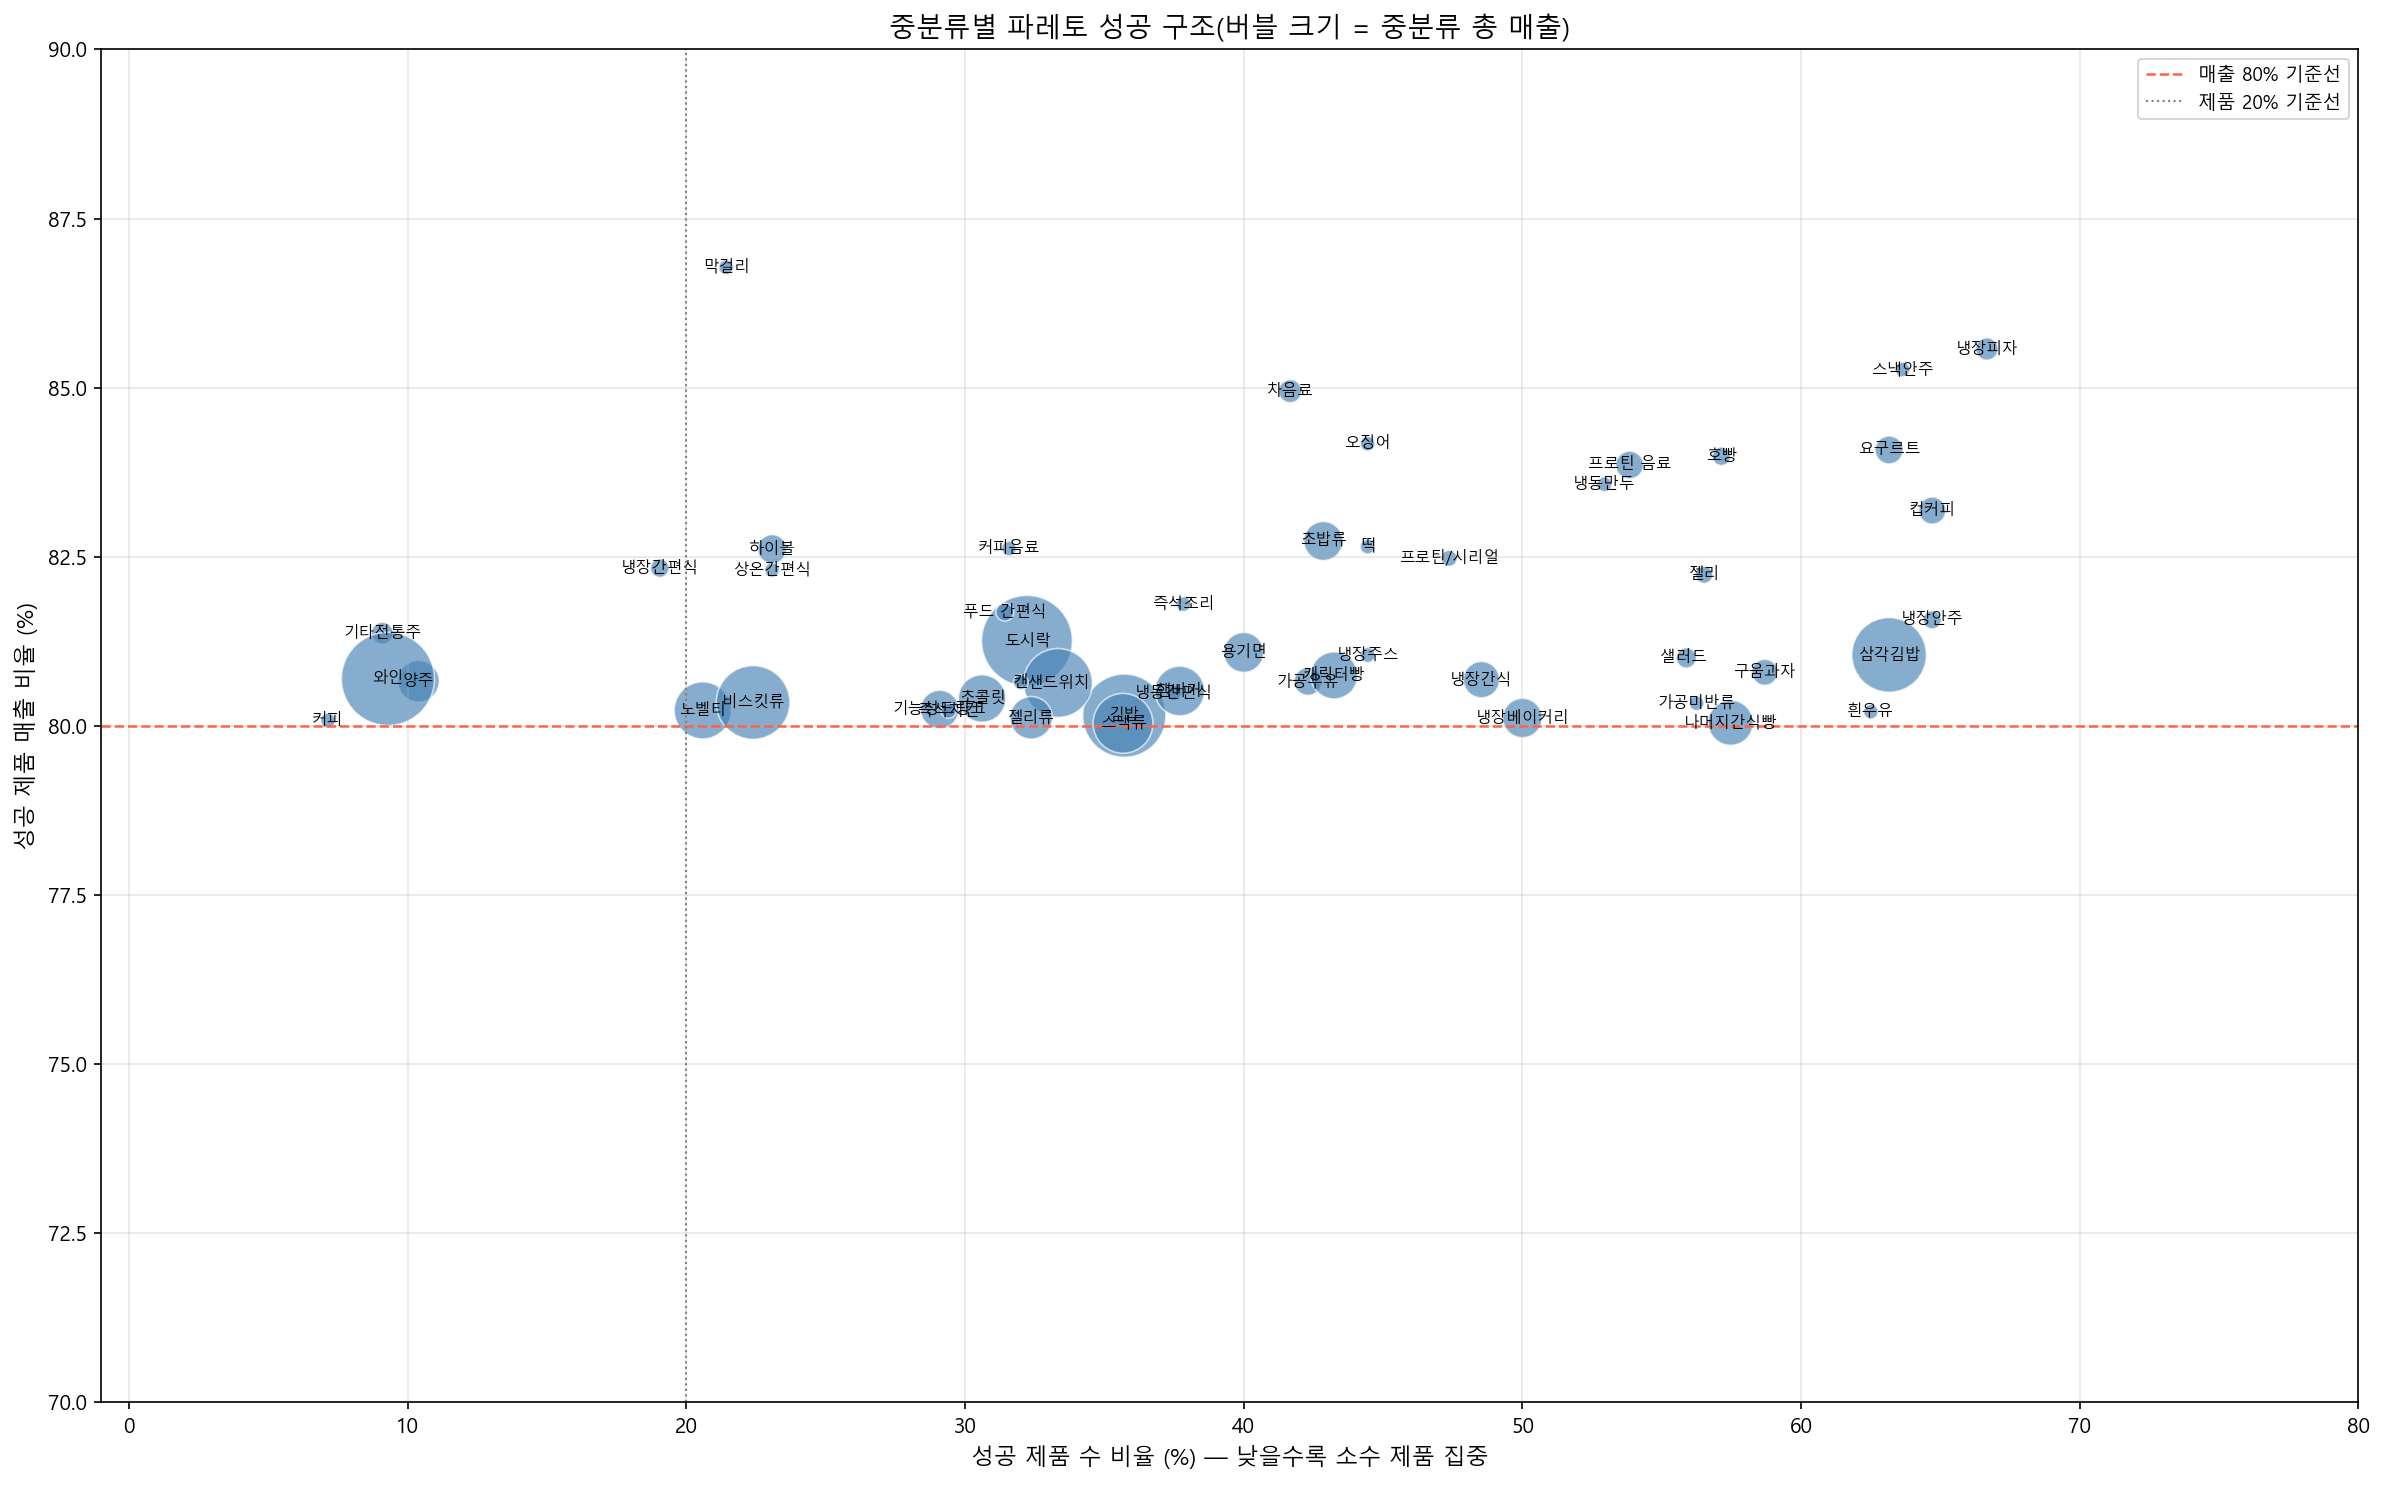

=== 성공 매출비율 이상 카테고리 (70% 미만 또는 95% 초과) ===


,중분류,전체,성공,제품비율(%),매출비율(%)


In [32]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 중분류별 집계
_sc = (
    _df_final.groupby('ITEM_MDDV_NM')['pos_success']
    .agg(
        전체='count',
        성공=lambda x: x.eq(1).sum(),
    )
    .reset_index()
)
_sc['성공제품비율'] = _sc['성공'] / _sc['전체'] * 100

# 매출 집계 (NaN 제외)
_sc_amt = (
    _df_final[_df_final['pos_success'].notna()]
    .groupby('ITEM_MDDV_NM')
    .apply(lambda g: pd.Series({
        '성공매출': g.loc[g['pos_success']==1, 'sales_30d_amt'].sum(),
        '전체매출': g['sales_30d_amt'].sum(),
    }))
    .reset_index()
)
_sc_amt['성공매출비율'] = _sc_amt['성공매출'] / _sc_amt['전체매출'] * 100

_sc = _sc.merge(_sc_amt, on='ITEM_MDDV_NM')

# 시각화
fig, ax = plt.subplots(figsize=(16, 10), dpi=150)

# 버블 크기: 전체매출 (로그 스케일)
import numpy as np
_sizes = np.clip(_sc['전체매출'] / _sc['전체매출'].max() * 2000, 50, 2000)

sc = ax.scatter(
    _sc['성공제품비율'],
    _sc['성공매출비율'],
    s=_sizes,
    alpha=0.65,
    color='steelblue',
    edgecolors='white',
    linewidth=0.8,
)

# 80% 기준선
ax.axhline(80, color='tomato', linestyle='--', linewidth=1.2, label='매출 80% 기준선')
ax.axvline(20, color='gray', linestyle=':', linewidth=1.0, label='제품 20% 기준선')

# 라벨
for _, row in _sc.iterrows():
    ax.annotate(
        row['ITEM_MDDV_NM'],
        (row['성공제품비율'], row['성공매출비율']),
        fontsize=7.5,
        ha='center', va='center',
    )

ax.set_xlabel('성공 제품 수 비율 (%) — 낮을수록 소수 제품 집중', fontsize=11)
ax.set_ylabel('성공 제품 매출 비율 (%)', fontsize=11)
ax.set_title('중분류별 파레토 성공 구조(버블 크기 = 중분류 총 매출)', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(-1, 80)
ax.set_ylim(70, 90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 이상치 확인: 매출비율이 80% 크게 벗어나는 카테고리
print('=== 성공 매출비율 이상 카테고리 (70% 미만 또는 95% 초과) ===')
_outlier = _sc[(_sc['성공매출비율'] < 70) | (_sc['성공매출비율'] > 95)]
display(_outlier[['ITEM_MDDV_NM','전체','성공','성공제품비율','성공매출비율']]
        .rename(columns={'ITEM_MDDV_NM':'중분류','성공제품비율':'제품비율(%)','성공매출비율':'매출비율(%)'})
        .round(1).reset_index(drop=True))


In [33]:
# 인스타 좋아요 데이터 구성 (NPD 여부 무관, 브릿지 매핑 가능한 전체 제품)
_insta = pd.read_parquet(str(_INSTA_PATH))
_insta_7 = _insta[_insta['편의점명'] == '세븐일레븐'].copy()

# 브릿지에서 정규화명 -> ITEM_CD 매핑 (is_npd 조건 제거 — 인스타 등장 전체 대상)
_br = pd.read_parquet(str(_BRIDGE_PATH))
_br['ITEM_CD'] = _br['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)
_b4r2 = pd.read_parquet(str(B4_PATH))[['ITEM_CD','is_npd']].copy()
_b4r2['ITEM_CD'] = _b4r2['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

_nm2id = (
    _br[_br['인스타_정규화명'].notna()]
    .set_index('인스타_정규화명')['ITEM_CD']
    .to_dict()
)
_insta_7['ITEM_CD'] = _insta_7['정규화명'].map(_nm2id)

# 브릿지 매핑된 게시물 전체 (NPD 여부 무관)
_insta_npd = _insta_7[_insta_7['ITEM_CD'].notna()].copy()
_insta_npd['좋아요 수'] = pd.to_numeric(_insta_npd['좋아요 수'], errors='coerce').fillna(0).astype(int)

# is_npd 컬럼 추가
_id2npd_flag = _b4r2.set_index('ITEM_CD')['is_npd'].to_dict()
_insta_npd['is_npd'] = _insta_npd['ITEM_CD'].map(_id2npd_flag).fillna(False)

_n_npd_posts = int(_insta_npd['is_npd'].sum())
_n_non_npd_posts = int((~_insta_npd['is_npd']).sum())
_n_products = _insta_npd['ITEM_CD'].nunique()

print(f'세븐일레븐 인스타 전체: {len(_insta_7):,}개 게시물')
print(f'브릿지 매핑 게시물:     {len(_insta_npd):,}개 게시물')
print(f'  NPD 제품 게시물:      {_n_npd_posts:,}개')
print(f'  비NPD 제품 게시물:    {_n_non_npd_posts:,}개')
print(f'매핑 제품 수 (전체):   {_n_products:,}개')
print()
print('=== 게시물당 좋아요 수 기초 통계 ===')
print(_insta_npd['좋아요 수'].describe().round(1))

# 제품별 좋아요 집계 (합산 / 최대 / 평균)
_likes = (
    _insta_npd.groupby('ITEM_CD')['좋아요 수']
    .agg(게시물수='count', 좋아요합='sum', 좋아요최대='max', 좋아요평균='mean')
    .reset_index()
)
_likes['좋아요평균'] = _likes['좋아요평균'].round(1)

# is_npd / 상품명 / 중분류 붙이기
_likes['is_npd'] = _likes['ITEM_CD'].map(_id2npd_flag).fillna(False)

_id2nm2 = _pos_lbl.set_index('ITEM_CD')['ITEM_NM'].to_dict()
_id2mid = _pos_lbl.set_index('ITEM_CD')['ITEM_MDDV_NM'].to_dict()
_br_nm = _br.dropna(subset=['ITEM_CD']).set_index('ITEM_CD')['상품명'].to_dict()
_br_mid = _br.dropna(subset=['ITEM_CD']).set_index('ITEM_CD')['중분류'].to_dict()
_likes['상품명'] = _likes['ITEM_CD'].map(_id2nm2).fillna(_likes['ITEM_CD'].map(_br_nm))
_likes['중분류'] = _likes['ITEM_CD'].map(_id2mid).fillna(_likes['ITEM_CD'].map(_br_mid))

print('=== 제품별 좋아요 집계 기초통계 ===')
print(_likes[['좋아요합','좋아요최대','좋아요평균']].describe().round(1))
print()

# 퍼센타일 비교표
pcts = [10, 25, 50, 75, 80, 90, 95]
_pct_tbl = pd.DataFrame({
    '퍼센타일': pcts,
    '좋아요합': [int(_likes['좋아요합'].quantile(p/100)) for p in pcts],
    '좋아요최대': [int(_likes['좋아요최대'].quantile(p/100)) for p in pcts],
    '좋아요평균': [round(_likes['좋아요평균'].quantile(p/100), 1) for p in pcts],
})
print('=== 퍼센타일별 임계값 ===')
display(_pct_tbl)
print()

print('=== 좋아요합 기준 상위 20개 제품 ===')
display(
    _likes.sort_values('좋아요합', ascending=False)
    [['상품명','중분류','is_npd','게시물수','좋아요합','좋아요최대','좋아요평균']]
    .head(20).reset_index(drop=True)
)

세븐일레븐 인스타 전체: 1,301개 게시물
브릿지 매핑 게시물:     1,226개 게시물
  NPD 제품 게시물:      993개
  비NPD 제품 게시물:    -2,219개
매핑 제품 수 (전체):   658개

=== 게시물당 좋아요 수 기초 통계 ===
count     1226.0
mean      1132.0
std       1469.3
min         -1.0
25%        278.0
50%        790.0
75%       1444.0
max      20750.0
Name: 좋아요 수, dtype: float64
=== 제품별 좋아요 집계 기초통계 ===
          좋아요합    좋아요최대    좋아요평균
count    658.0    658.0    658.0
mean    2109.2   1316.4   1002.5
std     3572.7   1722.3   1266.0
min       -1.0     -1.0     -1.0
25%      347.8    290.0    288.5
50%      995.0    866.0    746.0
75%     1928.8   1591.5   1115.5
max    30226.0  20750.0  13875.0

=== 퍼센타일별 임계값 ===


,퍼센타일,좋아요합,좋아요최대,좋아요평균
0,10,195,182,181.4
1,25,347,290,288.5
2,50,995,866,746.0
3,75,1928,1591,1115.5
4,80,2419,1818,1377.0
5,90,4781,2536,1940.7
6,95,7885,4697,2608.0



=== 좋아요합 기준 상위 20개 제품 ===


,상품명,중분류,is_npd,게시물수,좋아요합,좋아요최대,좋아요평균
0,PB)자이언츠돌아온팅클초코맛60g,스낵류,True,3,30226,10956,10075.3
1,PB)자이언츠피카츄냐냐71g,스낵류,True,2,27750,20750,13875.0
2,PB)K리그슛!팅클별매콤달콤60g,스낵류,True,12,23211,3271,1934.2
3,K리그)슛!더비라면,용기면,True,12,22600,3271,1883.3
4,PB)K리그슛!허니카라멜팝콘75g,스낵류,True,12,22600,3271,1883.3
5,KBO)롯데자이언츠바다샌드크림빵96g,간식빵,True,2,21277,15477,10638.5
6,K리그)슛!비타민워터믹스후르츠340ml,기능성드링크,True,11,20746,3271,1886.0
7,PB)자이언츠새로온팅클메론맛60g,스낵류,True,2,17654,9024,8827.0
8,PB)K리그슛!소보로빵75g,간식빵,True,7,16616,3271,2373.7
9,딸기키티)초코에빠진딸기60g,초콜릿,True,7,15873,4697,2267.6


=== 임계값별 성공 제품 수 (좋아요합 기준) ===


,임계값(이상),성공,실패,성공비율
0,500,457,201,69.5%
1,1000,328,330,49.8%
2,1500,230,428,35.0%
3,2000,159,499,24.2%
4,2500,129,529,19.6%
5,3000,110,548,16.7%
6,5000,64,594,9.7%


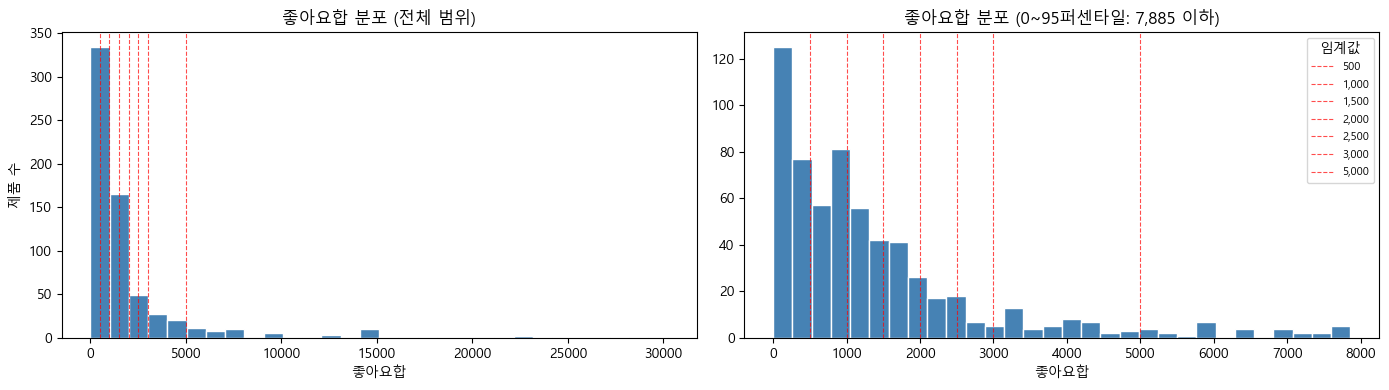

In [34]:
# 임계값별 성공 제품 수 시뮬레이션 (좋아요합 기준)
# -> 아래 THRESHOLD를 바꾸며 EDA
THRESHOLDS = [500, 1000, 1500 ,2000, 2500, 3000, 5000]

print('=== 임계값별 성공 제품 수 (좋아요합 기준) ===')
n_insta = len(_likes)
rows = []
for t in THRESHOLDS:
    n_success = (_likes['좋아요합'] >= t).sum()
    rows.append({'임계값(이상)': t, '성공': n_success, '실패': n_insta - n_success,
                 '성공비율': f'{n_success/n_insta*100:.1f}%'})
display(pd.DataFrame(rows))
print()

# 분포 시각화
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 분포
axes[0].hist(_likes['좋아요합'], bins=30, color='steelblue', edgecolor='white')
for t in THRESHOLDS:
    axes[0].axvline(t, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title('좋아요합 분포 (전체 범위)')
axes[0].set_xlabel('좋아요합')
axes[0].set_ylabel('제품 수')

# 상위 구간 확대
_q95 = int(_likes['좋아요합'].quantile(0.95))
axes[1].hist(_likes[_likes['좋아요합'] <= _q95]['좋아요합'], bins=30, color='steelblue', edgecolor='white')
for t in THRESHOLDS:
    axes[1].axvline(t, color='red', linestyle='--', linewidth=0.8, alpha=0.7,
                    label=f'{t:,}')
axes[1].legend(title='임계값', fontsize=8)
axes[1].set_title(f'좋아요합 분포 (0~95퍼센타일: {_q95:,} 이하)')
axes[1].set_xlabel('좋아요합')

plt.tight_layout()
plt.show()


In [35]:
INSTA_THRESHOLD = 3000

_likes['insta_success'] = (_likes['좋아요합'] >= INSTA_THRESHOLD).astype(int)

n_insta_success = _likes['insta_success'].sum()
print(f'=== 인스타 성공 기준: 좋아요합 >= {INSTA_THRESHOLD:,} ===')
print(f'인스타 등장 NPD: {len(_likes):,}개')
print(f'  성공(1): {n_insta_success:,}개  ({n_insta_success/len(_likes)*100:.1f}%)')
print(f'  실패(0): {len(_likes)-n_insta_success:,}개  ({(len(_likes)-n_insta_success)/len(_likes)*100:.1f}%)')
print()

# POS 성공 여부 + 소분류 붙이기
_pos_lbl_slim = _df_final[['ITEM_CD','ITEM_MDDV_NM','ITEM_SMDV_NM','pos_success']].copy()
_pos_lbl_slim['ITEM_CD'] = _pos_lbl_slim['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

_combined = _likes.merge(_pos_lbl_slim, on='ITEM_CD', how='left')
_success = _combined[_combined['insta_success'] == 1].sort_values('좋아요합', ascending=False)

print(f'=== 인스타 성공 제품 목록 ({len(_success)}개) ===')
display(
    _success[['상품명','중분류','게시물수','좋아요합','좋아요최대','좋아요평균','pos_success']]
    .rename(columns={'pos_success':'POS성공'})
    .reset_index(drop=True)
)
print()

# POS + 인스타 모두 성공한 제품
_both = _success[_success['pos_success'] == 1]
print(f'POS and 인스타 모두 성공: {len(_both)}건')
print()

# 인스타에서만 성공 (pos_success != 1: POS 실패 또는 30일 매출 없음)
_insta_only = _success[_success['pos_success'] != 1].sort_values('좋아요합', ascending=False)
print(f'=== 인스타에서만 성공 ({len(_insta_only)}개) ===')
display(
    _insta_only[['상품명','중분류','ITEM_SMDV_NM','좋아요합']]
    .rename(columns={'ITEM_SMDV_NM':'소분류'})
    .reset_index(drop=True)
)
print()

# 제품명 10개씩 출력 (잘림 없음)
_names = _insta_only['상품명'].reset_index(drop=True)
_chunk = 10
for i in range(0, len(_names), _chunk):
    print(f'--- {i+1}~{min(i+_chunk, len(_names))}번 ---')
    for j, nm in _names.iloc[i:i+_chunk].items():
        print(f'  {j+1:>3}. {nm}')
print()

print('=== 인스타 전용 성공 — 중분류별 제품 수 ===')
display(
    _insta_only.groupby('중분류')
    .size()
    .reset_index(name='제품수')
    .sort_values('제품수', ascending=False)
    .reset_index(drop=True)
)
print()

print('=== 인스타 전용 성공 — 소분류별 제품 수 ===')
display(
    _insta_only.groupby(['중분류','ITEM_SMDV_NM'])
    .size()
    .reset_index(name='제품수')
    .rename(columns={'ITEM_SMDV_NM':'소분류'})
    .sort_values('제품수', ascending=False)
    .reset_index(drop=True)
)

=== 인스타 성공 기준: 좋아요합 >= 3,000 ===
인스타 등장 NPD: 658개
  성공(1): 110개  (16.7%)
  실패(0): 548개  (83.3%)

=== 인스타 성공 제품 목록 (110개) ===


,상품명,중분류,게시물수,좋아요합,좋아요최대,좋아요평균,POS성공
0,PB)자이언츠돌아온팅클초코맛60g,스낵류,3,30226,10956,10075.3,1.0
1,PB)자이언츠피카츄냐냐71g,스낵류,2,27750,20750,13875.0,1.0
2,PB)K리그슛!팅클별매콤달콤60g,스낵류,12,23211,3271,1934.2,0.0
3,PB)K리그슛!허니카라멜팝콘75g,스낵류,12,22600,3271,1883.3,0.0
4,K리그)슛!더비라면,용기면,12,22600,3271,1883.3,0.0
...,...,...,...,...,...,...,...
105,PB)K리그슛!페스츄리오징어40g,오징어,1,3163,3163,3163.0,0.0
106,한도초과)폭풍햄가득참치김밥,김밥,4,3142,1709,785.5,1.0
107,고래사)땡초핫접사각,즉석간식,2,3112,1899,1556.0,NaN
108,고래사)떡품은어묵,즉석간식,2,3112,1899,1556.0,NaN



POS and 인스타 모두 성공: 53건

=== 인스타에서만 성공 (57개) ===


,상품명,중분류,소분류,좋아요합
0,PB)K리그슛!팅클별매콤달콤60g,스낵류,옥수수스낵,23211
1,PB)K리그슛!허니카라멜팝콘75g,스낵류,옥수수스낵,22600
2,K리그)슛!더비라면,용기면,라면(대형컵),22600
3,PB)K리그슛!소보로빵75g,간식빵,캐릭터빵,16616
4,딸기키티)딸기케이크팝30g,냉장베이커리,냉장빵,15030
5,딸기키티)베리롤케익85g,간식빵,캐릭터빵,14513
6,APP전용)최강록의로스팜에그샌드,샌드위치,기타,14245
7,APP예약)기사식당 바싹불고기,도시락,기타,12856
8,PB)K리그슛!크림빵105g,간식빵,캐릭터빵,11950
9,APP예약)딸기샌드위치,샌드위치,기타,9659



--- 1~10번 ---
    1. PB)K리그슛!팅클별매콤달콤60g
    2. PB)K리그슛!허니카라멜팝콘75g
    3. K리그)슛!더비라면
    4. PB)K리그슛!소보로빵75g
    5. 딸기키티)딸기케이크팝30g
    6. 딸기키티)베리롤케익85g
    7. APP전용)최강록의로스팜에그샌드
    8. APP예약)기사식당 바싹불고기
    9. PB)K리그슛!크림빵105g
   10. APP예약)딸기샌드위치
--- 11~20번 ---
   11. 이정후)포크바베큐플래터도시락
   12. 이정후)함박스테이크김밥
   13. 7P)랑그드샤초코8입
   14. 나무)토마토캔디30.4g
   15. APP)망고볼113g
   16. APP)아사이볼113g
   17. APP예약)디지게매운등심돈까스
   18. 그린)디지게매운통치킨버거(양념맛)
   19. APP예약)디지게매운돈까스김밥(눈물맛)
   20. 롯데)맛장우도시락 고기(肉)올인원
--- 21~30번 ---
   21. APP예약)맛장우맛자랑 직화닭갈비
   22. 이정후)고기폭탄홈런비빔밥
   23. PB)오징어얼라이브매콤볶음면
   24. 그린)초코딸기샌드
   25. 머거본)부창제과호두정과30g
   26. 그린)디지게매운치킨유부말이(양념맛)
   27. 그린)디지게매운돈까스삼각(양념맛)
   28. 롯데)미미미누크런키8입
   29. PB)바스켓팝콘
   30. 행사)맛장우전주식비빔밥
--- 31~40번 ---
   31. 롯데)티처스햄치즈에그팡팡토스트
   32. PB)이정후솔티카라멜샌드빵160g
   33. 디저트39)저당팥모나카140ml
   34. 디저트39)저당슈크림모나카140ml
   35. PB)티처스초코우유300ml
   36. 그린)팥떡궁합샌드
   37. 롯데)크리미불닭김밥
   38. 롯데)베이컨크리미불닭삼각
   39. 엔제이)후루츄(망고맛)90g
   40. 엔제이)후루츄(딸기맛)90g
--- 41~50번 ---
   41. 롯데)사천식마파두부덮밥
   4

,중분류,제품수
0,도시락,10
1,샌드위치,7
2,김밥,5
3,간식빵,4
4,컵커피,3
5,스낵류,3
6,초콜릿,2
7,즉석간식,2
8,초밥류,2
9,냉동디저트,2



=== 인스타 전용 성공 — 소분류별 제품 수 ===


,중분류,소분류,제품수
0,도시락,기타,6
1,간식빵,캐릭터빵,4
2,샌드위치,샌드위치,4
3,김밥,말이김밥,3
4,컵커피,300ml 미만,3
5,도시락,도시락,3
6,스낵류,옥수수스낵,3
7,샌드위치,기타,2
8,젤리,마시는젤리,2
9,초콜릿,행사상품,2


In [36]:
QUERY = '마키키쇼비뇽블랑750ml'  # ← 여기 바꾸기

_mask = _combined['상품명'].str.contains(QUERY, na=False)
_found = (
    _combined[_mask]
    [['상품명','중분류','ITEM_SMDV_NM','게시물수','좋아요합','좋아요최대','좋아요평균','insta_success','pos_success']]
    .rename(columns={'ITEM_SMDV_NM':'소분류','insta_success':'인스타성공','pos_success':'POS성공'})
    .sort_values('좋아요합', ascending=False)
    .reset_index(drop=True)
)

print(f'검색어: "{QUERY}"  →  {len(_found)}개 제품')
if len(_found) > 0:
    display(_found)
else:
    print('해당 문자열을 포함한 제품 없음')


검색어: "마키키쇼비뇽블랑750ml"  →  1개 제품


,상품명,중분류,소분류,게시물수,좋아요합,좋아요최대,좋아요평균,인스타성공,POS성공
0,하정우)마키키쇼비뇽블랑750ml,와인,화이트,2,316,170,158.0,0,1.0


In [37]:
_pos_success_set  = set(_df_final.loc[_df_final['pos_success'] == 1, 'ITEM_CD'])
_insta_success_set = set(_success['ITEM_CD'])  # 현재 INSTA_THRESHOLD 기준

_pos_all_set   = set(_df_final['ITEM_CD'])
_insta_all_set = set(_combined['ITEM_CD'])
_union_all     = _pos_all_set | _insta_all_set
_union_success = _pos_success_set | _insta_success_set

n_union_all = len(_union_all)
n_pos_s     = len(_pos_success_set)
n_insta_s   = len(_insta_success_set)
n_both_s    = len(_pos_success_set & _insta_success_set)
n_union_s   = len(_union_success)

print(f'=== 임계값 {INSTA_THRESHOLD:,} 기준 성공 현황 ===')
print(f'합집합 전체 상품:          {n_union_all:,}개  (POS {len(_pos_all_set):,} ∪ 인스타 {len(_insta_all_set):,})')
print(f'POS 성공:                  {n_pos_s:,}개')
print(f'인스타 성공:               {n_insta_s:,}개  (좋아요합 >= {INSTA_THRESHOLD:,})')
print(f'POS AND 인스타 모두 성공:  {n_both_s:,}개')
print(f'POS OR 인스타 성공 합집합: {n_union_s:,}개  ({n_union_s/n_union_all*100:.1f}%)')

=== 임계값 3,000 기준 성공 현황 ===
합집합 전체 상품:          3,002개  (POS 2,858 ∪ 인스타 658)
POS 성공:                  901개
인스타 성공:               110개  (좋아요합 >= 3,000)
POS AND 인스타 모두 성공:  53개
POS OR 인스타 성공 합집합: 958개  (31.9%)


In [38]:
_insta_success_set = set(_success['ITEM_CD'])  # 현재 INSTA_THRESHOLD 기준

_pos_all_set   = set(_df_final['ITEM_CD'])
_insta_all_set = set(_combined['ITEM_CD'])
_union_all     = _pos_all_set | _insta_all_set
_union_success = _pos_success_set | _insta_success_set

n_union_all = len(_union_all)
n_pos_all   = len(_pos_all_set)
n_pos_s     = len(_pos_success_set)
n_insta_s   = len(_insta_success_set)
n_both_s    = len(_pos_success_set & _insta_success_set)
n_union_s   = len(_union_success)

print(f'=== 임계값 {INSTA_THRESHOLD:,} 기준 성공 현황 ===')
print(f'POS 전체:                  {n_pos_all:,}개')
print(f'POS 성공:                  {n_pos_s:,}개  ({n_pos_s/n_pos_all*100:.1f}%)')
print()
print(f'합집합 전체 상품:          {n_union_all:,}개  (POS {n_pos_all:,} ∪ 인스타 {len(_insta_all_set):,})')
print(f'인스타 성공:               {n_insta_s:,}개  (좋아요합 >= {INSTA_THRESHOLD:,})')
print(f'POS AND 인스타 모두 성공:  {n_both_s:,}개')
print(f'POS OR 인스타 성공 합집합: {n_union_s:,}개  ({n_union_s/n_union_all*100:.1f}%)')

=== 임계값 3,000 기준 성공 현황 ===
POS 전체:                  2,858개
POS 성공:                  901개  (31.5%)

합집합 전체 상품:          3,002개  (POS 2,858 ∪ 인스타 658)
인스타 성공:               110개  (좋아요합 >= 3,000)
POS AND 인스타 모두 성공:  53개
POS OR 인스타 성공 합집합: 958개  (31.9%)


In [39]:
# pos_b4_insta_pool.csv 로드
_pool = pd.read_csv(str(BASE / 'pos_b4_insta_pool.csv'), dtype={'ITEM_CD': str})
_pool['ITEM_CD'] = _pool['ITEM_CD'].apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

# 분석 대상 ITEM_CD: POS NPD + 인스타 매핑 제품
_target_ids = set(_df_final['ITEM_CD']) | set(_combined['ITEM_CD'])

# 풀에서 대상 제품만 필터 (POS_B4 기준, 인스타_미매칭은 ITEM_CD 없음)
_base = _pool[_pool['ITEM_CD'].isin(_target_ids)][['ITEM_CD','상품명','중분류','소분류']].drop_duplicates('ITEM_CD').copy()

# pos_success 붙이기
_id2pos_s = _df_final.set_index('ITEM_CD')['pos_success'].to_dict()
_base['pos_success'] = _base['ITEM_CD'].map(_id2pos_s)

# insta_success 붙이기
_id2insta_s = _combined.drop_duplicates('ITEM_CD').set_index('ITEM_CD')['insta_success'].to_dict()
_base['insta_success'] = _base['ITEM_CD'].map(_id2insta_s).fillna(0).astype(int)

# 성공여부
_base['성공여부'] = (
    (_base['pos_success'] == 1) | (_base['insta_success'] == 1)
).map({True: '성공', False: '실패'})

result = _base[['ITEM_CD','상품명','중분류','소분류','성공여부']].reset_index(drop=True)

print(f'전체: {len(result):,}개  성공: {(result["성공여부"]=="성공").sum():,}개  실패: {(result["성공여부"]=="실패").sum():,}개')
print(f'소분류 NaN: {result["소분류"].isna().sum()}개')
display(result)

df_success = _base[['ITEM_CD','상품명','중분류','소분류','성공여부']].reset_index(drop=True)

OUT_PATH = BASE / 'npd_success_labels.csv'
df_success.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')
print(f'saved: {OUT_PATH}')
print(f'전체: {len(df_success):,}개  성공: {(df_success["성공여부"]=="성공").sum():,}개  실패: {(df_success["성공여부"]=="실패").sum():,}개')

전체: 2,996개  성공: 957개  실패: 2,039개
소분류 NaN: 0개


,ITEM_CD,상품명,중분류,소분류,성공여부
0,53047,존슨빌)폴리쉬소시지108g,즉석조리,빅바이트,실패
1,53197,요기요)만쿠만구치킨,즉석치킨,세트류,실패
2,14173,예약)한끼연구소 간장불고기정식,도시락,기타,실패
3,14248,APP예약)더꽉찬불고기&참치김밥,김밥,말이김밥,실패
4,13268,롯데)참치마요네즈삼각김밥,삼각김밥,삼각김밥,실패
...,...,...,...,...,...
2991,126416,PB)800딸기바나나쭈쭈바,노벨티,펜슬,실패
2992,126487,빙그레)라이언바제로자두맛70ml,노벨티,바,실패
2993,126508,삼립)끼리크림치즈벨기에와플68g,구움과자,구움과자,성공
2994,126530,롯데)의성마늘비엔나320g,냉장간식,햄/비엔나,실패


saved: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\npd_success_labels.csv
전체: 2,996개  성공: 957개  실패: 2,039개


In [40]:
# ── 소스 / POS_등장 / 인스타_등장 컬럼 추가 ──────────────────────────────────
# cell 55(insta-success-1500)에서 저장한 df_success에 출처 플래그를 붙여 덮어씀

_pos_ids   = set(_df_final['ITEM_CD'])
_insta_ids = set(_combined['ITEM_CD'])

def _get_src(icd):
    p = icd in _pos_ids
    i = icd in _insta_ids
    if p and i: return 'POS+인스타'
    if p:       return 'POS'
    return '인스타'

df_success['소스']       = df_success['ITEM_CD'].apply(_get_src)
df_success['POS_등장']   = df_success['ITEM_CD'].isin(_pos_ids)
df_success['인스타_등장'] = df_success['ITEM_CD'].isin(_insta_ids)

df_success = df_success[[
    'ITEM_CD', '상품명', '중분류', '소분류',
    '소스', 'POS_등장', '인스타_등장', '성공여부'
]]

df_success.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')

print(df_success['소스'].value_counts().to_string())
print(f'POS_등장   True:{df_success["POS_등장"].sum():,} / False:{(~df_success["POS_등장"]).sum():,}')
print(f'인스타_등장 True:{df_success["인스타_등장"].sum():,} / False:{(~df_success["인스타_등장"]).sum():,}')
print(f'저장: {OUT_PATH}')


소스
POS        2344
POS+인스타     514
인스타         138
POS_등장   True:2,858 / False:138
인스타_등장 True:652 / False:2,344
저장: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\npd_success_labels.csv


---
## CU/GS25 인스타 좋아요 수 EDA

**목적**: CU·GS25 편의점별 제품 좋아요 분포 파악 및 임계값별 성공 제품 비율 비교  
**집계 기준**: 정규화명 기준 좋아요합 / 최대 / 평균  
**전제**: `38c84f2d` (`_insta` 변수) 실행 완료


=== CU 제품별 좋아요 기초통계 (1162개 정규화명) ===
          좋아요합    좋아요최대    좋아요평균
count   1162.0   1162.0   1162.0
mean    1883.0   1523.9   1324.7
std     5220.6   3026.1   1933.0
min       55.0     55.0     55.0
25%      508.0    508.0    489.4
50%      834.0    803.0    767.0
75%     1853.0   1611.0   1469.0
max    82883.0  44507.0  26001.3

=== GS25 제품별 좋아요 기초통계 (985개 정규화명) ===
          좋아요합    좋아요최대    좋아요평균
count    985.0    985.0    985.0
mean    1589.9   1200.7   1023.9
std     4287.9   2962.3   2401.5
min       -1.0     -1.0     -1.0
25%      390.0    359.0    345.0
50%      632.0    578.0    535.0
75%     1051.0    834.0    750.0
max    56550.0  36258.0  28275.0

=== 임계값별 성공 제품 수 / 비율 (CU vs GS25) ===


성공 제품 수       성공 비율       
편의점       CU GS25     CU   GS25
임계값                            
500      884  632  76.1%  64.2%
1000     469  258  40.4%  26.2%
1500     352  168  30.3%  17.1%
2000     279  127  24.0%  12.9%
2500     220   99  18.9%  10.1%
3000     177   80  15.2%   8.1%
5000      61   50   5.2%   5.1%

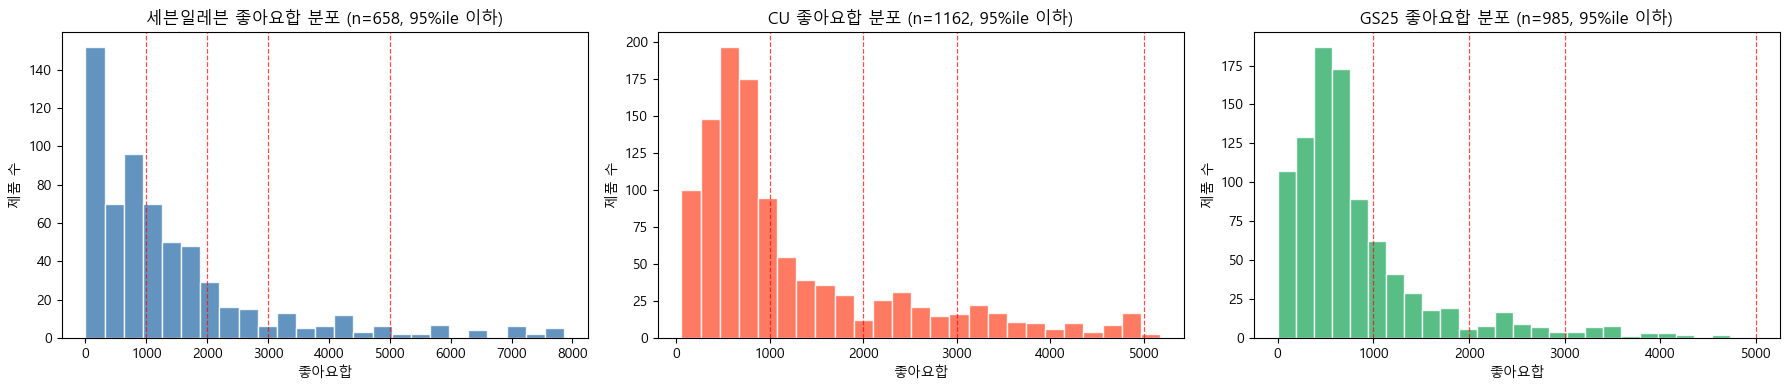


=== CU 좋아요합 상위 10개 제품 ===


,정규화명,게시물수,좋아요합,좋아요최대,좋아요평균
0,TXT별모아초코별,4,82883,44507,20720.8
1,TXT별모아줄줄이미니별,4,81273,44507,20318.2
2,TXT별모아쿠키별,3,78004,44507,26001.3
3,TXT별모아젤리별,3,78004,44507,26001.3
4,먹산생크림빵,5,42136,15556,8427.2
5,가나디바나나우유,7,35851,8625,5121.6
6,보일라면,2,15821,11298,7910.5
7,연세우유허슬두생크림빵,1,14672,14672,14672.0
8,가나디초코별,2,14436,13413,7218.0
9,가나디바나링,2,14436,13413,7218.0



=== GS25 좋아요합 상위 10개 제품 ===


,정규화명,게시물수,좋아요합,좋아요최대,좋아요평균
0,라더소세지피자빵,2,56550,36258,28275.0
1,데이지에일,14,48252,11472,3446.6
2,서울우유우유크림빵,15,40829,34896,2721.9
3,픽셀리라파게티,3,39209,21154,13069.7
4,픽셀리치즈별콘,2,33484,17172,16742.0
5,픽셀리꿀단지스낵,2,33484,17172,16742.0
6,달너새랜덤초콜릿,6,27967,8333,4661.2
7,플레이브꼬깔콘세트,3,26838,12000,8946.0
8,플레이브군고구마츄세트,3,26838,12000,8946.0
9,픽셀리)각별별하늘초코케익,1,20292,20292,20292.0


In [41]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# CU/GS25 게시물 필터 + 좋아요 수 숫자 변환
_insta_cg = _insta[_insta['편의점명'].isin(['CU', 'GS25'])].copy()
_insta_cg['좋아요 수'] = pd.to_numeric(_insta_cg['좋아요 수'], errors='coerce').fillna(0).astype(int)

# 편의점 x 정규화명 기준 집계
_cg_likes = (
    _insta_cg
    .groupby(['편의점명', '정규화명'])['좋아요 수']
    .agg(게시물수='count', 좋아요합='sum', 좋아요최대='max', 좋아요평균='mean')
    .round({'좋아요평균': 1})
    .reset_index()
)

# 편의점별 기초 통계
for store in ['CU', 'GS25']:
    _s = _cg_likes[_cg_likes['편의점명'] == store]
    print(f'=== {store} 제품별 좋아요 기초통계 ({len(_s)}개 정규화명) ===')
    print(_s[['좋아요합','좋아요최대','좋아요평균']].describe().round(1))
    print()

# 임계값별 성공 제품 수 / 비율 시뮬레이션
THRESHOLDS = [500, 1000, 1500, 2000, 2500, 3000, 5000]
_sim_rows = []
for t in THRESHOLDS:
    for store in ['CU', 'GS25']:
        _s = _cg_likes[_cg_likes['편의점명'] == store]
        n_suc = int((_s['좋아요합'] >= t).sum())
        _sim_rows.append({
            '임계값': t, '편의점': store,
            '성공 제품 수': n_suc, '전체': len(_s),
            '성공 비율': f'{n_suc/len(_s)*100:.1f}%',
        })

print('=== 임계값별 성공 제품 수 / 비율 (CU vs GS25) ===')
display(
    pd.DataFrame(_sim_rows)
    .pivot(index='임계값', columns='편의점', values=['성공 제품 수', '성공 비율'])
)
print()

# 3사 분포 비교 히스토그램
_seven_likes_vals = _likes['좋아요합']
_cu_likes_vals    = _cg_likes[_cg_likes['편의점명'] == 'CU']['좋아요합']
_gs_likes_vals    = _cg_likes[_cg_likes['편의점명'] == 'GS25']['좋아요합']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
_pairs = [
    ('세븐일레븐', _seven_likes_vals, 'steelblue'),
    ('CU',         _cu_likes_vals,    'tomato'),
    ('GS25',       _gs_likes_vals,    'mediumseagreen'),
]
for ax, (label, data, color) in zip(axes, _pairs):
    q95 = max(int(data.quantile(0.95)), 1)
    ax.hist(data[data <= q95], bins=25, color=color, edgecolor='white', alpha=0.85)
    for t in [1000, 2000, 3000, 5000]:
        ax.axvline(t, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.set_title(f'{label} 좋아요합 분포 (n={len(data)}, 95%ile 이하)')
    ax.set_xlabel('좋아요합')
    ax.set_ylabel('제품 수')
plt.tight_layout()
plt.show()
print()

# 편의점별 좋아요합 상위 10개
for store in ['CU', 'GS25']:
    _s = _cg_likes[_cg_likes['편의점명'] == store].sort_values('좋아요합', ascending=False).head(10)
    print(f'=== {store} 좋아요합 상위 10개 제품 ===')
    display(_s[['정규화명','게시물수','좋아요합','좋아요최대','좋아요평균']].reset_index(drop=True))
    print()


---
## CU/GS25 성공 라벨 생성 & npd_success_labels 확장

**임계값**: `INSTA_THRESHOLD` 재사용 (세븐일레븐과 동일)  
**PK**: `{편의점명}_{정규화명}` 합성 ID  
**출력**: `npd_success_labels.csv` 덮어쓰기 (`편의점명` 컬럼 추가)


In [42]:
# 전제: insta-success-1500 + 2703f58a + cu-gs-insta-likes-eda 셀 실행 완료

print(f'적용 임계값: 좋아요합 >= {INSTA_THRESHOLD:,}')
print()

_cu_gs_label_rows = []
for store in ['CU', 'GS25']:
    _s = _cg_likes[_cg_likes['편의점명'] == store].copy()
    _s['성공여부'] = (_s['좋아요합'] >= INSTA_THRESHOLD).map({True: '성공', False: '실패'})
    _s['ITEM_CD']    = store + '_' + _s['정규화명']  # 합성 PK: {편의점명}_{정규화명}
    _s['상품명']     = _s['정규화명']
    _s['소스']       = f'{store}_인스타'
    _s['편의점명_k'] = store
    _cu_gs_label_rows.append(_s[['ITEM_CD', '상품명', '소스', '성공여부', '편의점명_k']])

_cu_gs_df = pd.concat(_cu_gs_label_rows).reset_index(drop=True)
_cu_gs_df = _cu_gs_df.rename(columns={'편의점명_k': '편의점명'})

# 기존 세븐 df_success 에 편의점명 추가
_seven_df = df_success.copy()
_seven_df['편의점명'] = '세븐일레븐'

# 합치기 (CU·GS25는 중분류·소분류 NA)
df_success_all = pd.concat([
    _seven_df[['ITEM_CD', '상품명', '중분류', '소분류', '소스', '성공여부', '편의점명']],
    _cu_gs_df.assign(중분류=pd.NA, 소분류=pd.NA)
             [['ITEM_CD', '상품명', '중분류', '소분류', '소스', '성공여부', '편의점명']],
], ignore_index=True)

# ── 구간별 성공 비율 요약 ──────────────────────────────────────────────────────
_scope_list = [
    ('세븐일레븐 (기존)',  _seven_df),
    ('CU (추가)',          _cu_gs_df[_cu_gs_df['소스'] == 'CU_인스타']),
    ('GS25 (추가)',        _cu_gs_df[_cu_gs_df['소스'] == 'GS25_인스타']),
    ('전체 합계',          df_success_all),
]
_summary_rows = []
for scope, subset in _scope_list:
    n_tot  = len(subset)
    n_suc  = int((subset['성공여부'] == '성공').sum())
    n_fail = int((subset['성공여부'] == '실패').sum())
    _summary_rows.append({
        '구분':         scope,
        '전체 제품 수': n_tot,
        '성공':         n_suc,
        '실패':         n_fail,
        '성공 비율':    f'{n_suc / n_tot * 100:.1f}%' if n_tot else '-',
    })

print(f'=== 구간별 성공 비율 요약 (임계값 {INSTA_THRESHOLD:,}) ===')
display(pd.DataFrame(_summary_rows))
print()

# 소스 x 성공여부 상세
print('=== 소스별 성공/실패 상세 ===')
display(
    df_success_all
    .groupby(['편의점명', '소스', '성공여부'])
    .size()
    .reset_index(name='제품 수')
    .sort_values(['편의점명', '소스', '성공여부'])
    .reset_index(drop=True)
)
print()

# 저장
df_success_all.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')
print(f'저장: {OUT_PATH}')
print(f'총 {len(df_success_all):,}개  '
      f'성공: {(df_success_all["성공여부"]=="성공").sum():,}개  '
      f'실패: {(df_success_all["성공여부"]=="실패").sum():,}개')


적용 임계값: 좋아요합 >= 3,000

=== 구간별 성공 비율 요약 (임계값 3,000) ===


,구분,전체 제품 수,성공,실패,성공 비율
0,세븐일레븐 (기존),2996,957,2039,31.9%
1,CU (추가),1162,177,985,15.2%
2,GS25 (추가),985,80,905,8.1%
3,전체 합계,5143,1214,3929,23.6%



=== 소스별 성공/실패 상세 ===


,편의점명,소스,성공여부,제품 수
0,CU,CU_인스타,성공,177
1,CU,CU_인스타,실패,985
2,GS25,GS25_인스타,성공,80
3,GS25,GS25_인스타,실패,905
4,세븐일레븐,POS,성공,624
5,세븐일레븐,POS,실패,1720
6,세븐일레븐,POS+인스타,성공,319
7,세븐일레븐,POS+인스타,실패,195
8,세븐일레븐,인스타,성공,14
9,세븐일레븐,인스타,실패,124



저장: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\npd_success_labels.csv
총 5,143개  성공: 1,214개  실패: 3,929개


---
## blog_keywords_with_pos 연결 누락 패치 (`patch_blog_with_pos.py`)

`blog_keywords_processed`에 키워드가 있는데 `blog_keywords_with_pos`에 ITEM_CD 연결이
누락된 제품을 찾아 append. `apply_keyword_normalization` 실행 전에 반드시 선행.

In [43]:
# patch-blog-with-pos
# blog_keywords_processed 키워드 있는데 blog_keywords_with_pos 연결 누락 제품 append
import subprocess, sys, os

result = subprocess.run(
    [sys.executable, "-m", "src.data_builder.patch_blog_with_pos"],
    capture_output=True, text=True,
    cwd=str(BASE_DIR),
    env={**os.environ, "PYTHONUTF8": "1", "PYTHONIOENCODING": "utf-8"},
)
print(result.stdout)
if result.returncode != 0:
    print("[ERROR]", result.stderr)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\송정현\AppData\Local\Programs\Python\Python314\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Users\송정현\AppData\Local\Programs\Python\Python314\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\송정현\AppData\Local\Programs\Python\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp949' codec can't decode byte 0xec in position 8: illegal multibyte sequence


None


---
## 키워드 정규화 적용 (`apply_keyword_normalization.py`)

01b가 CU/GS25 행을 parquet에 재구성한 뒤 `키워드_final`을 채워주는 단계.  
이 셀을 실행하면 4개 소스 parquet에 `키워드_final` / `추출_속성_final` 컬럼이 추가됩니다.


In [44]:
import subprocess, sys

_script = BASE_DIR / "src" / "data_builder" / "apply_keyword_normalization.py"
result = subprocess.run(
    [sys.executable, str(_script)],
    cwd=str(BASE_DIR),
    capture_output=True,
    text=True,
    encoding="utf-8",
)
print(result.stdout)
if result.returncode != 0:
    print("[ERROR]", result.stderr)


=== 키워드 정규화 적용 ===

매핑 로드: 총 999개
  DELETE 72 / RENAME 309 / SPLIT 618

  [blog] 2538행 | 키워드_final 추가 | 변경 2403행
  [insta/세븐일레븐] 1301행 | 키워드_final 추가
  [insta/CU] 1459행 | 키워드_final 추가
  [insta/GS25] 1489행 | 키워드_final 추가
  [ip] 288행 | 키워드_final 추가 | 변경 288행
  [trend] 747행 | 추출_속성_final 추가 | 변경 450행

완료.



---
## 와인 카테고리 NPD 편입 검토

**목적**: `와인` 중분류는 현재 파레토 X 카테고리로 NPD 분석 대상 외.
`하정우)마키키쇼비뇽블랑750ml`의 POS 성공 여부를 기준으로 편입 여부 검토.

| 항목 | 값 |
|---|---|
| 와인 NPD 후보 (첫판매 >= 2025-01-15, 순매출 > 0) | 269개 |
| 파레토 80% 컷오프 | 상위 25개 |
| 하정우)마키키쇼비뇽블랑750ml 순위 | **1위 / 269개** |
| 30일 매출 | **183,256,704원** (누적비율 20.8%) |
| 파레토 성공 여부 | **성공** |

> **결론**: 와인을 NPD에 편입하면 하정우 와인은 압도적 1위로 성공 분류.
> 편입 시 `00` Phase 0C 파레토 필터 수정 후 전체 파이프라인 재실행 필요.

In [45]:
# ─────────────────────────────────────────────────────────────────────────
# 와인 카테고리 NPD 편입 검토 — 파레토 80% 시뮬레이션
# seven_eleven_product_master 기반 와인 제품 목록 × POS 30일 매출
# ─────────────────────────────────────────────────────────────────────────

import polars as pl

_POS_PATH = str(BASE_DIR / "data" / "processed" / "POS 전처리 최종" / "pos_data_food_final_상품단위변환전.parquet")
_BRIDGE   = pd.read_parquet(str(BASE_DIR / "data" / "processed" / "seven_eleven_product_master.parquet"))

_wine_ids = _BRIDGE[_BRIDGE["중분류"] == "와인"]["ITEM_CD"].dropna().astype(str).tolist()
print(f"브릿지 와인: {len(_wine_ids)}개")

_pos_wine = (
    pl.scan_parquet(_POS_PATH)
    .filter(pl.col("상품코드").is_in(_wine_ids))
    .select(["상품코드", "영업일자", "매출수량", "매출금액"])
    .collect()
    .with_columns(pl.col("영업일자").cast(pl.Utf8).str.to_date(format="%Y%m%d").alias("영업일자_dt"))
)

_first = (
    _pos_wine.group_by("상품코드")
    .agg(pl.col("영업일자_dt").min().alias("첫판매일"))
    .filter(pl.col("첫판매일") >= pl.lit("2025-01-15").str.to_date())
)

_agg = (
    _pos_wine.join(_first, on="상품코드", how="inner")
    .filter(
        (pl.col("영업일자_dt") >= pl.col("첫판매일")) &
        (pl.col("영업일자_dt") <= pl.col("첫판매일") + pl.duration(days=29))
    )
    .group_by("상품코드")
    .agg(pl.col("매출금액").sum().alias("sales_30d_amt"))
)

_wine_npd = (
    _first.join(_agg, on="상품코드", how="left").to_pandas()
    .merge(_BRIDGE[["ITEM_CD","상품명","소분류"]], left_on="상품코드", right_on="ITEM_CD", how="left")
    .query("sales_30d_amt > 0")
    .sort_values("sales_30d_amt", ascending=False)
    .reset_index(drop=True)
)

_total = _wine_npd["sales_30d_amt"].sum()
_wine_npd["누적비율"] = _wine_npd["sales_30d_amt"].cumsum() / _total * 100
_cutoff = int((_wine_npd["누적비율"] >= 80).values.argmax())
_wine_npd["pareto_success"] = (_wine_npd.index <= _cutoff).astype(int)
_wine_npd["순위"] = range(1, len(_wine_npd) + 1)

print(f"와인 NPD 후보: {len(_wine_npd)}개  |  파레토 80% 성공: {_wine_npd['pareto_success'].sum()}개  |  컷오프: 상위 {_cutoff+1}개")
print()

_makiki = _wine_npd[_wine_npd["상품코드"] == "126753"]
if len(_makiki):
    r = _makiki.iloc[0]
    print(f"하정우)마키키쇼비뇽블랑750ml")
    print(f"  순위: {int(r['순위'])}위 / {len(_wine_npd)}개")
    print(f"  30일매출: {r['sales_30d_amt']:,.0f}원  (누적 {r['누적비율']:.1f}%)")
    print(f"  파레토성공: {'성공' if r['pareto_success']==1 else '실패'}")
    print()

display(
    _wine_npd[["순위","상품명","소분류","sales_30d_amt","누적비율","pareto_success"]]
    .rename(columns={"sales_30d_amt":"30일매출","pareto_success":"성공여부"})
    .head(30)
    .reset_index(drop=True)
)

브릿지 와인: 559개
와인 NPD 후보: 269개  |  파레토 80% 성공: 25개  |  컷오프: 상위 25개

하정우)마키키쇼비뇽블랑750ml
  순위: 1위 / 269개
  30일매출: 183,256,704원  (누적 20.8%)
  파레토성공: 성공



,순위,상품명,소분류,30일매출,누적비율,성공여부
0,1,하정우)마키키쇼비뇽블랑750ml,화이트,183256704.0,20.843618,1
1,2,아영)파이퍼하이직레어퀸에디션,스파클링(샴페인),77956000.0,29.710337,1
2,3,CSR)텍스트북나파까버네에디션750ml,레드,54731240.0,35.935467,1
3,4,크리스탈)앙리지로 퓌드센MV20,스파클링(샴페인),45815000.0,41.146465,1
4,5,우진)지오도BDM 18,레드,35230432.0,45.153576,1
5,6,아영)파이퍼하이직빈티지18,스파클링(샴페인),32744430.0,48.877926,1
6,7,CSR)미니북까버네쇼비뇽750ml,레드,27483120.0,52.003853,1
7,8,롯데)뽀므리블랙750ml,스파클링(샴페인),19691460.0,54.243557,1
8,9,우진)루체 21 750ml,레드,19146500.0,56.421288,1
9,10,우진)지오도라퀸타20/21 750ml,레드,18204910.0,58.491909,1


### 화이트 소분류 한정 파레토 재검토

`하정우)마키키쇼비뇽블랑750ml`은 소비뇽 블랑(Sauvignon Blanc) = 화이트 와인.
와인 전체가 아닌 **화이트 소분류** 내에서 파레토 80%를 적용했을 때 성공 여부 재확인.

In [46]:
# 화이트 소분류 한정 파레토 시뮬레이션
_wine_white = _wine_npd[_wine_npd["소분류"] == "화이트"].sort_values("sales_30d_amt", ascending=False).reset_index(drop=True)

_total_w = _wine_white["sales_30d_amt"].sum()
_wine_white["누적비율_w"] = _wine_white["sales_30d_amt"].cumsum() / _total_w * 100
_cutoff_w = int((_wine_white["누적비율_w"] >= 80).values.argmax())
_wine_white["pareto_success_w"] = (_wine_white.index <= _cutoff_w).astype(int)
_wine_white["순위_w"] = range(1, len(_wine_white) + 1)

print(f"화이트 와인 NPD 후보: {len(_wine_white)}개  |  파레토 80% 성공: {_wine_white['pareto_success_w'].sum()}개  |  컷오프: 상위 {_cutoff_w+1}개")
print()

_m = _wine_white[_wine_white["상품코드"] == "126753"]
if len(_m):
    r = _m.iloc[0]
    print(f"하정우)마키키쇼비뇽블랑750ml")
    print(f"  화이트 내 순위: {int(r['순위_w'])}위 / {len(_wine_white)}개")
    print(f"  30일매출: {r['sales_30d_amt']:,.0f}원  (누적 {r['누적비율_w']:.1f}%)")
    print(f"  파레토성공: {'성공' if r['pareto_success_w']==1 else '실패'}")
    print()

display(
    _wine_white[["순위_w","상품명","sales_30d_amt","누적비율_w","pareto_success_w"]]
    .rename(columns={"순위_w":"순위","sales_30d_amt":"30일매출","누적비율_w":"누적비율","pareto_success_w":"성공여부"})
    .reset_index(drop=True)
)

화이트 와인 NPD 후보: 77개  |  파레토 80% 성공: 7개  |  컷오프: 상위 7개

하정우)마키키쇼비뇽블랑750ml
  화이트 내 순위: 1위 / 77개
  30일매출: 183,256,704원  (누적 60.0%)
  파레토성공: 성공



,순위,상품명,30일매출,누적비율,성공여부
0,1,하정우)마키키쇼비뇽블랑750ml,183256704.0,59.991402,1
1,2,롯데)플럼샤도네이22,13988400.0,64.570686,1
2,3,우진)꼬쉬뒤리부르고뉴샤도네이750ml,11918510.0,68.472359,1
3,4,우진)샤또꾸떼16,11741560.0,72.316109,1
4,5,크리스탈)더피플스쇼비뇽블랑750ml,10423320.0,75.728317,1
...,...,...,...,...,...
72,73,롯데)마주앙화이트750ml,12900.0,99.991783,0
73,74,APP)페나솔블랑코1L,10000.0,99.995056,0
74,75,장성)원글라스베르멘티노100ml,5000.0,99.996689,0
75,76,APP)마주앙라인750ml,5000.0,99.998322,0


---
## 비NPD 카테고리 일괄 파레토 스캔

인스타그램에 등장하지만 현재 NPD에 포함되지 않는 **모든 중분류**에 대해
와인과 동일한 파레토 80% 시뮬레이션을 일괄 실행합니다.

- `1위점유율(%)` 높을수록 와인처럼 **단일 제품 의존도** 높은 카테고리
- `1위인스타 = O` 이면 인스타 노출까지 확인된 스타 제품 존재
- `인스타등장수` 많을수록 SNS 트렌드 반영이 잘 되는 카테고리

> **전제**: `wine-npd-review` 셀 실행 완료 (`_POS_PATH`, `_BRIDGE` 필요)

In [47]:
# ─────────────────────────────────────────────────────────────────────────
# 비NPD 카테고리 일괄 파레토 스캔
# 인스타 등장 있는 비NPD 중분류 × POS 전체 기준 30일 매출 파레토 80% 시뮬레이션
# ※ POS 상품중분류명 직접 스캔으로 전수 집계
# 전제: wine-npd-review + insta-success-1500 셀 실행 완료
# ─────────────────────────────────────────────────────────────────────────

_pareto_cats = set(
    pd.read_parquet(str(BASE_DIR / "data" / "processed" / "pos_product_features.parquet"))
    ["ITEM_MDDV_NM"].unique()
)

_non_npd_cats = [
    c for c in
    _BRIDGE[(_BRIDGE["is_npd"] == False) & (_BRIDGE["인스타_등장"] == True)]
    ["중분류"].dropna().unique().tolist()
    if c not in _pareto_cats
]
print(f"분석 대상 비NPD 중분류: {len(_non_npd_cats)}개")

def _norm(x):
    try: return str(int(float(x)))
    except: return str(x)

# ── 인스타 성공 ITEM_CD 집합 ───────────────────────────────────────
if "_likes" in dir() and _likes is not None:
    _insta_success_ids = set(_likes[_likes["insta_success"] == 1]["ITEM_CD"].apply(_norm))
    print(f"인스타 성공: 좋아요합 >= {INSTA_THRESHOLD:,}  |  {len(_insta_success_ids)}개")
else:
    _ig_tmp = pd.read_parquet(str(BASE_DIR / "data" / "processed" / "instagram_engagement_with_keywords.parquet"))
    _ig_tmp = _ig_tmp[_ig_tmp["편의점명"] == "세븐일레븐"]
    _likes_tmp = _ig_tmp[_ig_tmp["ITEM_CD"].notna()].groupby("ITEM_CD")["좋아요 수"].sum().reset_index()
    INSTA_THRESHOLD = 3000
    _insta_success_ids = set(_likes_tmp[_likes_tmp["좋아요 수"] >= INSTA_THRESHOLD]["ITEM_CD"].apply(_norm))
    print(f"인스타 성공(fallback): 좋아요합 >= {INSTA_THRESHOLD:,}  |  {len(_insta_success_ids)}개")
print()

# ── POS 스캔 ──────────────────────────────────────────────────────────
_pos_scan = (
    pl.scan_parquet(_POS_PATH)
    .filter(pl.col("상품중분류명").is_in(_non_npd_cats))
    .select(["상품코드", "상품명", "상품중분류명", "상품소분류명", "영업일자", "매출금액"])
    .collect()
    .with_columns(pl.col("영업일자").cast(pl.Utf8).str.to_date(format="%Y%m%d").alias("영업일자_dt"))
)
_first_scan = (
    _pos_scan.group_by("상품코드")
    .agg(pl.col("영업일자_dt").min().alias("첫판매일"))
    .filter(pl.col("첫판매일") >= pl.lit("2025-01-15").str.to_date())
)
_agg_scan = (
    _pos_scan.join(_first_scan, on="상품코드", how="inner")
    .filter(
        (pl.col("영업일자_dt") >= pl.col("첫판매일")) &
        (pl.col("영업일자_dt") <= pl.col("첫판매일") + pl.duration(days=29))
    )
    .group_by("상품코드")
    .agg(pl.col("매출금액").sum().alias("sales_30d_amt"))
)
_prod_info = (
    _pos_scan.group_by("상품코드")
    .agg([
        pl.col("상품명").first().alias("상품명"),
        pl.col("상품중분류명").first().alias("중분류"),
        pl.col("상품소분류명").first().alias("소분류"),
    ])
)
_bridge_insta = _BRIDGE[["ITEM_CD", "인스타_등장"]].copy()
_bridge_insta["ITEM_CD"] = _bridge_insta["ITEM_CD"].apply(_norm)

_base_scan = (
    _first_scan.join(_agg_scan, on="상품코드", how="left")
    .join(_prod_info, on="상품코드", how="left")
    .to_pandas()
    .query("sales_30d_amt > 0")
    .merge(_bridge_insta, left_on="상품코드", right_on="ITEM_CD", how="left")
)
_base_scan["인스타_등장"] = _base_scan["인스타_등장"].fillna(False)
_base_scan["인스타성공"]  = _base_scan["상품코드"].apply(_norm).isin(_insta_success_ids)

# ── 레이블 함수 (★ = POS+인스타 동시 성공) ──────────────────────────
def _label(row):
    nm = row["상품명"]
    if row.get("인스타성공", False):
        return f"{nm} ★"
    elif row.get("인스타_등장", False):
        return f"{nm} (인스타)"
    return nm

# ── 중분류별 파레토 시뮬레이션 ──────────────────────────────────────
_rows = []
for cat, grp in _base_scan.groupby("중분류"):
    grp = grp.sort_values("sales_30d_amt", ascending=False).reset_index(drop=True)
    total = grp["sales_30d_amt"].sum()
    grp["_cum"] = grp["sales_30d_amt"].cumsum() / total * 100
    cutoff = int((grp["_cum"] >= 80).values.argmax())
    success_grp = grp.iloc[:cutoff + 1]
    top1 = grp.iloc[0]
    _rows.append({
        "중분류":             cat,
        "NPD후보":            len(grp),
        "파레토성공":         cutoff + 1,
        "성공비율(%)":        round((cutoff + 1) / len(grp) * 100, 1),
        "1위점유율(%)":       round(top1["sales_30d_amt"] / total * 100, 1),
        "인스타등장수":       int(grp["인스타_등장"].sum()),
        "파레토성공_제품목록": ", ".join(
            f"제품{i+1}) {_label(row)}"
            for i, (_, row) in enumerate(success_grp.iterrows())
        ),
        "POS+인스타성공_제품": ", ".join(
            row["상품명"]
            for _, row in success_grp[success_grp["인스타성공"]].iterrows()
        ) or "-",
    })

_scan_result = pd.DataFrame(_rows).sort_values("1위점유율(%)", ascending=False).reset_index(drop=True)

# ── 와인 참고 행 ───────────────────────────────────────────────────
if "인스타_등장" not in _wine_npd.columns:
    _w_insta = _bridge_insta.rename(columns={"ITEM_CD": "상품코드_n"})
    _wine_npd = _wine_npd.merge(
        _BRIDGE[["ITEM_CD", "인스타_등장"]].assign(ITEM_CD=lambda d: d["ITEM_CD"].apply(_norm)),
        left_on="상품코드", right_on="ITEM_CD", how="left"
    )
    _wine_npd["인스타_등장"] = _wine_npd["인스타_등장"].fillna(False)
_wine_npd["인스타성공"] = _wine_npd["상품코드"].apply(_norm).isin(_insta_success_ids)

_wine_success = _wine_npd[_wine_npd["pareto_success"] == 1]
_scan_result = pd.concat([
    _scan_result,
    pd.DataFrame([{
        "중분류":             "와인 (참고)",
        "NPD후보":            len(_wine_npd),
        "파레토성공":         int(_wine_npd["pareto_success"].sum()),
        "성공비율(%)":        round(_wine_npd["pareto_success"].sum() / len(_wine_npd) * 100, 1),
        "1위점유율(%)":       20.8,
        "인스타등장수":       1,
        "파레토성공_제품목록": ", ".join(
            f"제품{i+1}) {_label(row)}"
            for i, (_, row) in enumerate(_wine_success.iterrows())
        ),
        "POS+인스타성공_제품": ", ".join(
            row["상품명"]
            for _, row in _wine_success[_wine_success["인스타성공"]].iterrows()
        ) or "-",
    }])
], ignore_index=True).sort_values("1위점유율(%)", ascending=False).reset_index(drop=True)

print(f"총 {len(_scan_result)}개 중분류  (★ = POS 파레토 + 인스타 성공 동시 달성)")
print("─" * 60)
pd.set_option("display.max_colwidth", None)
display(_scan_result)
pd.reset_option("display.max_colwidth")

분석 대상 비NPD 중분류: 24개
인스타 성공: 좋아요합 >= 3,000  |  110개

총 25개 중분류  (★ = POS 파레토 + 인스타 성공 동시 달성)
────────────────────────────────────────────────────────────


,중분류,NPD후보,파레토성공,성공비율(%),1위점유율(%),인스타등장수,파레토성공_제품목록,POS+인스타성공_제품
0,즉석간식,3,1,33.3,90.900002,1,제품1) 고래사)떡품은어묵 ★,고래사)떡품은어묵
1,얼음,7,1,14.3,90.300003,1,제품1) PB)꽃모양얼음컵 (인스타),-
2,시즌케익,17,2,11.8,75.099998,5,"제품1) 예약)홍콩제니쿠키(상온), 제품2) 예약)홍콩글로리쿠키(상온)",-
3,냉동디저트,5,2,40.0,57.900002,2,"제품1) Dole)아사이볼113g, 제품2) Dole)망고볼113g",-
4,쨈/꿀,3,2,66.7,57.200001,2,"제품1) 에이스)마루와유지크림브륄레130g (인스타), 제품2) 에이스)마루와유지메론빵130g (인스타)",-
5,너트류,11,3,27.3,40.799999,1,"제품1) 머거본)부창제과호두정과30g ★, 제품2) 머거본)피칸정과30g, 제품3) 글로브)해바라기씨튀김게맛50g",머거본)부창제과호두정과30g
6,세븐카페,61,8,13.1,29.799999,0,"제품1) 세븐카페)ICE라지(PB얼음컵)(드립), 제품2) 세븐카페)ICE라지(PB얼음컵)(유로), 제품3) 세븐카페)ICE레귤러(PB얼음컵)(드립), 제품4) 세븐카페)아메리카노R(드립), 제품5) 세븐카페)아메리카노L(드립), 제품6) 세븐카페)ICE레귤러(PB얼음컵)(유로), 제품7) 세븐카페)아메리카노R(유로), 제품8) 세븐카페)아메리카노L(유로)",-
7,껌,13,5,38.5,29.500000,1,"제품1) 롯데)자일리톨랩워터링껌24g, 제품2) 롯데)자일리톨랩워터링용기100g, 제품3) 오리온)졸음싹다깨껌102g, 제품4) 에이블)메가버블껌12g, 제품5) 해태)자일리톨아카시아용기90g",-
8,육포,10,4,40.0,28.299999,2,"제품1) 샘표)질러부드러운우육포(라이트)30g, 제품2) 샘표)질러클래식육포30g, 제품3) 동원)상상안심육포30g (인스타), 제품4) 샘표)질러블랙앤레드페퍼육포30g",-
9,봉지면,39,9,23.1,27.799999,0,"제품1) 삼양)삼양라면1963봉지, 제품2) 삼양)삼양라면1963번들, 제품3) 오뚜기)진라면약간매운맛봉지, 제품4) 농심)새우탕면봉지, 제품5) 농심)생생납작떡볶이면, 제품6) 농심)배홍동칼빔면봉지, 제품7) 오뚜기)더핫열라면봉지, 제품8) 팔도)볼케이노까르보나라봉지, 제품9) 오뚜기)진라면약간매운맛(5입)",-


In [48]:
# non-npd-pareto-scan 결과 CSV 저장
_out_path = BASE_DIR / "eda" / "non_npd_pareto_scan.csv"
_scan_result.to_csv(str(_out_path), index=False, encoding="utf-8-sig")
print(f"저장 완료: {_out_path}")
print(f"{len(_scan_result)}개 중분류")

저장 완료: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\eda\non_npd_pareto_scan.csv
25개 중분류


# 키워드 검토

In [49]:
# Export keyword-channel frequency review file.
# Output: data/processed/keyword_channel_frequency_review.xlsx

from collections import Counter, defaultdict
from pathlib import Path
import os
import pandas as pd


def resolve_project_root():
    if 'BASE_DIR' in globals() and (Path(BASE_DIR) / 'data' / 'processed').exists():
        return Path(BASE_DIR)
    cur = Path.cwd().resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'data' / 'processed').exists():
            return candidate
    return Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))


BASE_DIR = resolve_project_root()
BASE = BASE_DIR / 'data' / 'processed'
OUT_KEYWORD_REVIEW = BASE / 'keyword_channel_frequency_review.xlsx'

COL_KEYWORD       = '키워드'
COL_KEYWORD_CLEAN = '키워드_정제'
COL_STORE         = '편의점명'
COL_SEVEN         = '세븐일레븐'
COL_TREND_KEYWORD = '트렌드_키워드'
COL_TREND_ATTRS   = '추출_속성'


def iter_keywords(value):
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except Exception:
        pass
    if isinstance(value, (list, tuple, set)):
        values = value
    elif hasattr(value, 'tolist') and not isinstance(value, str):
        values = value.tolist()
    else:
        values = str(value).split(',')
    keywords = []
    for item in values:
        if item is None:
            continue
        keyword = str(item).strip()
        if not keyword or keyword.lower() in {'nan', 'none', 'null'}:
            continue
        keywords.append(keyword)
    return keywords


# ── 블로그 ────────────────────────────────────────────────────────────────────
blog = pd.read_parquet(BASE / 'blog_keywords_with_pos.parquet')
blog_counter = Counter()
blog_kw_products = defaultdict(set)   # keyword → {ITEM_NM}
for _, row in blog.iterrows():
    kws = iter_keywords(row[COL_KEYWORD])
    blog_counter.update(kws)
    for kw in kws:
        blog_kw_products[kw].add(str(row.get('ITEM_NM', '')).strip())

# ── 인스타그램 ────────────────────────────────────────────────────────────────
insta = pd.read_parquet(BASE / 'instagram_engagement_with_keywords.parquet')
insta_counter = Counter()
insta_kw_products = defaultdict(set)  # keyword → {정규화명}
for _, row in insta.iterrows():
    kws = iter_keywords(row.get(COL_KEYWORD_CLEAN)) or iter_keywords(row.get(COL_KEYWORD))
    insta_counter.update(kws)
    prod = str(row.get('정규화명', '')).strip()
    for kw in kws:
        insta_kw_products[kw].add(prod)

# ── IP ────────────────────────────────────────────────────────────────────────
ip = pd.read_parquet(BASE / 'ip_keywords.parquet')
ip_counter = Counter()
ip_kw_names = defaultdict(set)        # keyword → {ip_name}
for _, row in ip.iterrows():
    ip_name = str(row['ip_name']).strip()
    ip_counter.update(iter_keywords([ip_name]))
    kws = iter_keywords(row[COL_KEYWORD])
    ip_counter.update(kws)
    for kw in kws:
        ip_kw_names[kw].add(ip_name)

# ── 트렌드 ────────────────────────────────────────────────────────────────────
trend = pd.read_parquet(BASE / 'trend_keywords.parquet')
trend_counter = Counter()
trend_kw_sources = defaultdict(set)   # keyword → {트렌드_키워드}
for _, row in trend.iterrows():
    tk = str(row[COL_TREND_KEYWORD]).strip()
    trend_counter.update(iter_keywords([tk]))
    attrs = iter_keywords(row.get(COL_TREND_ATTRS))
    trend_counter.update(attrs)
    for kw in attrs:
        trend_kw_sources[kw].add(tk)

# ── DataFrame 구성 ────────────────────────────────────────────────────────────
all_keywords = sorted(
    set(blog_counter) | set(insta_counter) | set(ip_counter) | set(trend_counter)
)

freq_cols = ['블로그 등장빈도', '인스타그램 등장빈도', 'IP 등장빈도', '트렌드 등장빈도']

def _join(s): return ', '.join(sorted(s)) if s else ''

keyword_review = pd.DataFrame({
    '키워드':             all_keywords,
    freq_cols[0]:        [blog_counter.get(k, 0)   for k in all_keywords],
    '블로그_제품':        [_join(blog_kw_products[k])  for k in all_keywords],
    freq_cols[1]:        [insta_counter.get(k, 0)  for k in all_keywords],
    '인스타_제품':        [_join(insta_kw_products[k]) for k in all_keywords],
    freq_cols[2]:        [ip_counter.get(k, 0)     for k in all_keywords],
    'IP_목록':           [_join(ip_kw_names[k])       for k in all_keywords],
    freq_cols[3]:        [trend_counter.get(k, 0)  for k in all_keywords],
    '트렌드_소스키워드':  [_join(trend_kw_sources[k])  for k in all_keywords],
    '정규화':            ['' for _ in all_keywords],
})

keyword_review['_channel_count'] = (keyword_review[freq_cols] > 0).sum(axis=1)
keyword_review['_total_freq']    = keyword_review[freq_cols].sum(axis=1)
keyword_review = keyword_review.sort_values(
    ['_channel_count', '_total_freq', '키워드'],
    ascending=[False, False, True],
)

out_cols = [
    '키워드',
    freq_cols[0], '블로그_제품',
    freq_cols[1], '인스타_제품',
    freq_cols[2], 'IP_목록',
    freq_cols[3], '트렌드_소스키워드',
    '정규화',
]
keyword_review = keyword_review[out_cols]

# ── Excel 저장 ────────────────────────────────────────────────────────────────
col_widths = {
    'A': 24,   # 키워드
    'B': 14,   # 블로그 빈도
    'C': 40,   # 블로그_제품
    'D': 18,   # 인스타 빈도
    'E': 40,   # 인스타_제품
    'F': 12,   # IP 빈도
    'G': 36,   # IP_목록
    'H': 14,   # 트렌드 빈도
    'I': 40,   # 트렌드_소스키워드
    'J': 24,   # 정규화
}

with pd.ExcelWriter(OUT_KEYWORD_REVIEW, engine='openpyxl') as writer:
    keyword_review.to_excel(writer, index=False, sheet_name='keyword_frequency')
    ws = writer.book['keyword_frequency']
    ws.freeze_panes = 'A2'
    ws.auto_filter.ref = ws.dimensions
    for col, width in col_widths.items():
        ws.column_dimensions[col].width = width

print(f'saved: {OUT_KEYWORD_REVIEW}')
print(f'keyword rows: {len(keyword_review):,}')
print(
    f'unique by channel: '
    f'blog={len(blog_counter):,}, '
    f'instagram={len(insta_counter):,}, '
    f'ip={len(ip_counter):,}, '
    f'trend={len(trend_counter):,}'
)
display(keyword_review.head(20))


saved: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\keyword_channel_frequency_review.xlsx
keyword rows: 3,546
unique by channel: blog=1,337, instagram=1,579, ip=1,026, trend=1,102


,키워드,블로그 등장빈도,블로그_제품,인스타그램 등장빈도,인스타_제품,IP 등장빈도,IP_목록,트렌드 등장빈도,트렌드_소스키워드,정규화
132,간식,1930,"1롯데)미미미누ABC초콜릿, 1먼작귀)빼빼로18입, 1먼작귀)초쿠쿠키빼빼로, 1테디...",1215,"100%두리안바, 39저당딸기크림롤, 39저당초코크림롤, 3XL비비고물만두강정, 3...",7,"과자류, 두햄빠, 떡볶퀸, 라라스윗, 세이카, 아누누, 오뎅",201,"갈릭브레드, 감귤, 감자, 감자튀김, 거대찐빵, 검정콩, 견과류, 고로케, 고메버터...",
592,달콤,921,"1롯데)미미미누ABC초콜릿, 1먼작귀)초쿠쿠키빼빼로, 1테디베어)빼빼로8입기획, 2...",485,"25년꿀고구마호빵, 25년흑당단팥호빵, 39초코스콘슈, 405스윗브리오쉬, 405앙...",21,"BHC, 금미옥, 노티드, 당과점, 데르뜨, 델토리, 떡볶퀸, 라라스윗, 로로멜로,...",223,"갈비, 감귤, 거대찐빵, 공부가주토닉, 과일시루, 과자, 구운양파, 군고구마, 굴뚝...",
1349,부드러움,623,"25수능)합격기원찹쌀떡(낱개), 25추)종합한과(한과), 6스위트)메이지스트로베리초...",110,"405몽블랑데니쉬, 405프렌치토스트, 463카라멜땅콩베이스샌드, PBICK카페라떼...",4,"다이긴죠, 연세우유, 장민호, 홍콩제니쿠키",299,"갈비, 감자, 검정콩, 게장, 고메버터, 고수모히또, 고추마요, 과일시루, 구운양파...",
762,디저트,91,"25설)몽탄소한가득탕8팩, 25수능)합격기원찹쌀떡(8입), 25추)종합한과(한과),...",756,"1000트위스트, 39저당딸기크림롤, 39저당초코크림롤, 405단백질식빵, 405몽...",23,"YOZM, 과자류, 당과점, 데르뜨, 디저트39, 라라스윗, 로로멜로, 몽슈슈, 미...",123,"과일시루, 그라니타, 그린티, 글레이즈드, 글레이즈드라떼, 깻페라떼, 꿀떡모찌, 녹...",
2996,크림,196,"25수능)합격기원찹쌀떡(낱개), APP)더글렌리벳12년700ml세트, APP)숲속의...",630,"39저당딸기크림롤, 39저당초코크림롤, 39저당커스터드크림롤, 405생딸기수건모양케...",11,"노티드, 니베아, 당과점, 데르뜨, 라라스윗, 마루와유지, 미각제빵소, 북해도, 연...",68,"글레이즈드라떼, 까르보나라, 녹차라떼, 누드치즈, 두부크림치즈, 딥초코, 딥치즈, ...",
258,고소,446,"25설)몽탄소갈비세트2팩, 25수능)빚은찹쌀떡(6입), 25수능)합격기원찹쌀떡(8입...",173,"39저당커스터드크림롤, 405미니치즈롤, 463카라멜땅콩베이스샌드, AFC미니치즈크...",2,"버터베어, 연세우유",230,"갈릭브레드, 감자, 감자튀김, 거대찐빵, 검정콩, 게장, 견과류, 고로케, 고메버터...",
1853,식사,206,"APP)식사이론 넛츠포테이토샌드, APP)치킨텐더샌드, APP예약)3,900나시고랭...",434,"2분컵(고깃집맛된장국), 2분컵(한우미역국), 2분컵(한우소고기무국), 2분컵(황태...",8,"고매요리, 델리팜, 동원, 마이노멀, 명륜진사, 오늘뭐먹지, 온더고, 정다현작가",134,"갈비, 감자, 거대찐빵, 검정콩, 국밥, 굴뚝빵, 그래놀라, 그릭요거트, 까르보나라...",
136,간편,10,"APP)피치트리700ml, CJ)맥스봉고소한치즈후랑크65g, CJ)햇반12곡잡곡밥2...",638,"2분컵(고깃집맛된장국), 2분컵(한우미역국), 3XL밤소불고기삼각, 3XL쟌슨빌부대...",16,"고피자, 닛신, 델리팜, 동원, 마녀, 맛제일, 미노리키친, 미정당, 비비고, 비비...",19,"나베야끼우동, 닭가슴살, 덮밥, 레토르트, 면, 미소라멘, 비빔, 생우동, 수프카레...",
998,매콤,211,"APP)럭히밥김찌라면큰컵, APP)베스트콤보샌드, APP)오징어얼라이브매콤볶음면BO...",388,"1000트위스트, 3XL물만두강정, 405불닭다리모양빵, 990갈릭콘, 990하바네...",2,"디진다 돈까스, 떡볶퀸",31,"고추마요, 깐풍기, 꼬치, 꼬치요리, 닭갈비, 닭도리탕, 닭발, 닭볶음탕, 마라탕,...",
2759,초코,201,"1먼작귀)초쿠쿠키빼빼로, 6스위트)메이지밀크초콜릿스틱41g, 6스위트)메이지스트로베...",399,"1000트위스트, 39저당초코크림롤, 405초코수건모양케이크, 405초코크림수건모양...",6,"달너새, 당과점, 델토리, 로로멜로, 몬델리즈, 별모아",18,"돼지바, 딥초코, 로투스, 리치초코, 민트초코, 브라우니, 쁘띠초코, 오레오, 제트...",


In [50]:
# ─────────────────────────────────────────────────────────────────────────
# 키워드 소스 검색 (정렬 기능 추가 버전)
# QUERY를 바꾸고 실행하면 블로그·인스타·IP·트렌드 소스별 등장 현황을 출력합니다.
# 전제: 위 'export-keyword-channel-frequency-review' 셀 실행 완료
# ─────────────────────────────────────────────────────────────────────────

QUERY = '리복방구'  # ← 여기 바꾸기

# ── 소스별 빈도 요약 ──────────────────────────────────────────────────────────
_counters = {
    '블로그':     blog_counter,
    '인스타그램': insta_counter,
    'IP':         ip_counter,
    '트렌드':     trend_counter,
}

print(f'검색어: "{QUERY}"')
print('─' * 50)
_any = False
for _src, _cnt in _counters.items():
    _f = _cnt.get(QUERY, 0)
    if _f:
        print(f'  {_src:<12} {_f:,}회')
        _any = True
if not _any:
    print('  어떤 소스에도 등장하지 않습니다.')
print()

# ── 블로그 (제품명 기준 오름차순 정렬) ───────────────────────────────────────────
if blog_counter.get(QUERY, 0):
    _bl = pd.read_parquet(BASE / 'blog_keywords_with_pos.parquet')
    _bl_hit = _bl[_bl['키워드'].apply(lambda x: QUERY in iter_keywords(x))]
    
    # 정렬 추가: ITEM_NM(제품명) 기준 오름차순
    _bl_hit_sorted = _bl_hit.sort_values(by='ITEM_NM')
    
    print(f'[블로그] 제품 {len(_bl_hit_sorted)}개')
    for _, r in _bl_hit_sorted.iterrows():
        print(f'  · {r["ITEM_NM"]}  ({r["ITEM_CD"]})')
    print()

# ── 인스타그램: 전체 3사, 편의점별 분리 (건수 기준 내림차순 정렬) ───────────────────────
if insta_counter.get(QUERY, 0):
    _ig = pd.read_parquet(BASE / 'instagram_engagement_with_keywords.parquet')
    _ig_kw = _ig.apply(
        lambda r: iter_keywords(r.get('키워드_정제')) or iter_keywords(r.get('키워드')),
        axis=1,
    )
    _ig_hit = _ig[_ig_kw.apply(lambda kws: QUERY in kws)].copy()
    # 정규화명 없는 경우 원본명으로 대체
    _ig_hit['_prod'] = _ig_hit['정규화명'].fillna(_ig_hit['원본명'])

    print(f'[인스타그램] 전체 게시물 {len(_ig_hit)}건, 제품 {_ig_hit["_prod"].nunique()}개')
    for _store in ['세븐일레븐', 'GS25', 'CU']:
        _store_hit = _ig_hit[_ig_hit['편의점명'] == _store]
        if _store_hit.empty:
            continue
        
        # 대체된 제품명(_prod)을 기반으로 빈도수 계산 (자동 내림차순 정렬)
        _prod_vc = _store_hit['_prod'].value_counts()
        print(f'  [{_store}] {len(_store_hit)}건')
        for _prod, _n in _prod_vc.items():
            print(f'    · {_prod}  ({_n}건)')
    print()

# ── IP (IP 이름 기준 오름차순 정렬) ──────────────────────────────────────────────
if ip_counter.get(QUERY, 0):
    _ip_df = pd.read_parquet(BASE / 'ip_keywords.parquet')
    _ip_as_name = _ip_df[_ip_df['ip_name'] == QUERY]
    _ip_in_kw   = _ip_df[_ip_df['키워드'].apply(lambda x: QUERY in iter_keywords(x))]
    
    if len(_ip_as_name):
        print(f'[IP] "{QUERY}"는 IP 이름으로 직접 등재')
        print()
    if len(_ip_in_kw):
        # 정렬 추가: ip_name 기준 오름차순
        _ip_in_kw_sorted = _ip_in_kw.sort_values(by='ip_name')
        
        print(f'[IP 키워드] {len(_ip_in_kw_sorted)}개 IP의 키워드에 포함')
        for _, r in _ip_in_kw_sorted.iterrows():
            print(f'  · {r["ip_name"]}')
        print()

# ── 트렌드 (트렌드 키워드 기준 오름차순 정렬) ─────────────────────────────────────────
if trend_counter.get(QUERY, 0):
    _tr = pd.read_parquet(BASE / 'trend_keywords.parquet')
    _tr_direct = _tr[_tr['트렌드_키워드'] == QUERY]
    _tr_attr   = _tr[_tr['추출_속성'].apply(lambda x: QUERY in iter_keywords(x))]
    
    if len(_tr_direct):
        print(f'[트렌드] "{QUERY}"는 트렌드 키워드 자체로 등재')
        print()
    if len(_tr_attr):
        # 정렬 추가: 트렌드_키워드 기준 오름차순
        _tr_attr_sorted = _tr_attr.sort_values(by='트렌드_키워드')
        
        print(f'[트렌드 속성] {len(_tr_attr_sorted)}개 트렌드 키워드의 추출_속성에 포함')
        for _, r in _tr_attr_sorted.iterrows():
            print(f'  · {r["트렌드_키워드"]}')
        print()

검색어: "리복방구"
──────────────────────────────────────────────────
  어떤 소스에도 등장하지 않습니다.



In [51]:
# ============================================================
# 원본명 키워드 검색 → 원본명 | body | url 출력
# SEARCH_WORDS : 찾고 싶은 단어 목록 (OR 조건, 빈 리스트면 전체)
# STORES       : 필터할 편의점 목록 (빈 리스트면 전체)
#                가능한 값: '세븐일레븐', 'GS25', 'CU'
# 이 셀만 단독으로 실행 가능합니다.
# ============================================================

import pandas as pd

SEARCH_WORDS = ['우유크림쫀득모찌롤']  # ← 여기를 바꾸세요
STORES       = ['GS25']                      # 예: ['세븐일레븐'] / ['GS25', 'CU'] / [] = 전체

CSV_PATH = (
    r'C:\Users\송정현\Documents\Projects'
    r'\박재홍교수님세미나\Projects\20기'
    r'\7eleven_npd_framework\data\processed'
    r'\instagram_engagement_with_keywords.csv'
)

_df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# 편의점 필터
if STORES:
    _df = _df[_df['편의점명'].isin(STORES)]

# 키워드 필터
if SEARCH_WORDS:
    _pattern = '|'.join(SEARCH_WORDS)
    _hit = _df[_df['원본명'].str.contains(_pattern, na=False, regex=True)].copy()
else:
    _hit = _df.copy()

_store_label = ', '.join(STORES) if STORES else '전체'
print(f'검색어: {SEARCH_WORDS}')
print(f'편의점: {_store_label}')
print(f'매칭 행: {len(_hit)}개\n')
print('=' * 80)

pd.set_option('display.max_colwidth', None)

for _, row in _hit.iterrows():
    print(f"[편의점] {row['편의점명']}  |  [원본명] {row['원본명']}")
    print(f"[url]   {row['url']}")
    print(f"[body]\n{row['body']}")
    print('-' * 80)


검색어: ['우유크림쫀득모찌롤']
편의점: GS25
매칭 행: 1개

[편의점] GS25  |  [원본명] 우유크림쫀득모찌롤
[url]   https://www.instagram.com/p/DLMoBa8poh2/
[body]
편의점 맛도리템 단/독/입/수
 
손목쿠션인 줄 알았지만 쫀득모찌롤,
분명 클러치백이었는데 도시락이었던 것...
ㄴ영상 속 모든 상품은 우동지 앱에서 조회 가능!
 
다음 꿀템은 무엇일까요? To Be Continued...
사적인 편의점 꿀템 시리즈 많..관..부♡
 
[#EVENT 이게 내 원픽이닷!✔️]
영상에 나오는 제품들 중 가장 탐나는 상품은 무엇인가요?
댓글로 알려 주시면 추첨을 통해 GS25 모바일상품권을 드려요.
✓ 이벤트 기간: 6.21(토)~6.28(토)
✓ 당첨자 발표: 7.4(금) 예정
✓ 당첨자 경품: GS25 모바일상품권 3천원권 (10명)
 
#GS25 #재미상점 #GS25방문의해 #재미상점 #재미있는GS25 #재미상점GS25 #편의점 #편의점신상템 #편의점인기템 #GS25신상 #우리동네GS #청양고기어묵만두 #우유크림쫀득모찌롤 #더리얼스무디 #완전크닭도시락 #그래이맛이야라면
--------------------------------------------------------------------------------
